## Utilization

In [1]:
import sys
from pathlib import Path

root = Path.cwd()
while root != root.parent:
    if (root / 'utils.py').exists():
        break
    root = root.parent

if str(root) not in sys.path:
    sys.path.append(str(root))

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from utils import cfg
from srcs.analysis.missing import nan_plot_values_count
from srcs.analysis.correlation import CorrelationAnalyzer
from srcs.analysis.numerical import numerical_data_analyzer
from srcs.analysis.categorical import categorical_data_analyzer

## Load data

In [3]:
# Application_train
application_train = pd.read_csv(cfg.get_train('application'))
application_test = pd.read_csv(cfg.get_test('application'))

# Bureau
bureau_train = pd.read_csv(cfg.get_train('bureau'))
bureau_test = pd.read_csv(cfg.get_test('bureau'))

# bureau_balance
bureau_balance_train = pd.read_csv(cfg.get_train('bureau_balance'))
bureau_balance_test = pd.read_csv(cfg.get_test('bureau_balance'))

# credit_card_balance
credit_card_balance_train = pd.read_csv(cfg.get_train('credit_card_balance'))
credit_card_balance_test = pd.read_csv(cfg.get_test('credit_card_balance'))

# previous_application
prev_application_train = pd.read_csv(cfg.get_train('previous_application'))
prev_application_test = pd.read_csv(cfg.get_test('previous_application'))

# instalments_payments
installments_payments_train = pd.read_csv(cfg.get_train('installments_payments'))
installments_payments_test = pd.read_csv(cfg.get_test('installments_payments'))

# pos_cash_balance
pos_cash_balance_train = pd.read_csv(cfg.get_train('pos_cash_balance'))
pos_cash_balance_test = pd.read_csv(cfg.get_test('pos_cash_balance'))

## Exploratory Data Analysis

#### Missing

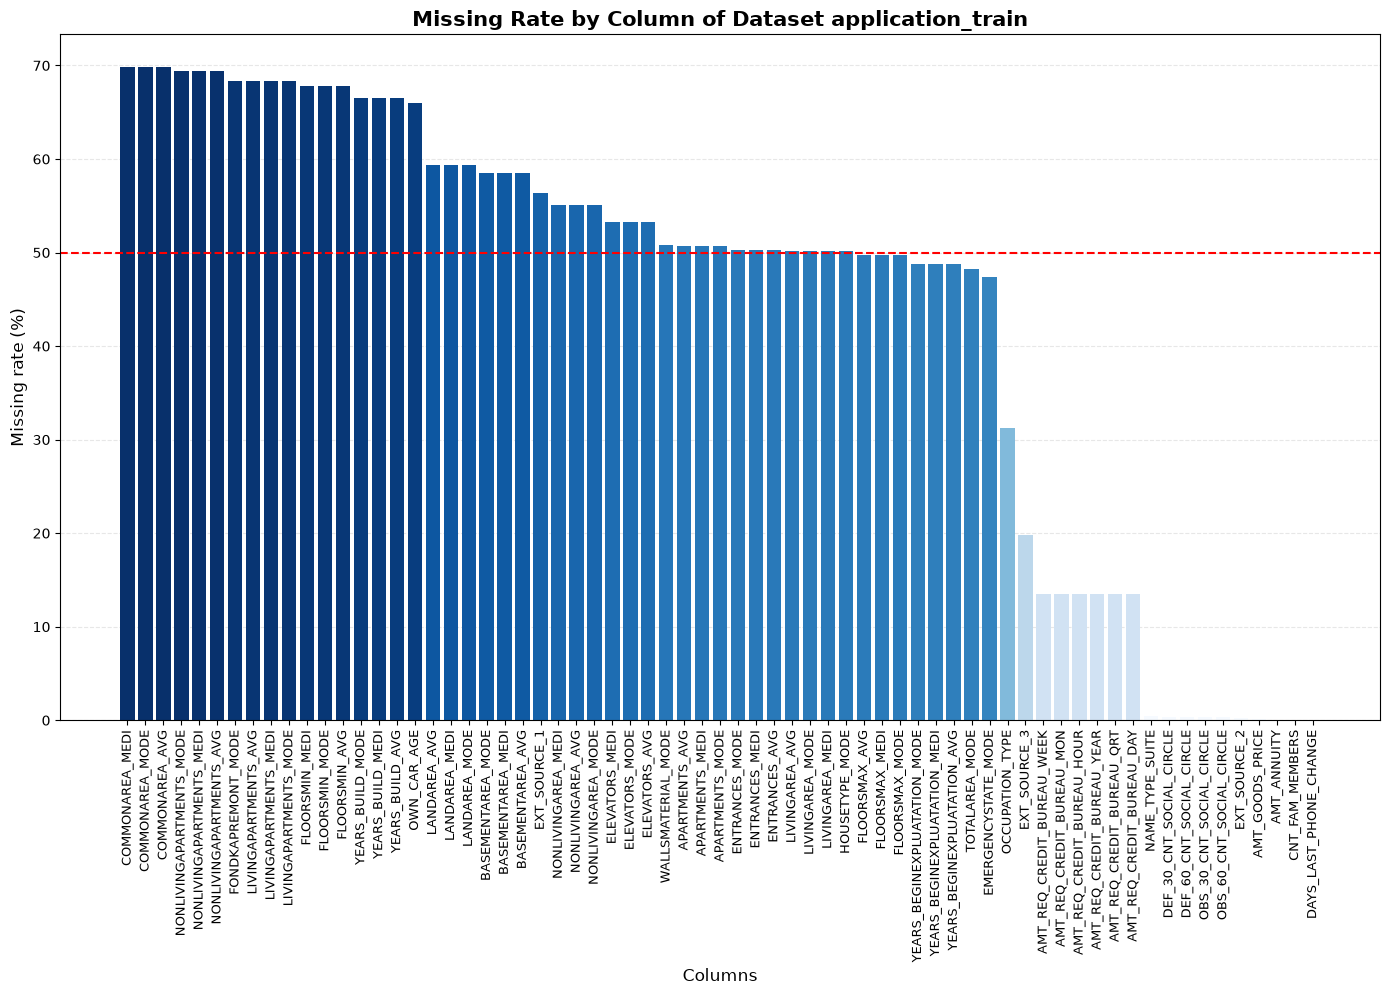

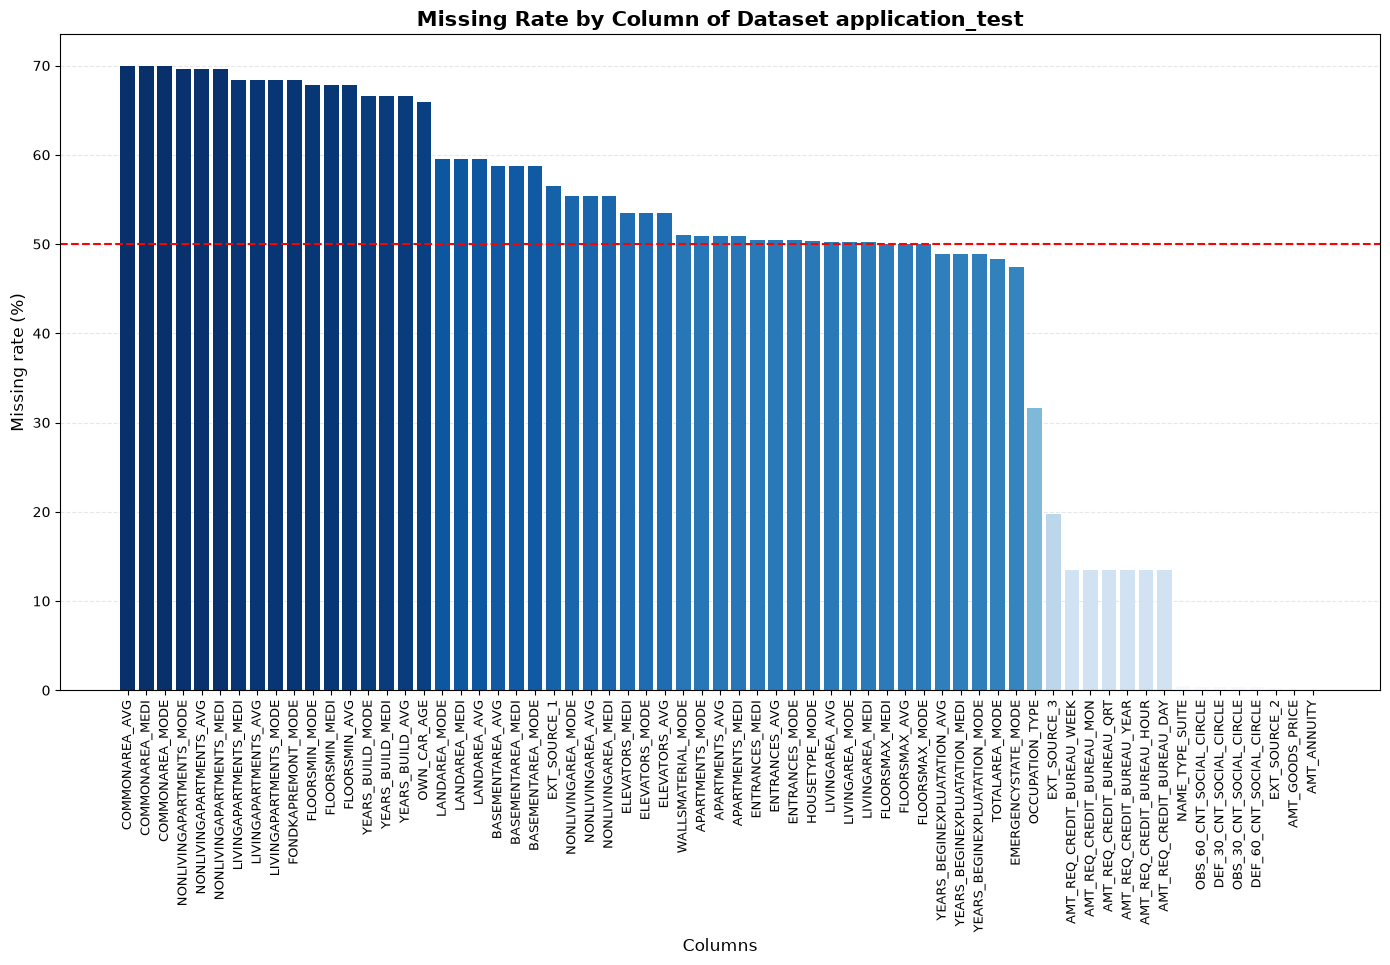

In [4]:
nan_plot_values_count(df=application_train, dataset='application_train')
nan_plot_values_count(df=application_test, dataset='application_test')

- Most NaN values appear in the customer housing features (e.g., COMMONAREA_AVG/MEDI/MODE with over 70%). These fields are often optional in loan application forms and show high inter-correlation. Imputing these missing values may introduce bias, so we can temporarily drop these feature groups in later stages (while keeping them intact during EDA).

- Other non-housing feature groups with missing rates between 10–32% will be analyzed further.

In [5]:
application_train.select_dtypes(include=['str']).columns

Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
       'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE',
       'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE'],
      dtype='str')

#### Correlation

In [6]:
categorical_columns = ['TARGET','FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE',
                    'FLAG_PHONE', 'FLAG_EMAIL','REGION_RATING_CLIENT','REGION_RATING_CLIENT_W_CITY',
                    'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION',
                    'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 
                    'LIVE_CITY_NOT_WORK_CITY'] + ['FLAG_DOCUMENT_' + str(i) for i in range(2,22)] + application_train.dtypes[application_train.dtypes == 'object'].index.tolist()

number_columns = application_train.select_dtypes(include=['number']).columns[~application_train.select_dtypes(include=['number']).columns.isin(categorical_columns)].to_list()
corr_application_train = CorrelationAnalyzer(df=application_train)

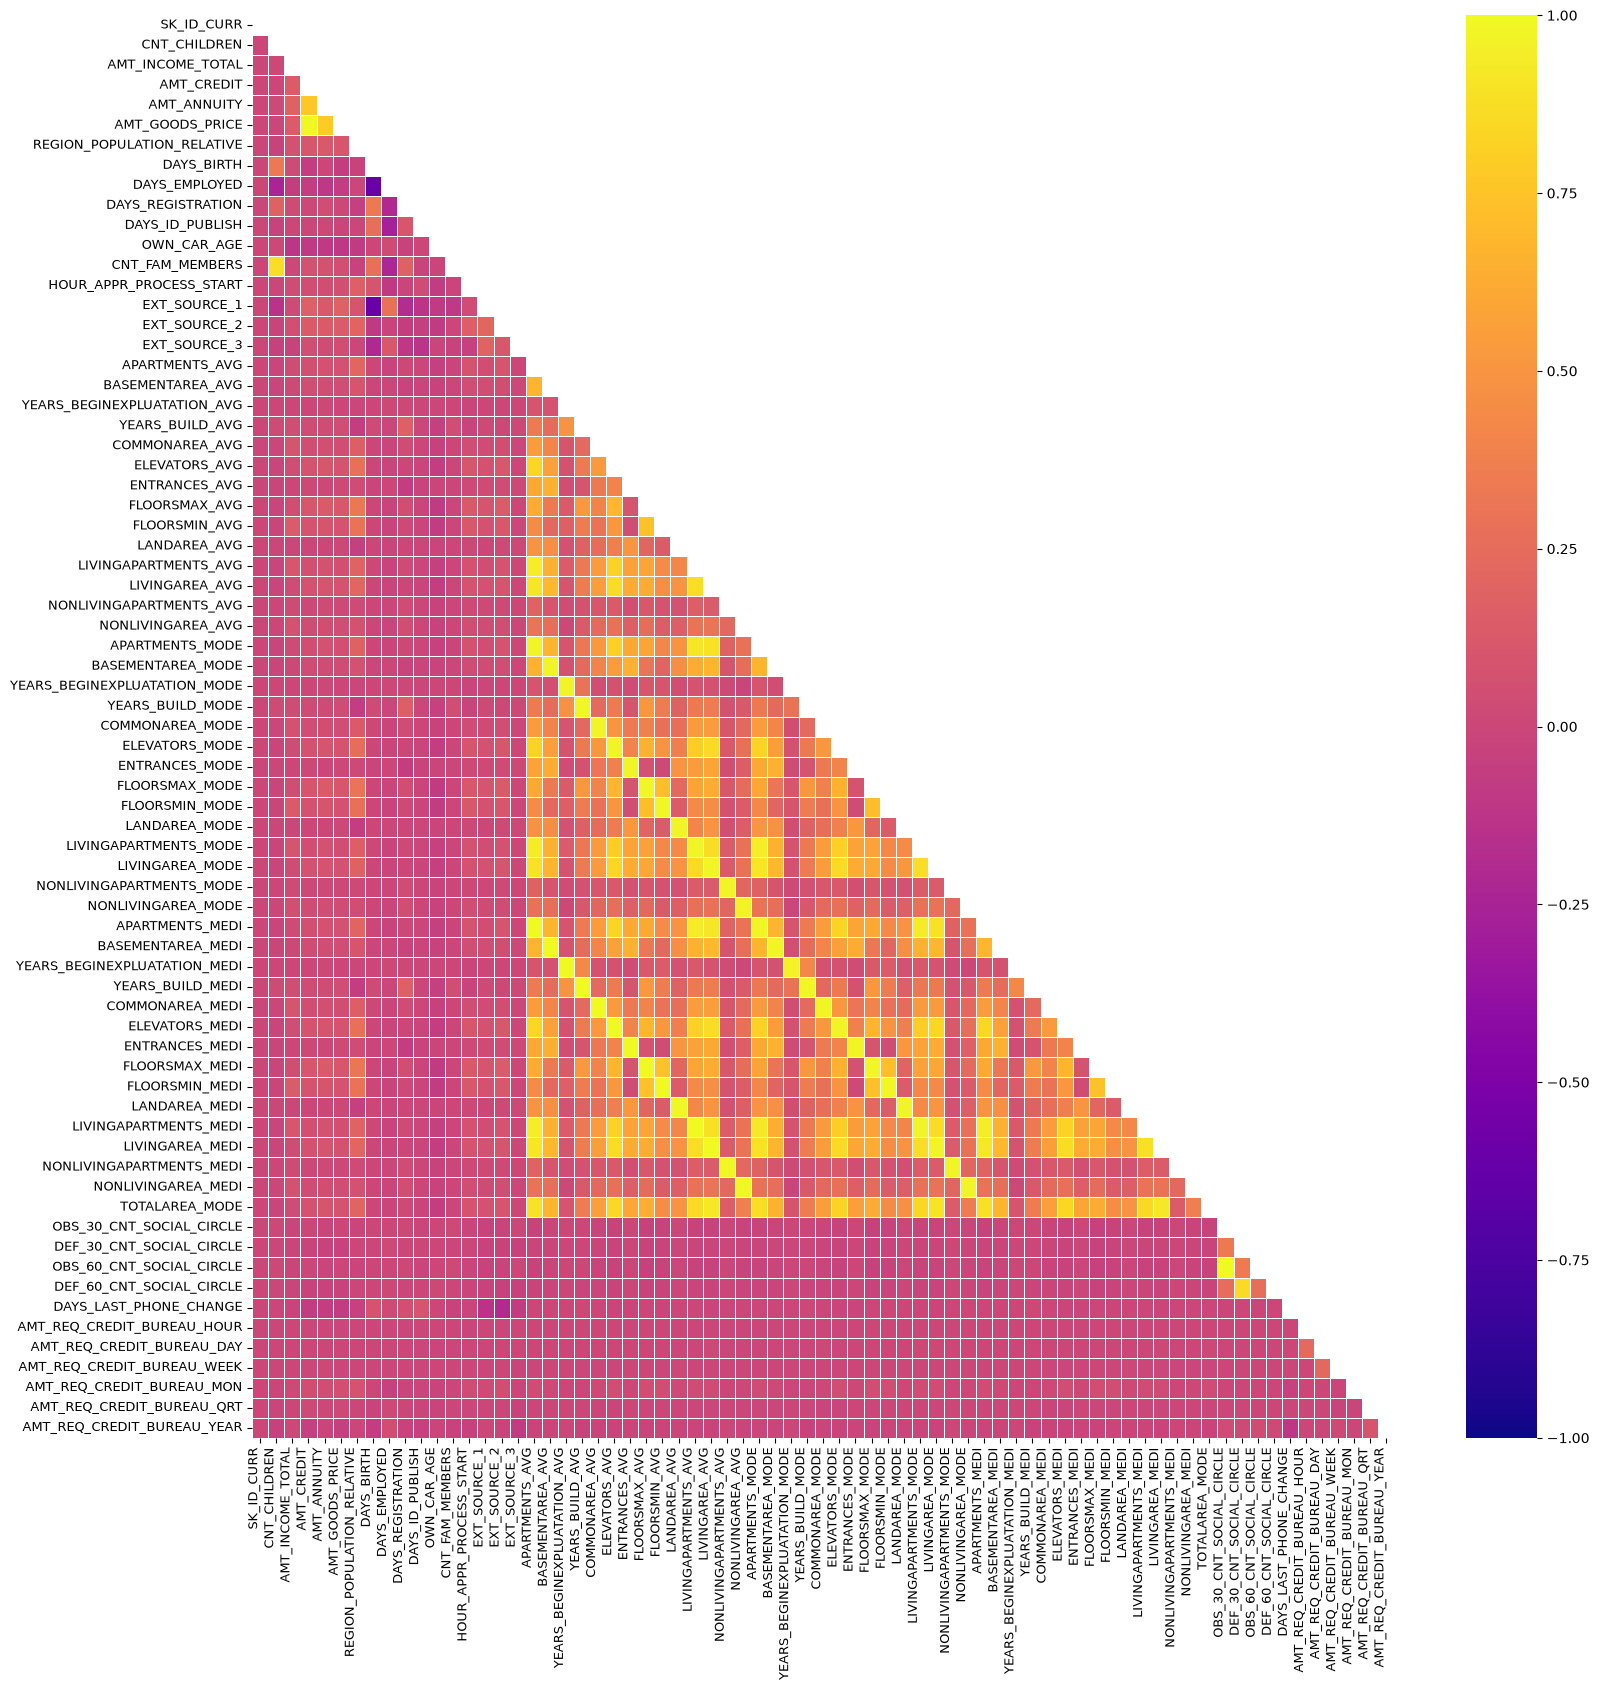

In [7]:
matrix = corr_application_train.pearson_corr(number_columns)
corr_application_train.plot_heatmap(
    corr_matrix=matrix,
    title='',
    figsize=(17,17),
    cmap='plasma'
)

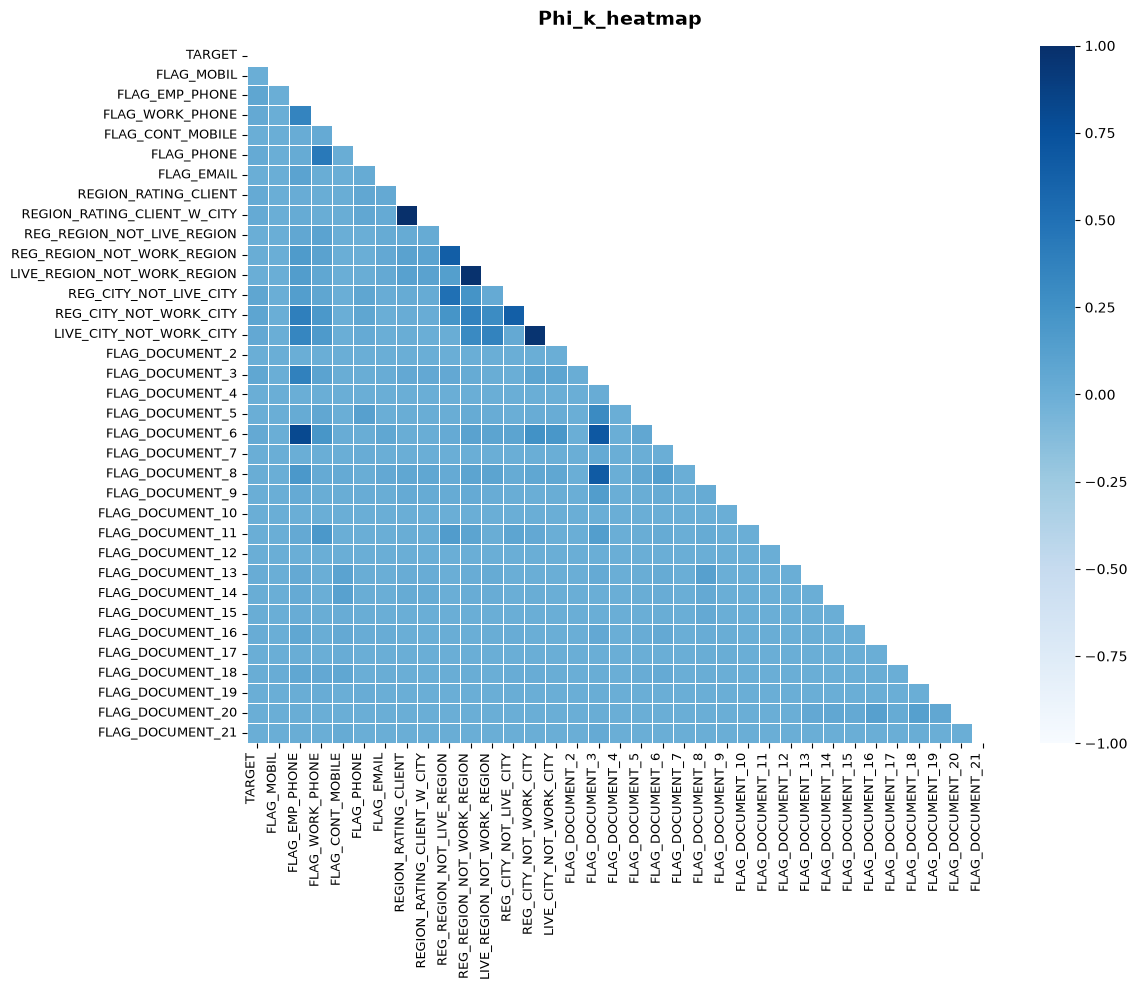

In [8]:
phi_k_matrix = corr_application_train.phi_k_corr(categorical_columns)
corr_application_train.plot_heatmap(
    corr_matrix=phi_k_matrix,
    title='Phi_k_heatmap'
)

In [9]:
corr_application_train.top_target_phi_k(columns=categorical_columns)

REG_CITY_NOT_WORK_CITY         0.080980
FLAG_EMP_PHONE                 0.072733
REG_CITY_NOT_LIVE_CITY         0.071538
FLAG_DOCUMENT_3                0.069431
LIVE_CITY_NOT_WORK_CITY        0.052219
FLAG_WORK_PHONE                0.044307
FLAG_DOCUMENT_6                0.043583
FLAG_PHONE                     0.037248
REGION_RATING_CLIENT_W_CITY    0.036959
REGION_RATING_CLIENT           0.035479
Name: TARGET, dtype: float64

In [10]:
corr_application_train.top_target_phi_k(columns=number_columns)

EXT_SOURCE_3              0.246188
EXT_SOURCE_1              0.217184
EXT_SOURCE_2              0.212872
DAYS_BIRTH                0.103961
DAYS_EMPLOYED             0.072747
DAYS_LAST_PHONE_CHANGE    0.071088
DAYS_ID_PUBLISH           0.065476
AMT_GOODS_PRICE           0.059099
FLOORSMAX_AVG             0.058203
FLOORSMAX_MEDI            0.058141
Name: TARGET, dtype: float64

- It can be observed that most of the heatmap contains a purple-ish color, which indicates a very small value of correlation. This implies that most of the features are indeed not correlated to others.

- We can see contrasting shades at the middle of the heatmap. These shades depict a high value of correlation between the features. These are the features which are related to the stats of the apartments.

- Some high correlation between AMT_GOODS_PRICE and AMT_CREDIT, between DAYS_EMPLOYED and DAYS_BIRTH.

- Among all the features, we see some high correlation for EXT_SOURCE features with respect to Target Variable.

#### Categorical data

##### CODE_GENDER

----------------------------------------------------------------------------------------------------
  CODE_GENDER  Total_count  Default_count   Rate
0           F       161887          11334   7.00
1           M        84119           8526  10.14
2         XNA            2              0   0.00
----------------------------------------------------------------------------------------------------


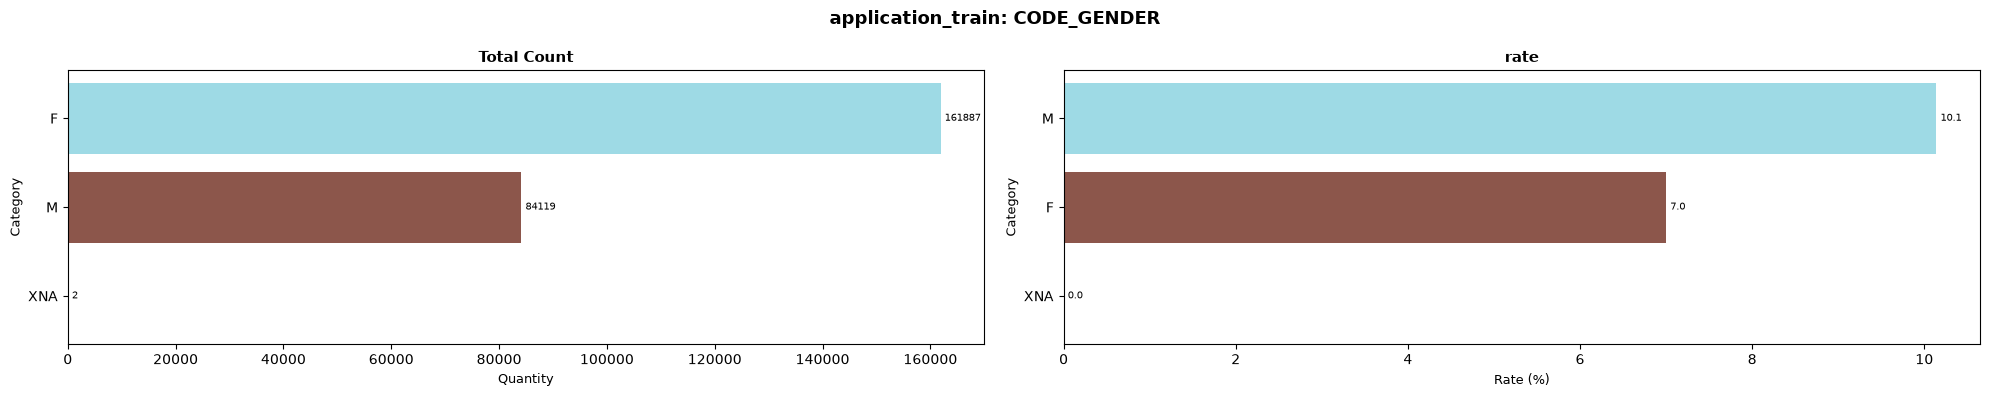

In [11]:
categorical_data_analyzer(df=application_train, dataset='application_train', column='CODE_GENDER')

- Only 2 records in dataset have 'XNA' gender which belong to Non-Default Category. We can eliminate those rows.

- Female applicants / Male applicants: 65.8% / 34.2%, but Male applicants tend to default more (10.14%) as compared to Female applicants (7.1%). So the given dataset show that Male have more tendency to default than Female

##### REGION_RATING_CLIENT_W_CITY 

----------------------------------------------------------------------------------------------------
   REGION_RATING_CLIENT_W_CITY  Total_count  Default_count   Rate
0                            1        27323           1330   4.87
1                            2       183622          14511   7.90
2                            3        35063           4019  11.46
----------------------------------------------------------------------------------------------------


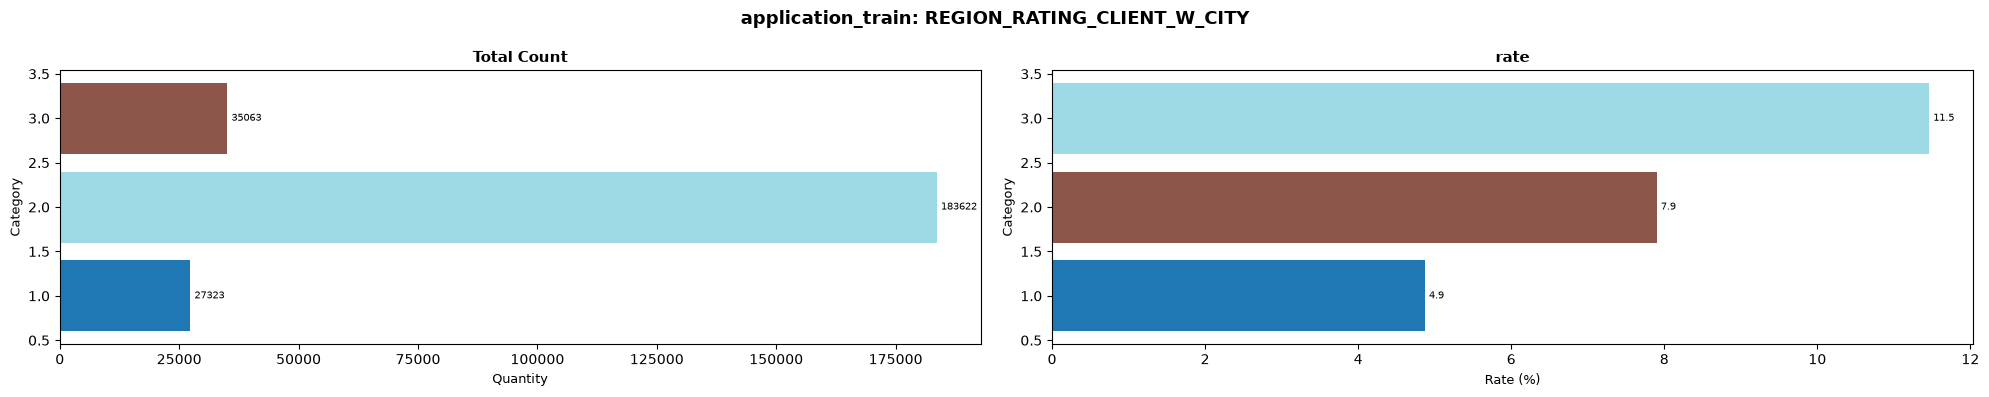

In [12]:
categorical_data_analyzer(df=application_train, dataset='application_train', column='REGION_RATING_CLIENT_W_CITY')

- Most of the clients (> 74%) have a region rating of 2. In another hand, only 11.1% of the clients have a region rating of 1 and 14.3% of the rest have a 0 rating region.

- Among the Defaulter, most of the defaulters have a region rating of 3 which is comparably higher to the other ratings (11.46% for region rating of 3, 7.9% for 2 and 4.87% for 0).

- The rating 3 could be an imporatant attribute for Default decision making.

##### NAME_EDUCATION_TYPE

----------------------------------------------------------------------------------------------------
             NAME_EDUCATION_TYPE  Total_count  Default_count   Rate
0                Academic degree          124              2   1.61
1               Higher education        59802           3226   5.39
2              Incomplete higher         8289            715   8.63
3                Lower secondary         3025            335  11.07
4  Secondary / secondary special       174768          15582   8.92
----------------------------------------------------------------------------------------------------


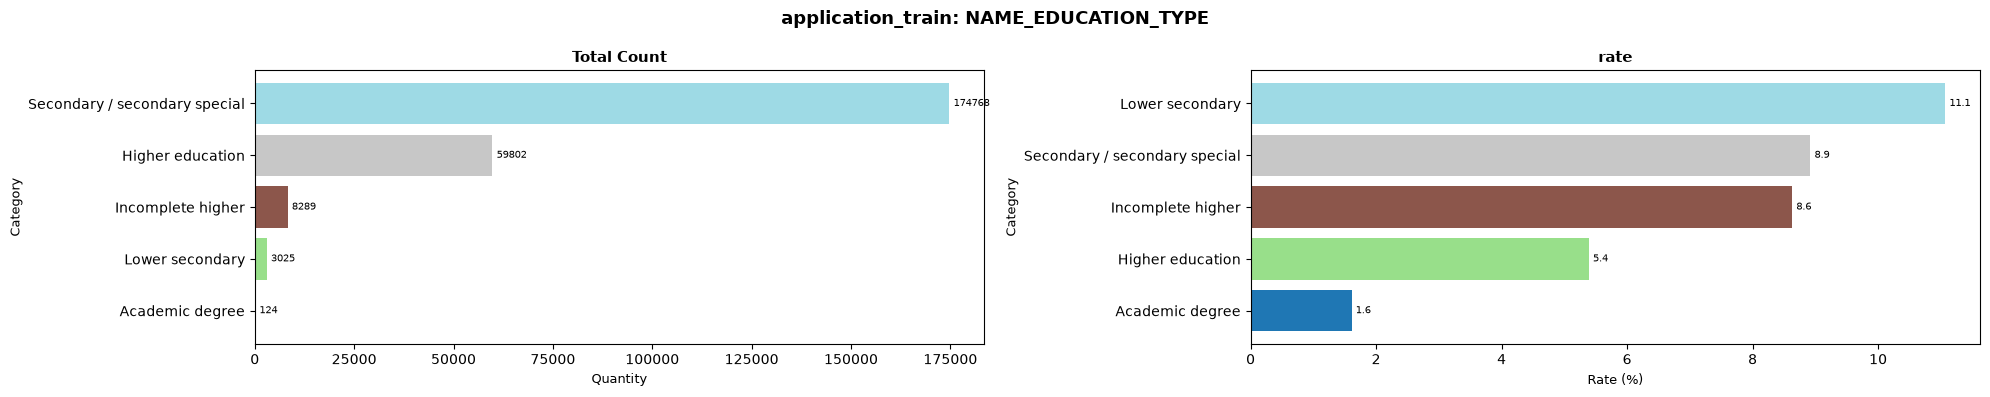

In [13]:
categorical_data_analyzer(df=application_train, dataset='application_train', column='NAME_EDUCATION_TYPE')

- Most of the clients have had their education only till Secondary/Secondary Special.

- The group of peole with Lower secondary, Incomplete higher and Seconary/Secondary Special have the highest Default rate (11.07% for lower secondary, approximate 8.7% for incomplete higher and s/ss). Higher education people have comparably lower defaulting tendency (logical).

- Academic Degree group has very few sample so we can't evaluate correctly

##### OCCUPATION_TYPE

----------------------------------------------------------------------------------------------------
          OCCUPATION_TYPE  Total_count  Default_count   Rate
0             Accountants         7882            365   4.63
1          Cleaning staff         3741            357   9.54
2           Cooking staff         4767            501  10.51
3              Core staff        22093           1410   6.38
4                 Drivers        14944           1683  11.26
5                HR staff          443             31   7.00
6   High skill tech staff         9093            571   6.28
7                IT staff          424             26   6.13
8                Laborers        44259           4657  10.52
9      Low-skill Laborers         1696            307  18.10
10               Managers        17096           1064   6.22
11         Medicine staff         6871            480   6.99
12                     NA        76940           4995   6.49
13  Private service staff         2094       

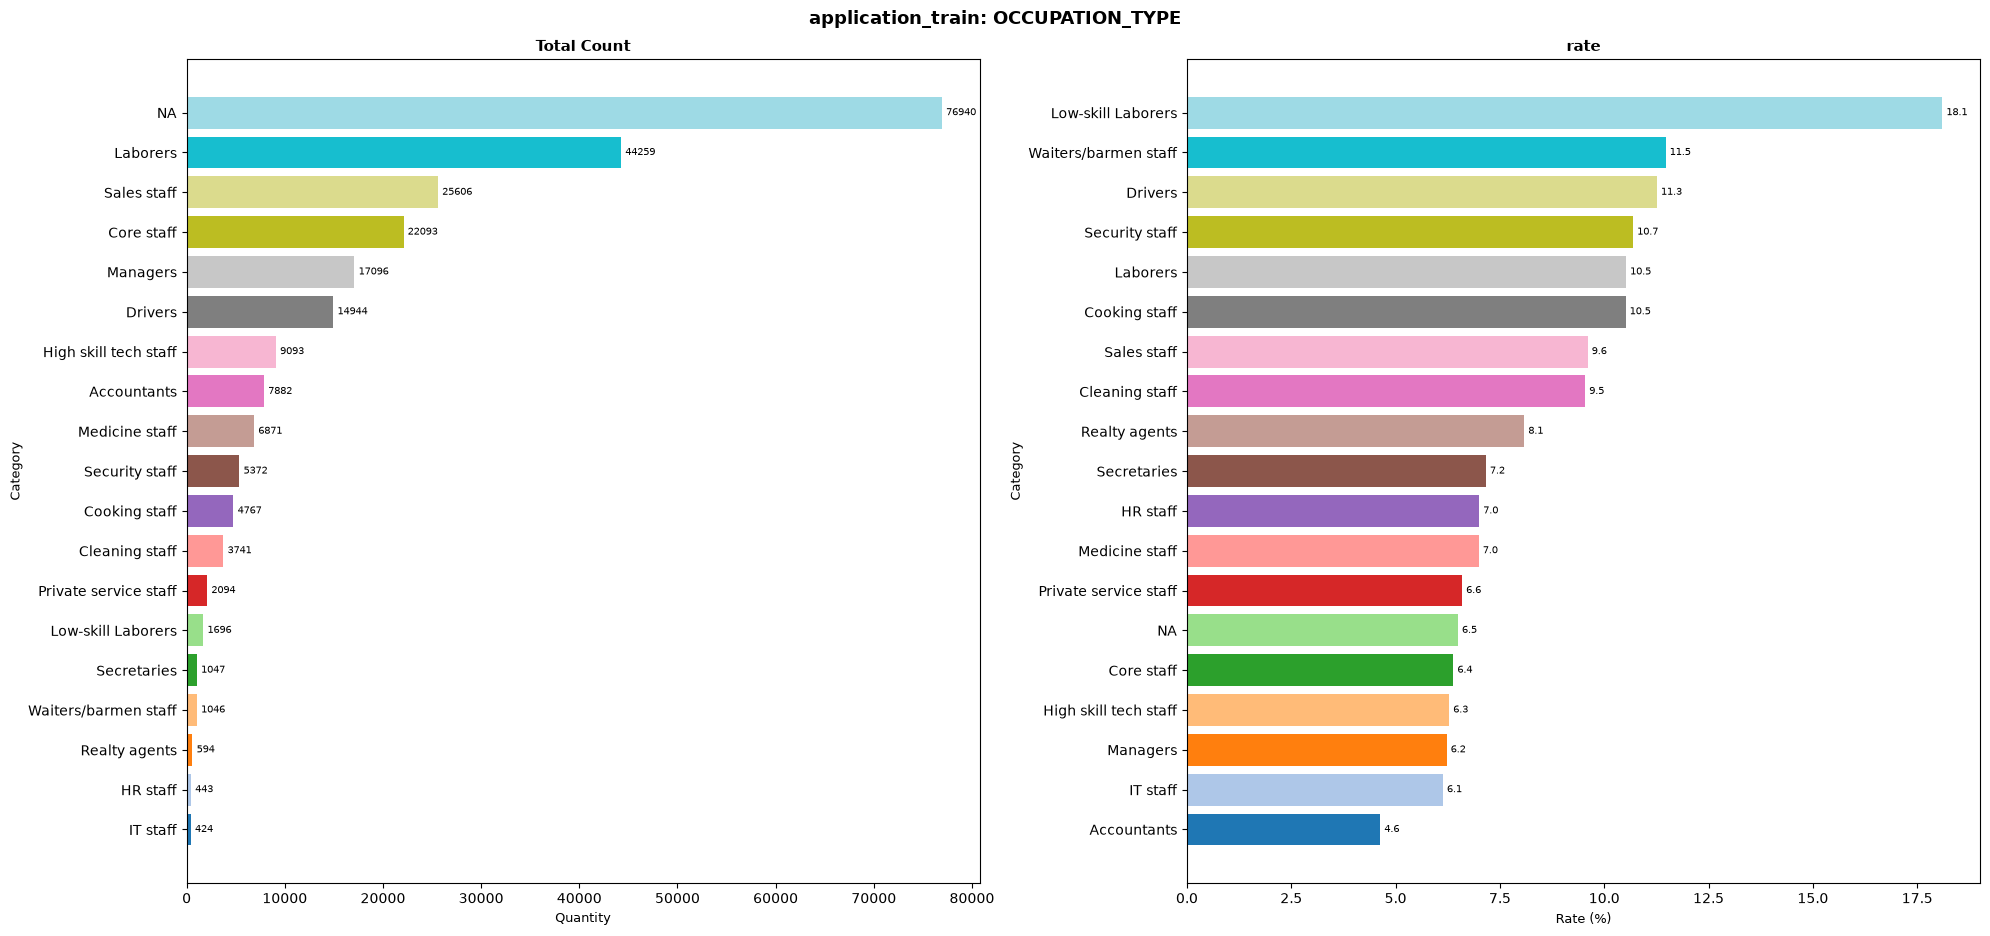

In [14]:
categorical_data_analyzer(df=application_train, dataset='application_train', column='OCCUPATION_TYPE')

- 2 most common types of occupation are Laborders contributing to close to 26% applications and a special category - NA with > 30% contribution. The next most frequent occupation is Sales Staff, Core Staff and Managers.

- The Default Rate for Low-Skill Laborders is the highest among all the occupation types. This is followed by Drivers, Waiters, Security Staff, Laboders, Cooking Staff,... The similar of those occupation that they both represent low-level skill jobs.

- The lowest defaulting rate are most from med to high level jobs.

- The NA contributes lots of applicants, and its default rate have the clearly pattern, so we can compute the NaN value in `OCCUPATION_TYPE` with XNA that defines a new category.

##### ORGANIZATION_TYPE

----------------------------------------------------------------------------------------------------
         ORGANIZATION_TYPE  Total_count  Default_count   Rate
0              Advertising          331             29   8.76
1              Agriculture         1975            213  10.78
2                     Bank         2000            110   5.50
3   Business Entity Type 1         4820            388   8.05
4   Business Entity Type 2         8431            728   8.63
5   Business Entity Type 3        54436           5048   9.27
6                 Cleaning          212             24  11.32
7             Construction         5399            645  11.95
8                  Culture          296             18   6.08
9              Electricity          757             56   7.40
10               Emergency          458             32   6.99
11              Government         8341            573   6.87
12                   Hotel          783             50   6.39
13                 Housing     

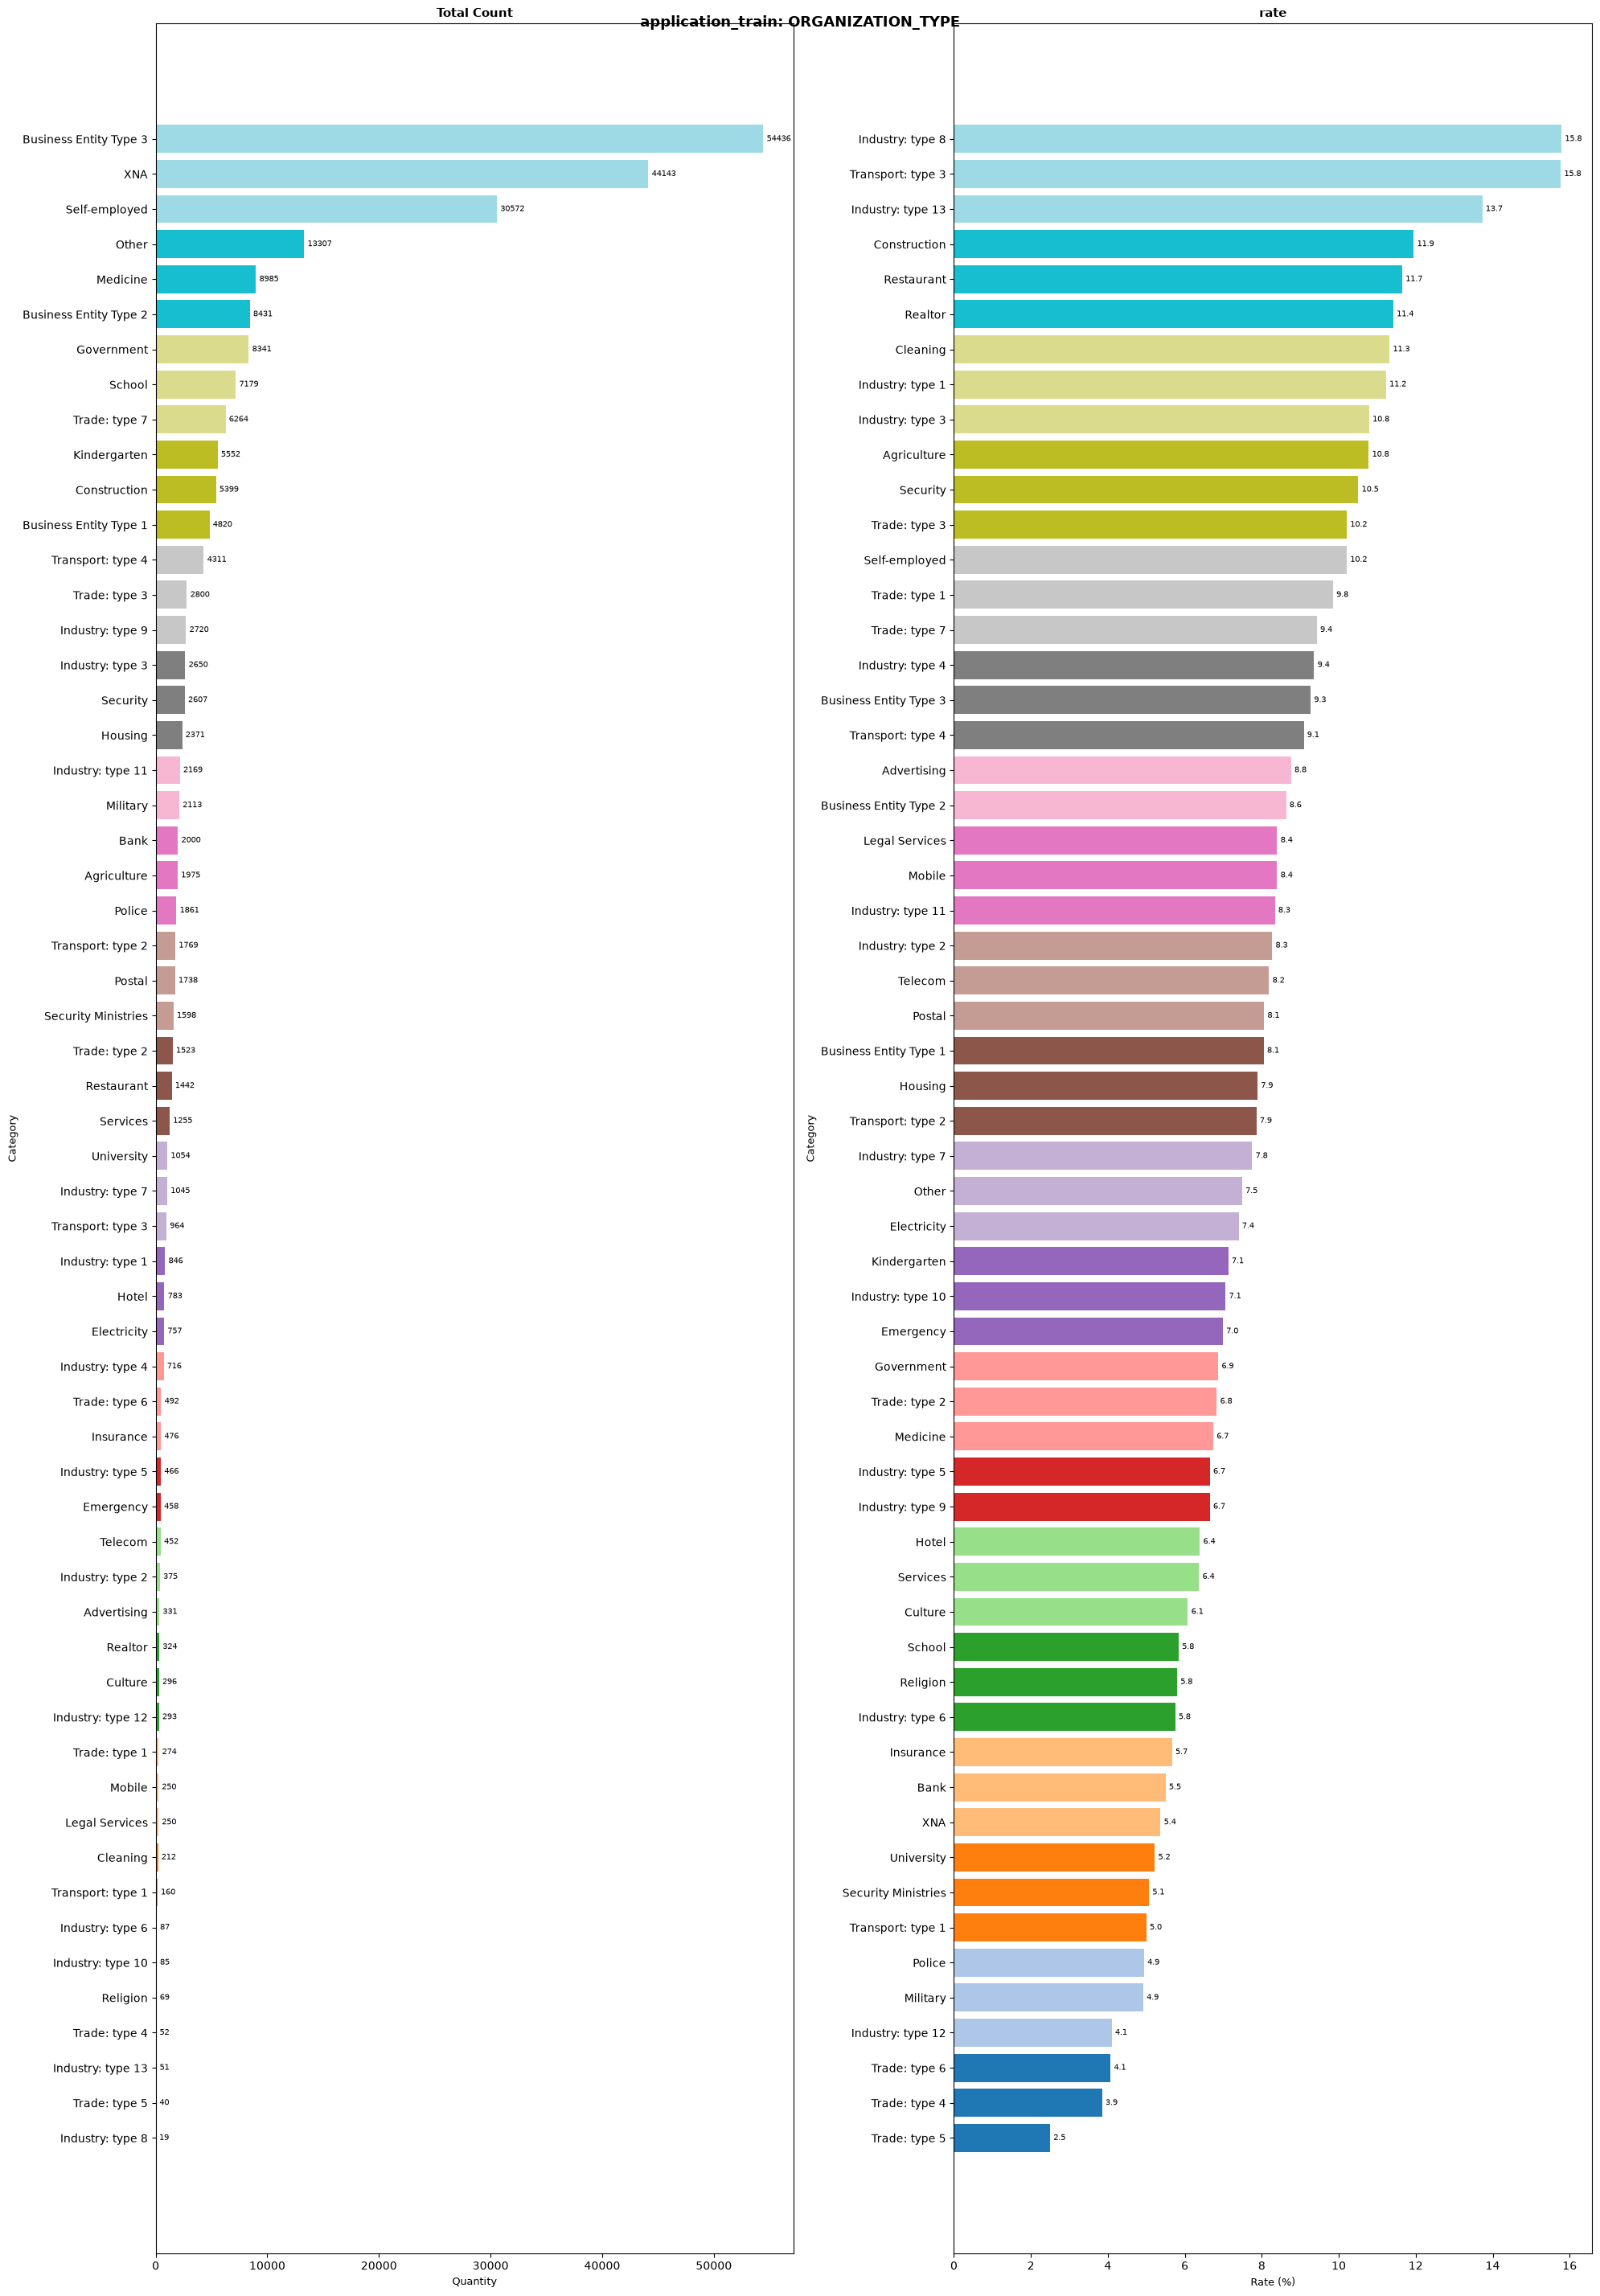

In [15]:
categorical_data_analyzer(df=application_train, dataset='application_train', column='ORGANIZATION_TYPE')

These type numbers also would say something more about the Organization, however, we don't have any information related to that, so we will stick with the naming provided to us only.

##### REG_CITY_NOT_LIVE_CITY, REG_CITY_NOT_WORK_CITY, LIVE_CITY_NOT_WORK_CITY

In [16]:
cate = ['REG_CITY_NOT_LIVE_CITY','REG_CITY_NOT_WORK_CITY','LIVE_CITY_NOT_WORK_CITY']
df = application_train.copy()
df[cate] = df[cate].astype('str')

----------------------------------------------------------------------------------------------------
  REG_CITY_NOT_LIVE_CITY  Total_count  Default_count   Rate
0                      0       226845          17493   7.71
1                      1        19163           2367  12.35
----------------------------------------------------------------------------------------------------


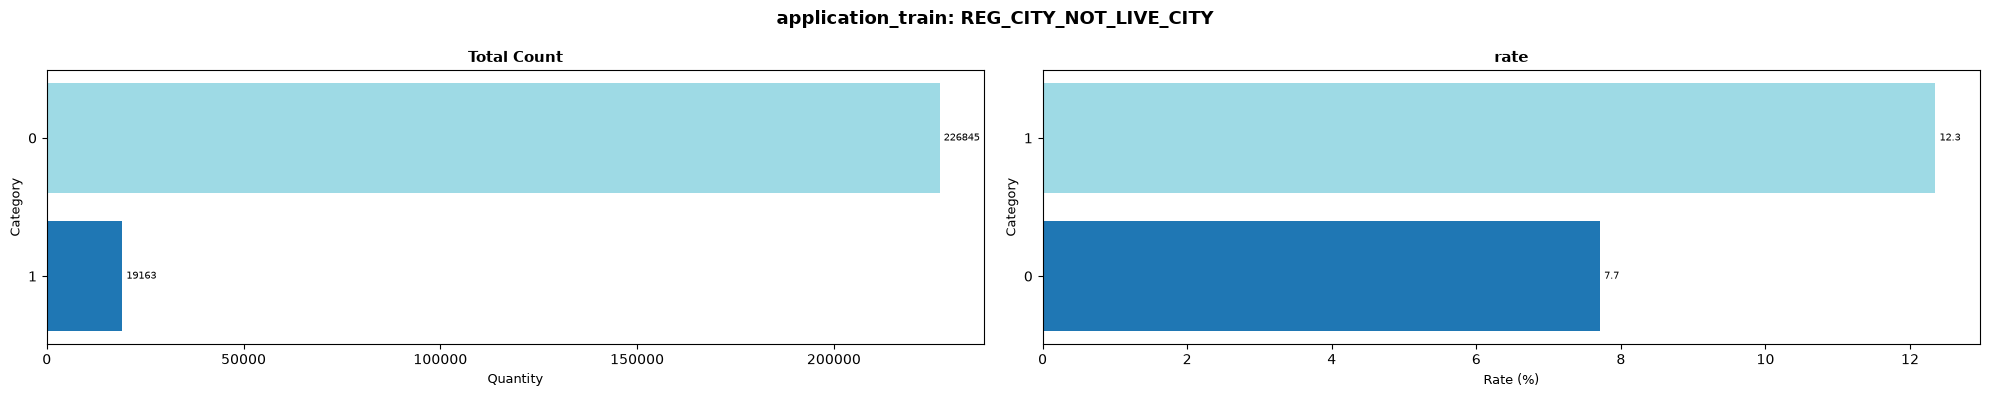

----------------------------------------------------------------------------------------------------
  REG_CITY_NOT_WORK_CITY  Total_count  Default_count   Rate
0                      0       189169          13812   7.30
1                      1        56839           6048  10.64
----------------------------------------------------------------------------------------------------


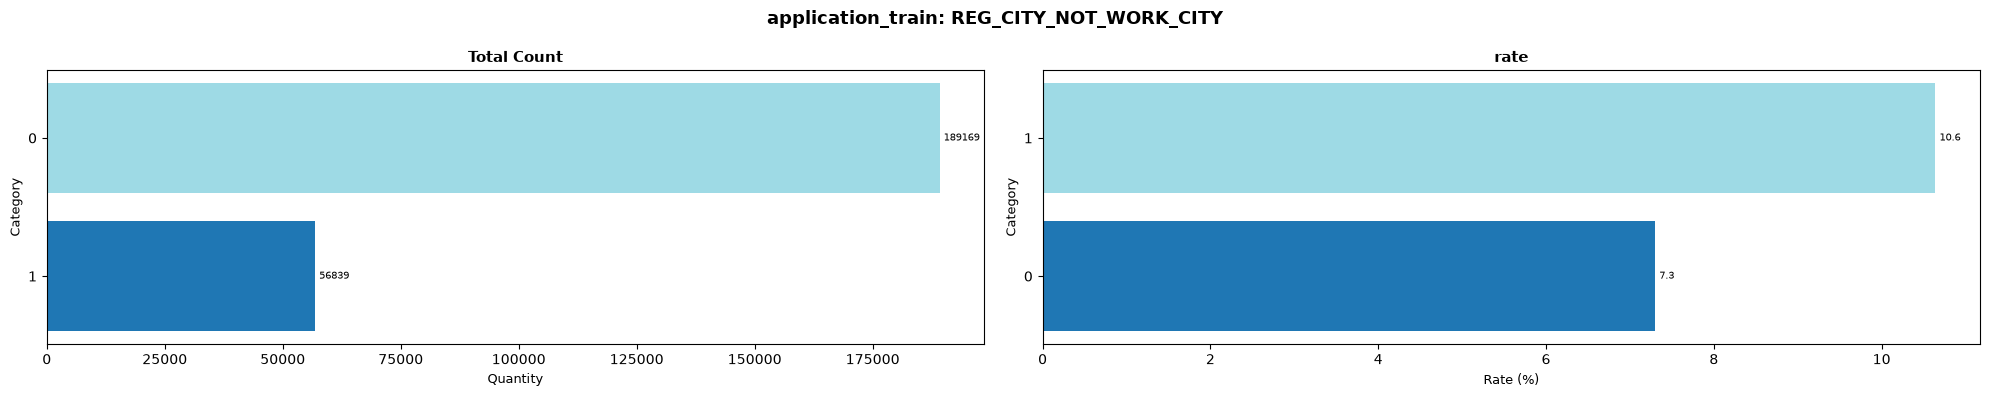

----------------------------------------------------------------------------------------------------
  LIVE_CITY_NOT_WORK_CITY  Total_count  Default_count   Rate
0                       0       201638          15419   7.65
1                       1        44370           4441  10.01
----------------------------------------------------------------------------------------------------


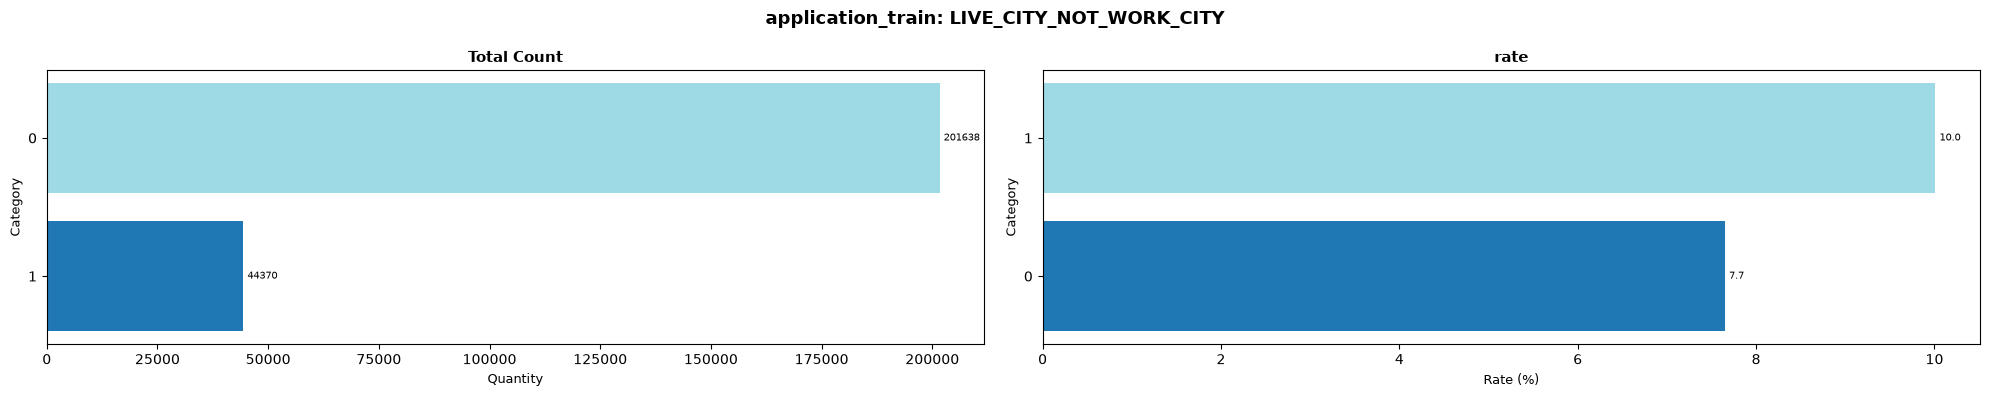

In [17]:
for col in cate:
    categorical_data_analyzer(df=df, dataset='application_train', column=col)

- Only 7.52% people who have different permanent address from their contect address at region level.

- There are 23% people that have different permanent address from their work address at region level.

- 17.96% of people have different address from their address at city level.

- Focus on the defaulting rate, there is maximum defaulting tendecy of those people who have their permanent and contact addresses different at region level, which is followed by different permanent and work addres and different permanent and contact address at city level.

- It is seen that the Defaulting tendecy of this difference in address may suggest Defaulting Risk

In [18]:
FLAG_cols = ['FLAG_DOCUMENT_' + str(i) for i in range(2,22)]
df[FLAG_cols] = df[FLAG_cols].astype('str')

----------------------------------------------------------------------------------------------------
  FLAG_DOCUMENT_3  Total_count  Default_count  Rate
0               0        71232           4404  6.18
1               1       174776          15456  8.84
----------------------------------------------------------------------------------------------------


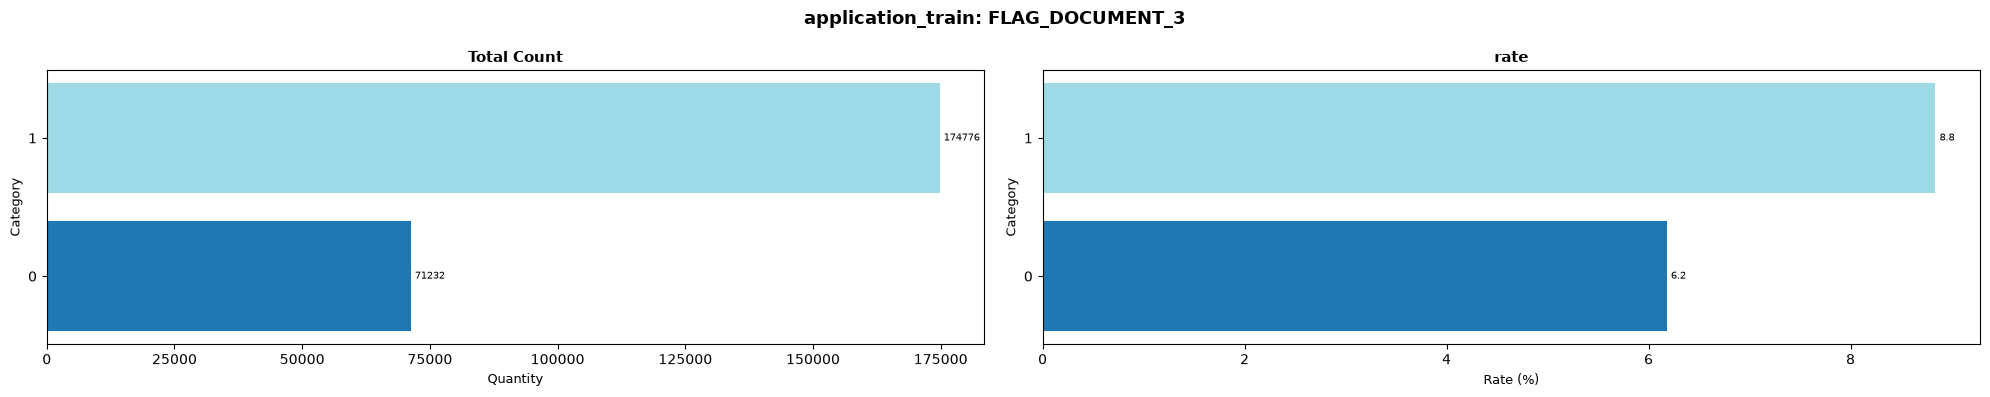

----------------------------------------------------------------------------------------------------
  FLAG_DOCUMENT_6  Total_count  Default_count  Rate
0               0       224429          18646  8.31
1               1        21579           1214  5.63
----------------------------------------------------------------------------------------------------


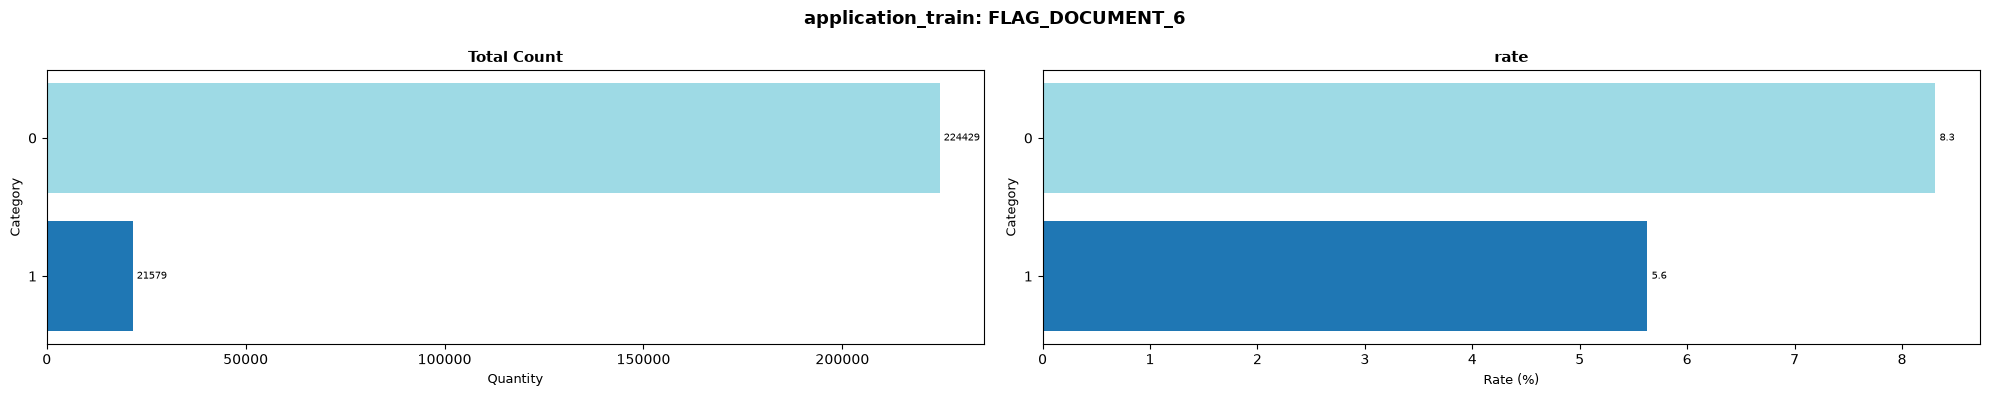

----------------------------------------------------------------------------------------------------
  FLAG_DOCUMENT_8  Total_count  Default_count  Rate
0               0       225985          18401  8.14
1               1        20023           1459  7.29
----------------------------------------------------------------------------------------------------


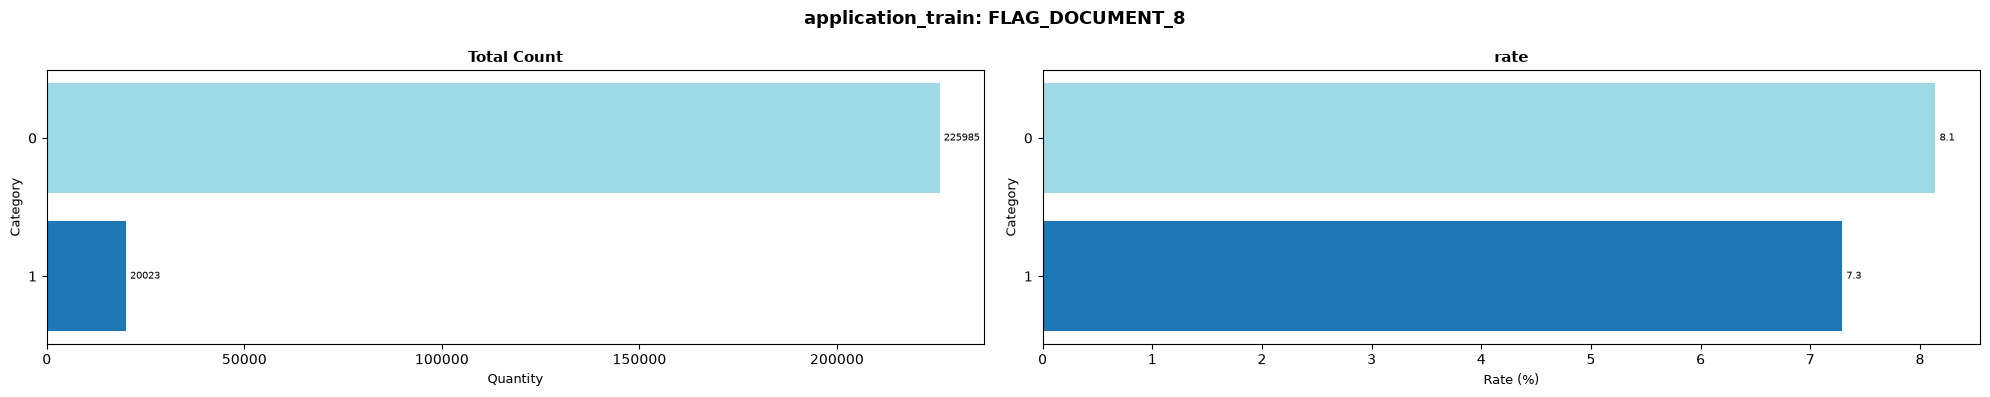

In [19]:
for col in ['FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_8']:
    categorical_data_analyzer(df=df, dataset='application_train', column=col)

- `FLAG_DOCUMENT_3`: Applicants who provided Document 3 make up the majority of the dataset (174,776 applications). They show a noticeably higher default rate of 8.84% compared to 6.18% for those who did not provide it. This suggests that providing Document 3 correlates with a higher risk profile.

- `FLAG_DOCUMENT_6`: Only a small minority of applicants provided Document 6 (21,579 vs. 224,429). The default rate is lower among applicants who submitted this document (5.63%) compared to those who did not (8.31%).

- `FLAG_DOCUMENT_8`: Similar to Document 6, submission is relatively rare (20,023 applications). Applicants submitting Document 8 exhibit a lower default rate (7.29%) than those who omitted it (8.14%).

- While FLAG_DOCUMENT_6 and FLAG_DOCUMENT_8 act as mild indicators of lower risk (lower default rates when provided), FLAG_DOCUMENT_3 serves as a strong positive indicator of default risk, combined with a significantly larger volume of records.

##### NAME_FAMILY_STATUS

----------------------------------------------------------------------------------------------------
     NAME_FAMILY_STATUS  Total_count  Default_count   Rate
0        Civil marriage        23812           2385  10.02
1               Married       157153          11840   7.53
2             Separated        15840           1265   7.99
3  Single / not married        36359           3616   9.95
4               Unknown            2              0   0.00
5                 Widow        12842            754   5.87
----------------------------------------------------------------------------------------------------


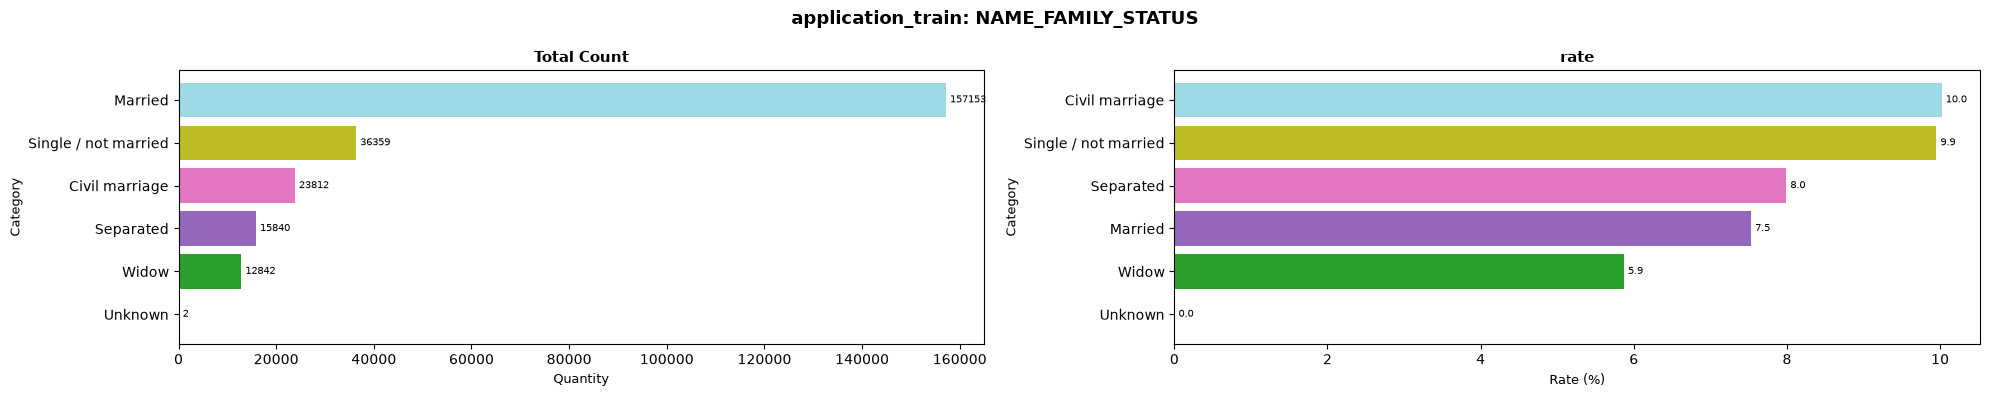

In [20]:
categorical_data_analyzer(df=application_train, dataset='application_train', column='NAME_FAMILY_STATUS')

- Highest Default Risk: Applicants with Civil marriage (10.02%) and Single / not married (9.95%) status display the highest default rates, significantly exceeding the dataset average.

- Moderate Risk: Separated (7.99%) and Married (7.53%) applicants show moderate risk profiles. Married applicants represent the vast majority of the dataset (157,153 applications).

- Lowest Risk: Widow status corresponds to the lowest default rate (5.87%) among categories with significant sample sizes (12,842 applications).

- Negligible Data: The Unknown category contains only 2 instances with 0 defaults (0.00%), making it statistically insignificant.

- Single applicants and those in civil marriages present a distinctly higher credit risk than married or widowed individuals. This variable serves as a strong candidate feature for predicting loan default propensity.

##### NAME_CONTRACT_TYPE

----------------------------------------------------------------------------------------------------
  NAME_CONTRACT_TYPE  Total_count  Default_count  Rate
0         Cash loans       222560          18572  8.34
1    Revolving loans        23448           1288  5.49
----------------------------------------------------------------------------------------------------


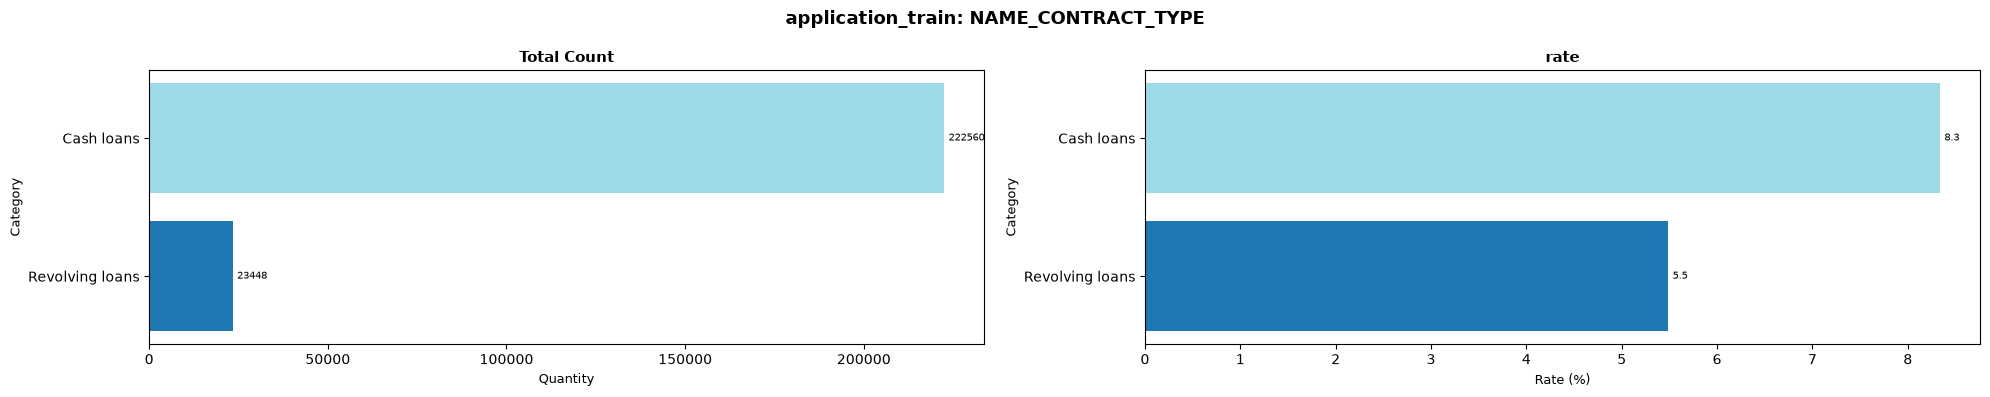

In [21]:
categorical_data_analyzer(df=application_train, dataset='application_train', column='NAME_CONTRACT_TYPE')

Borrowers seeking lump-sum cash loans present a substantially higher credit risk than those applying for flexible revolving lines of credit.

#### Numerical data

##### Distribution of Continuous Age of Applicant

C:\Users\Hi Windows 11 Home\AppData\Local\Temp\ipykernel_10948\3854426319.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  application_train['AGE'] = application_train['DAYS_BIRTH'] * -1 / 365.25


----------------------------------------------------------------------------------------------------
count    246008.000000
mean         43.886423
std          11.944884
min          20.503765
1%           22.614648
5%           25.738535
10%          28.136893
20%          31.991786
30%          35.961670
40%          39.452430
50%          43.104723
60%          47.132101
70%          51.682409
80%          56.020808
90%          60.709103
95%          63.507187
99%          66.836413
max          69.073238
Name: AGE, dtype: float64
----------------------------------------------------------------------------------------------------


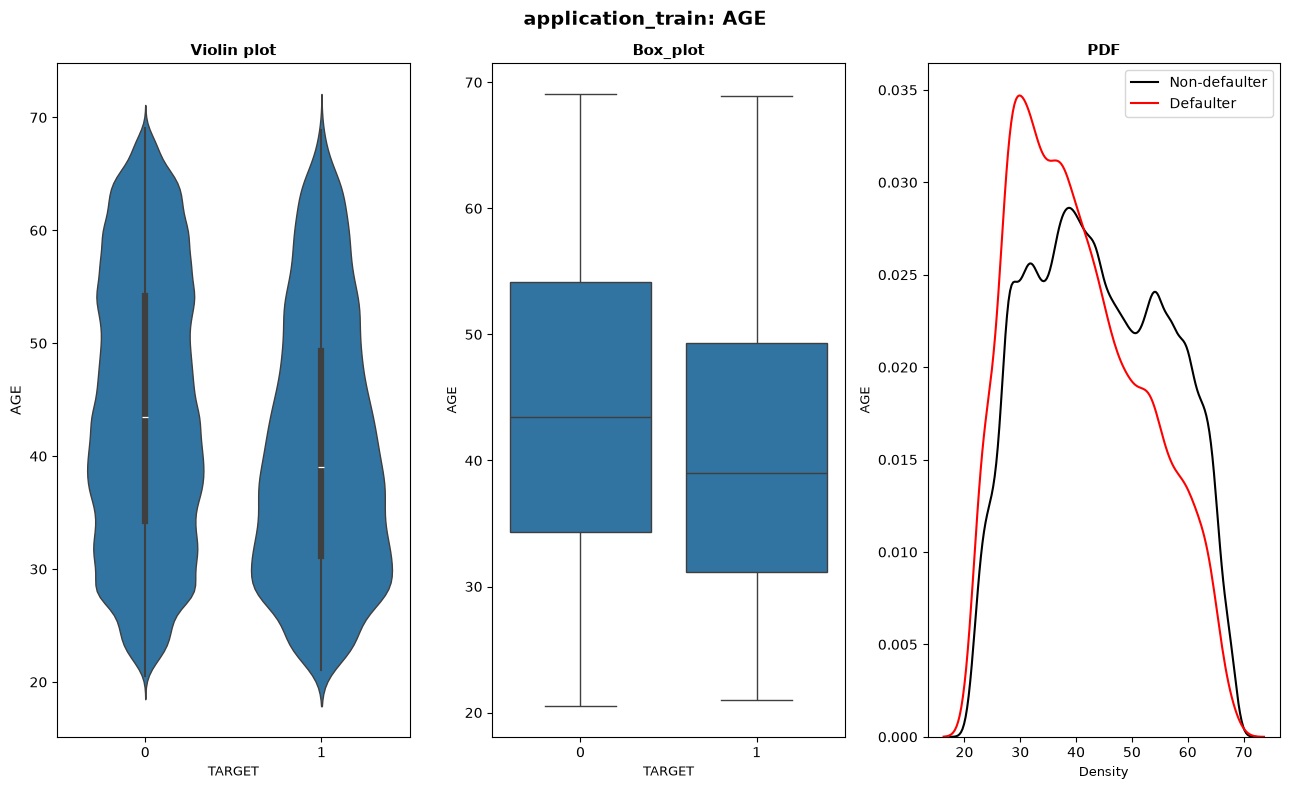

In [22]:
application_train['AGE'] = application_train['DAYS_BIRTH'] * -1 / 365.25
numerical_data_analyzer(application_train, 'application_train', 'AGE')

- We can observe the peak of Age of Defaulter to be close to 30 years. The Non-Defaulter have a quite smaller PDF, the PDF of age of Defaulter starts  a bit left from the Non-Defaulters, and also is a bit throughout the range.

- The boxplot show that all quantiles of ages of Defaulter is lesser than Non-defaulter.

- These observations imply that the Defaulter are usually younger than Non-Defaulter.

#### Distribution with DAYS features

##### DAYS_EMPLOYED

C:\Users\Hi Windows 11 Home\AppData\Local\Temp\ipykernel_10948\2568635271.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  application_train['YEARS_EMPLOYED'] = application_train['DAYS_EMPLOYED'] * -1 / 365.25


----------------------------------------------------------------------------------------------------
count    246008.000000
mean      63581.163637
std      141081.696923
min      -17912.000000
1%       -10899.860000
5%        -6751.650000
10%       -4895.000000
20%       -3232.600000
30%       -2365.000000
40%       -1696.000000
50%       -1215.000000
60%        -822.000000
70%        -459.000000
80%        -147.000000
90%      365243.000000
95%      365243.000000
99%      365243.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64
----------------------------------------------------------------------------------------------------


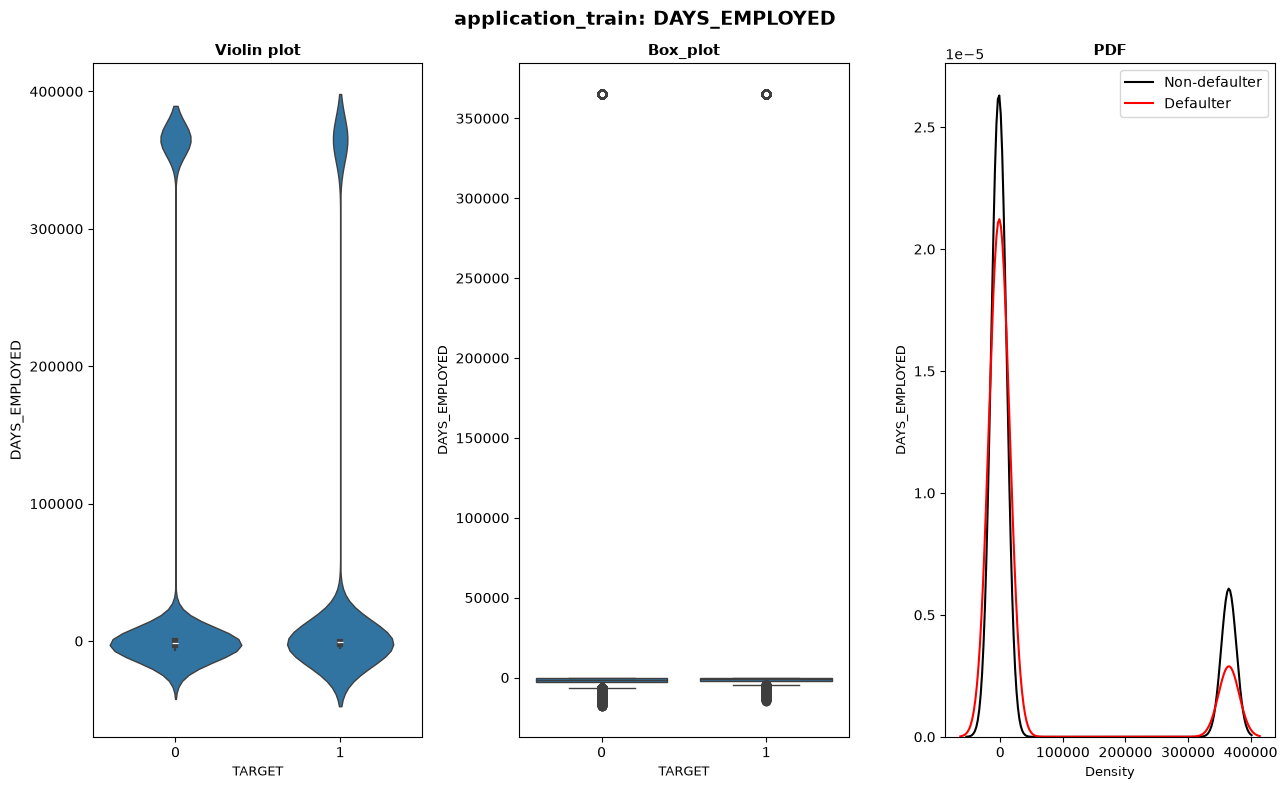

In [23]:
application_train['YEARS_EMPLOYED'] = application_train['DAYS_EMPLOYED'] * -1 / 365.25
numerical_data_analyzer(df=application_train, dataset='application_train', column='DAYS_EMPLOYED')

----------------------------------------------------------------------------------------------------
count    201865.000000
mean          6.529758
std           6.405822
min           0.000000
1%            0.303901
5%            0.563997
10%           0.911704
20%           1.686516
30%           2.513347
40%           3.419576
50%           4.511978
60%           5.911020
70%           7.644079
80%          10.067077
90%          14.617385
95%          19.975359
99%          31.044490
max          49.040383
Name: YEARS_EMPLOYED, dtype: float64
----------------------------------------------------------------------------------------------------


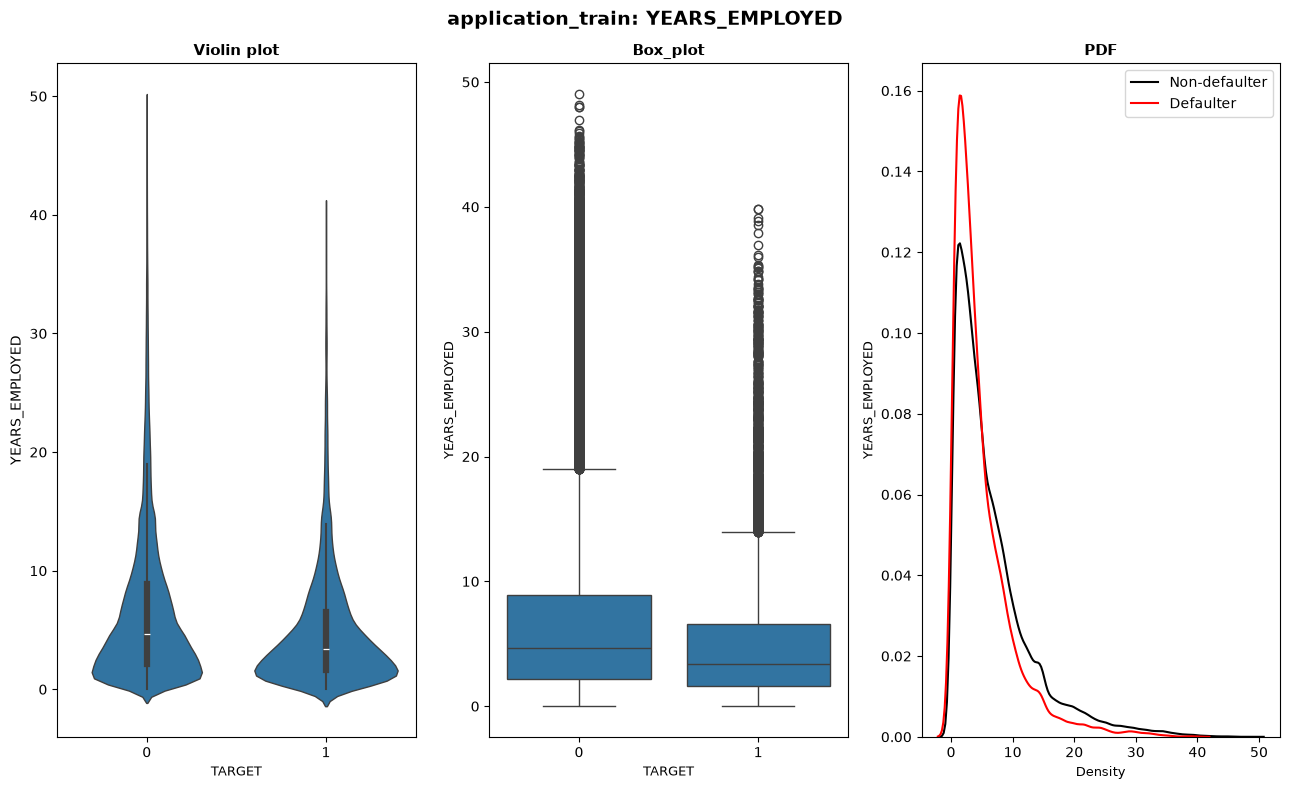

In [24]:
numerical_data_analyzer(df=application_train[application_train['DAYS_EMPLOYED'] != 365243], dataset='application_train', column='YEARS_EMPLOYED')

- `DAYS_EMPLOYED` column contains some erroneous datapoints with values 365243.

- All the 25th, 50th and 75th quantile for Defaulter are lesser than those of Non-Defaulter

##### DAYS_ID_PUBLISH

----------------------------------------------------------------------------------------------------
count    246008.000000
mean      -2994.150438
std        1508.274570
min       -7197.000000
1%        -5447.000000
5%        -4942.000000
10%       -4722.000000
20%       -4429.000000
30%       -4171.000000
40%       -3878.000000
50%       -3255.000000
60%       -2655.000000
70%       -2044.000000
80%       -1380.000000
90%        -732.000000
95%        -376.000000
99%         -62.000000
max           0.000000
Name: DAYS_ID_PUBLISH, dtype: float64
----------------------------------------------------------------------------------------------------


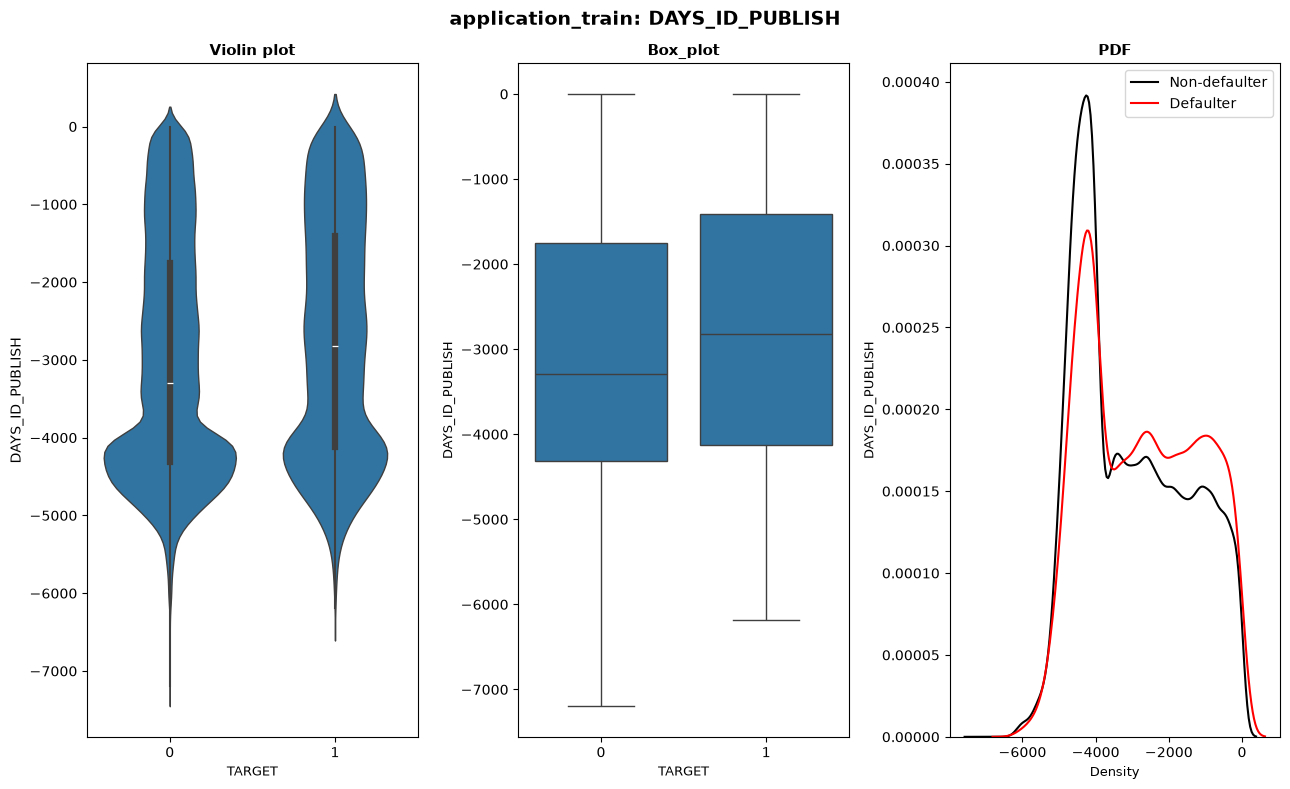

In [25]:
numerical_data_analyzer(df=application_train, dataset='application_train', column='DAYS_ID_PUBLISH')

##### Distribution of EXT_SOURCES

----------------------------------------------------------------------------------------------------
count    107413.000000
mean          0.501650
std           0.211413
min           0.014568
1%            0.083604
5%            0.157482
10%           0.211736
20%           0.295602
30%           0.367974
40%           0.437153
50%           0.505446
60%           0.572678
70%           0.639967
80%           0.710214
90%           0.786923
95%           0.832232
99%           0.890056
max           0.951624
Name: EXT_SOURCE_1, dtype: float64
----------------------------------------------------------------------------------------------------


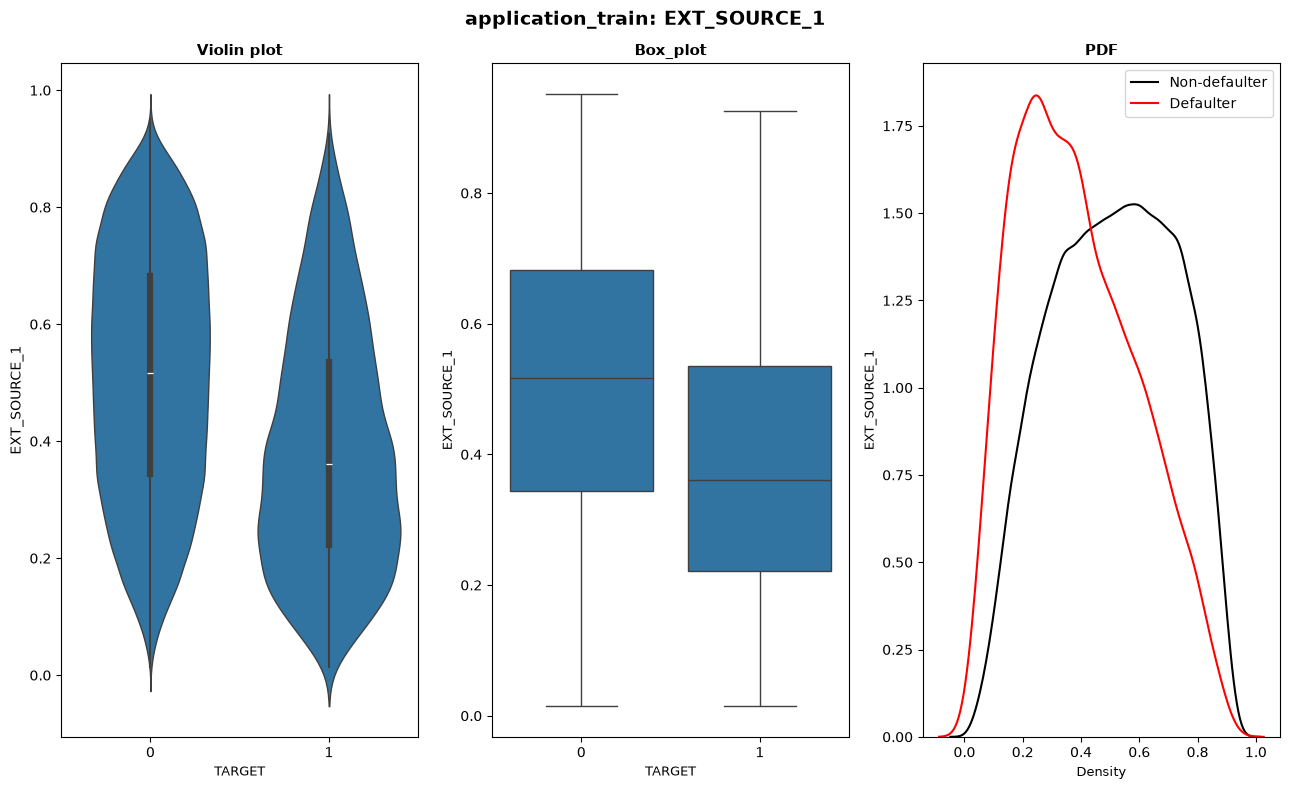

----------------------------------------------------------------------------------------------------
count    2.454770e+05
mean     5.143034e-01
std      1.911257e-01
min      8.173617e-08
1%       2.901289e-02
5%       1.323059e-01
10%      2.153439e-01
20%      3.401563e-01
30%      4.404011e-01
40%      5.121360e-01
50%      5.659131e-01
60%      6.081519e-01
70%      6.457297e-01
80%      6.820451e-01
90%      7.220380e-01
95%      7.478125e-01
99%      7.826933e-01
max      8.549997e-01
Name: EXT_SOURCE_2, dtype: float64
----------------------------------------------------------------------------------------------------


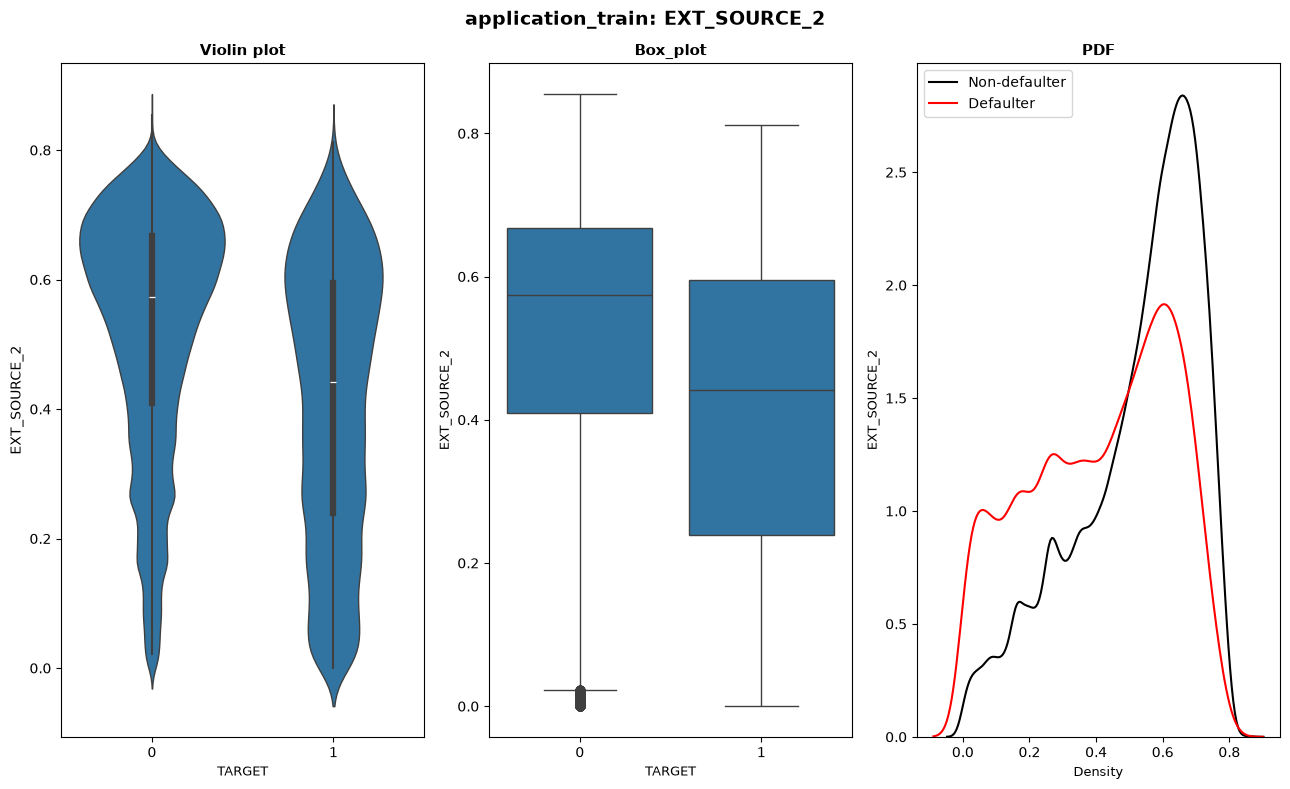

----------------------------------------------------------------------------------------------------
count    197203.000000
mean          0.510871
std           0.194771
min           0.000527
1%            0.064672
5%            0.154744
10%           0.227613
20%           0.329655
30%           0.408359
40%           0.475850
50%           0.535276
60%           0.590233
70%           0.643026
80%           0.694093
90%           0.749022
95%           0.786267
99%           0.833787
max           0.896010
Name: EXT_SOURCE_3, dtype: float64
----------------------------------------------------------------------------------------------------


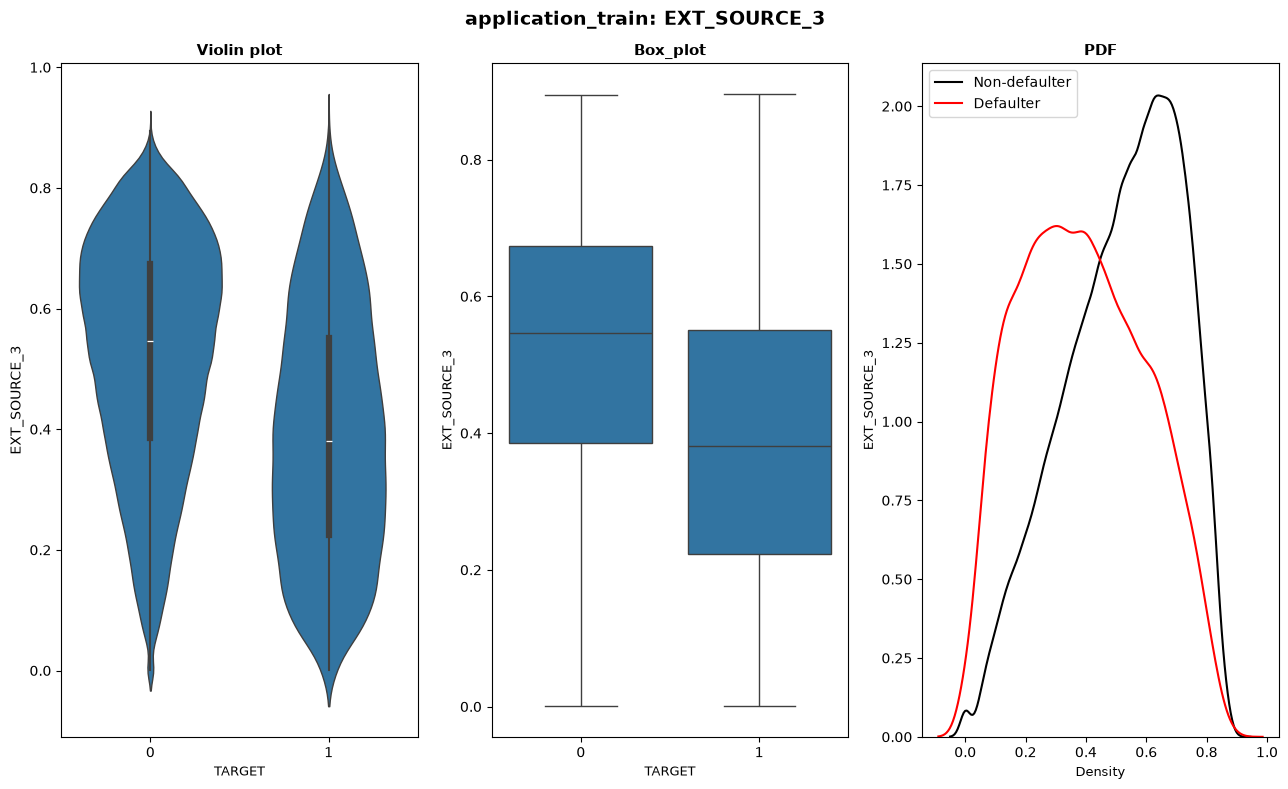

In [26]:
for col in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']:
    numerical_data_analyzer(df=application_train, dataset='application_train', column=col)

- A similar trend for both EXY_SOURCE columns is that the Defaulters tend to have considerably lower values.

- The Non-Defaulter showw a higher peak at high EXT_SOURCEs values and PDF are very low for low values. This implies that Non-Defaulters generally have high values of these scores.

- The median value for defaulters is almost equal to 25th percentile values of Non-Defaulters.

- EXT_SOURCE_1 and 3 show better discrimination/separability as compared to EXT_SOURCE_2.

##### Distribution of AMT columns

In [27]:
application_train['CREDIT_INCOME'] =  application_train['AMT_CREDIT'] / application_train['AMT_INCOME_TOTAL']
application_train['ANNUITY_INCOME'] = application_train['AMT_ANNUITY'] / application_train['AMT_INCOME_TOTAL']
application_train['GOODS_INCOME'] = application_train['AMT_GOODS_PRICE'] / application_train['AMT_INCOME_TOTAL']
application_train['CREDIT_ANNUITY'] = application_train['AMT_CREDIT'] / application_train['AMT_ANNUITY']

C:\Users\Hi Windows 11 Home\AppData\Local\Temp\ipykernel_10948\3422149328.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  application_train['CREDIT_INCOME'] =  application_train['AMT_CREDIT'] / application_train['AMT_INCOME_TOTAL']
C:\Users\Hi Windows 11 Home\AppData\Local\Temp\ipykernel_10948\3422149328.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  application_train['ANNUITY_INCOME'] = application_train['AMT_ANNUITY'] / application_train['AMT_INCOME_TOTAL']
C:\Users\Hi Windows 11 Home\AppData\Local\Temp\ipykernel_1094

----------------------------------------------------------------------------------------------------
count    246008.000000
mean          3.959396
std           2.687597
min           0.004808
1%            0.595789
5%            1.000000
10%           1.332500
20%           1.818182
30%           2.264000
40%           2.764615
50%           3.268948
60%           3.911600
70%           4.731912
80%           5.777121
90%           7.487500
95%           9.145263
99%          13.035710
max          49.227200
Name: CREDIT_INCOME, dtype: float64
----------------------------------------------------------------------------------------------------


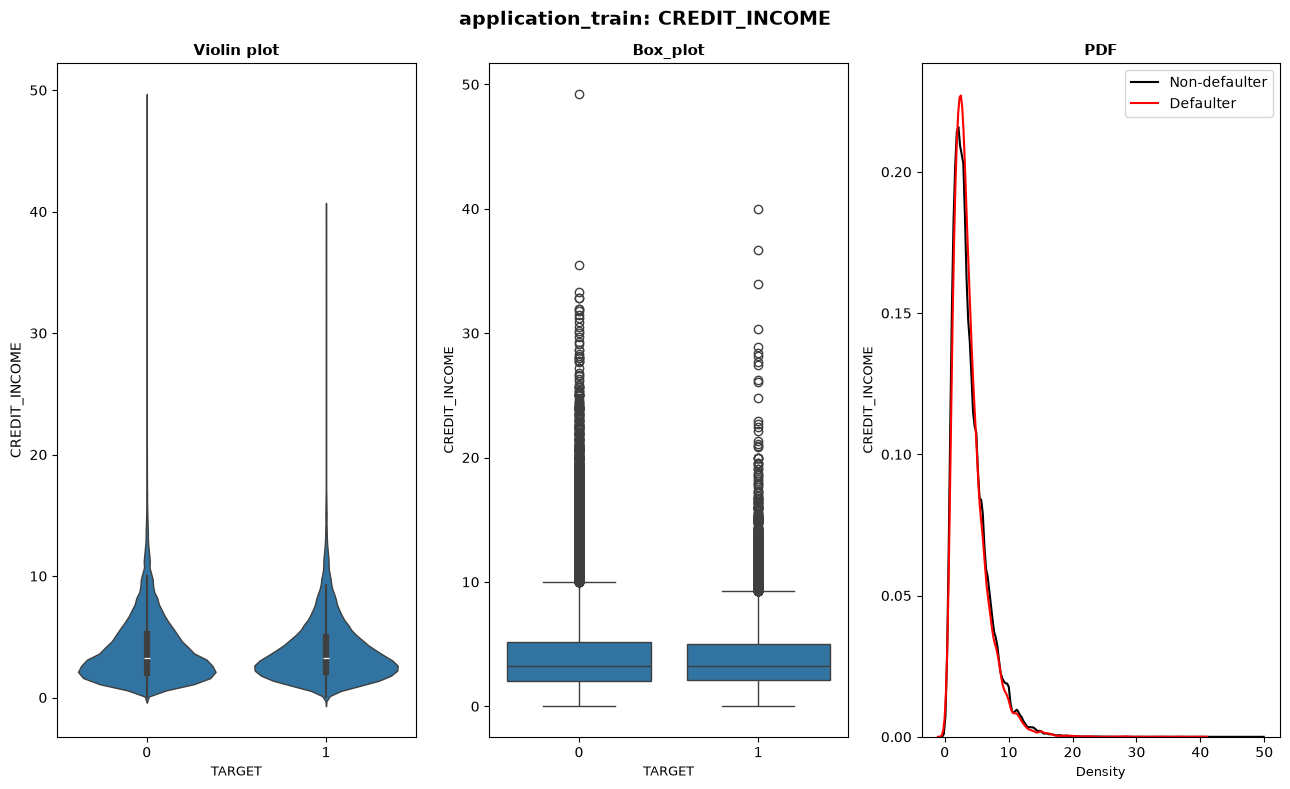

----------------------------------------------------------------------------------------------------
count    245998.000000
mean          0.180911
std           0.094571
min           0.000224
1%            0.039371
5%            0.062600
10%           0.080000
20%           0.103507
30%           0.124750
40%           0.143800
50%           0.162833
60%           0.185767
70%           0.212499
80%           0.246689
90%           0.301750
95%           0.354701
99%           0.483850
max           1.570600
Name: ANNUITY_INCOME, dtype: float64
----------------------------------------------------------------------------------------------------


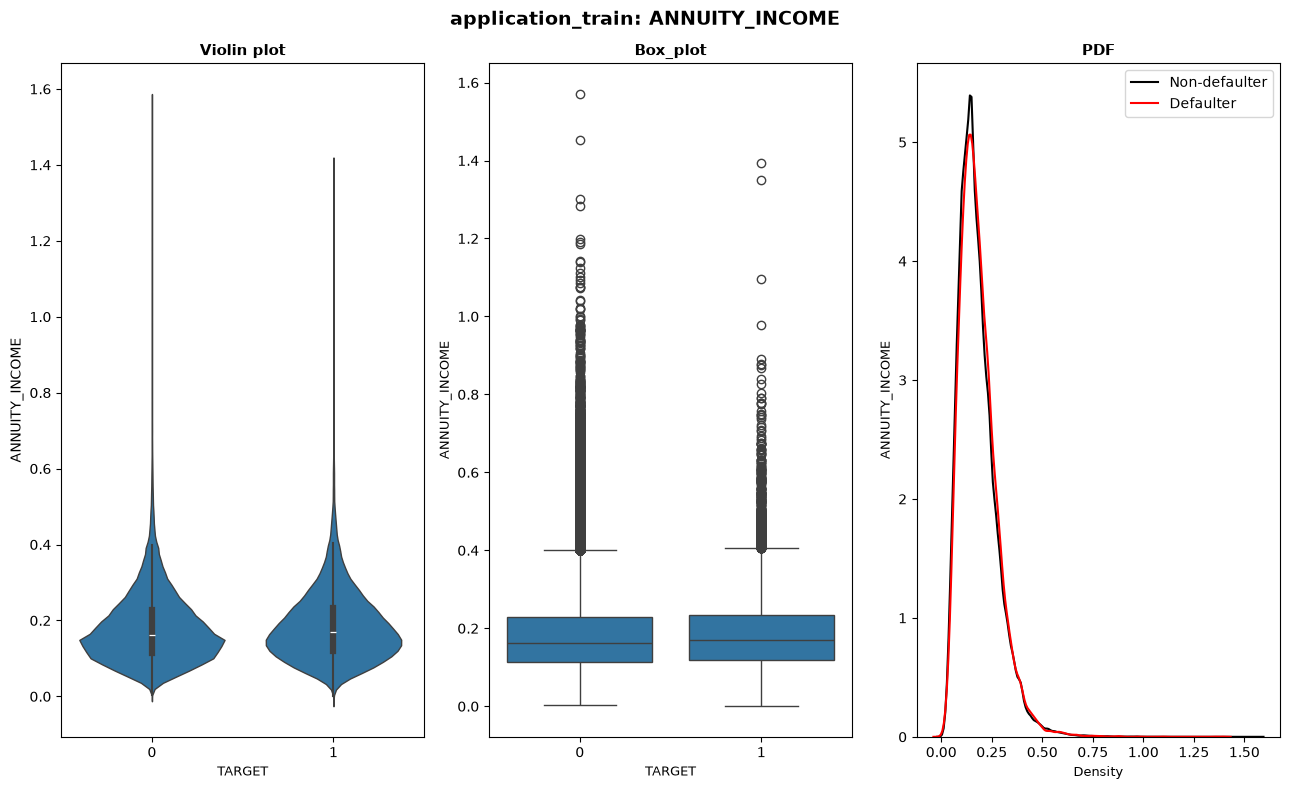

----------------------------------------------------------------------------------------------------
count    245787.000000
mean          3.545693
std           2.423496
min           0.003885
1%            0.533333
5%            0.909091
10%           1.200000
20%           1.666667
30%           2.000000
40%           2.500000
50%           2.941176
60%           3.419721
70%           4.166667
80%           5.050000
90%           6.666667
95%           8.268462
99%          11.954822
max          44.000000
Name: GOODS_INCOME, dtype: float64
----------------------------------------------------------------------------------------------------


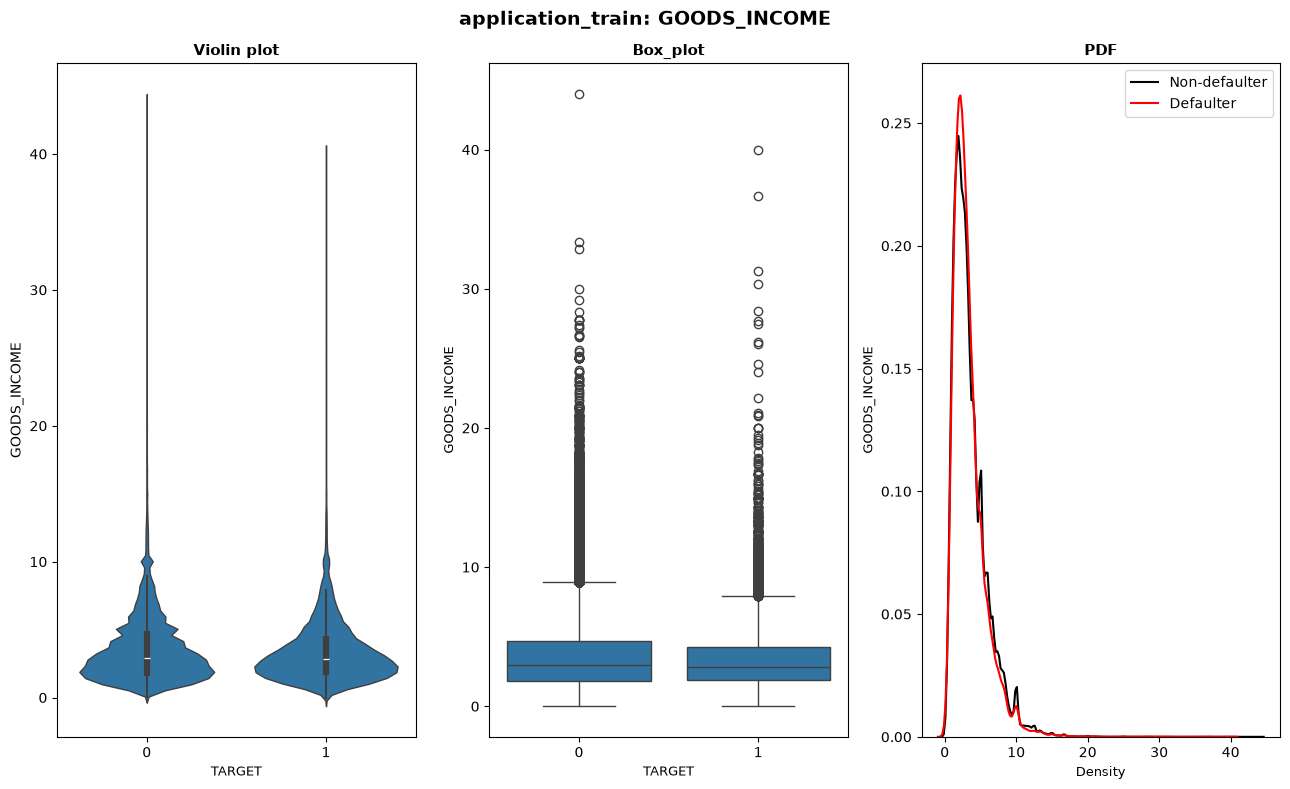

----------------------------------------------------------------------------------------------------
count    245998.000000
mean         21.624291
std           7.820534
min           8.036674
1%            8.733699
5%            9.523810
10%          10.528274
20%          14.658458
30%          17.791264
40%          19.536719
50%          20.000000
60%          22.038015
70%          25.214776
80%          30.143117
90%          34.063122
95%          34.555171
99%          37.794571
max          45.305079
Name: CREDIT_ANNUITY, dtype: float64
----------------------------------------------------------------------------------------------------


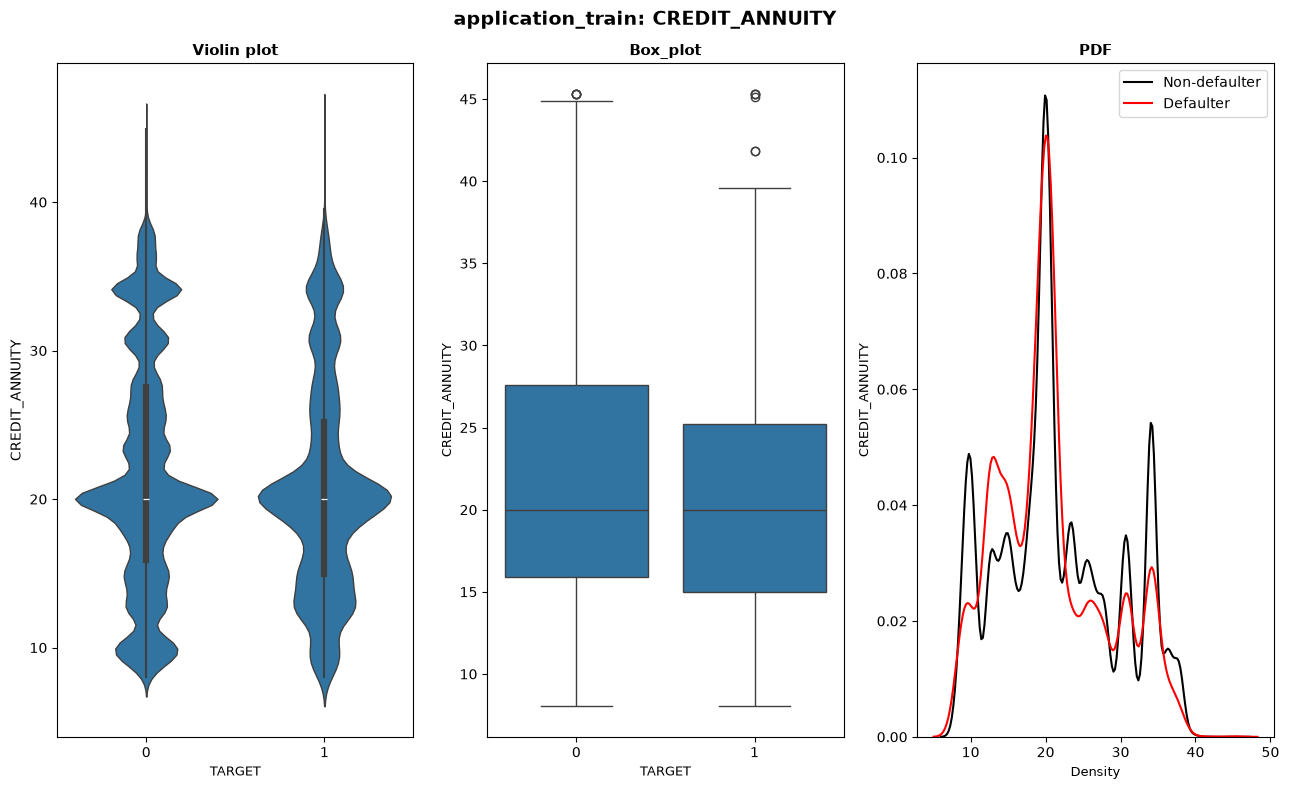

In [28]:
for col in ['CREDIT_INCOME', 'ANNUITY_INCOME', 'GOODS_INCOME', 'CREDIT_ANNUITY']:
    numerical_data_analyzer(df=application_train, dataset='application_train', column=col)

- `CREDIT_INCOME`: Displays high overlap in core distributions (medians ~2–4) between non-defaulters and defaulters. Non-defaulters exhibit a longer tail of high leverage ratios (>10), meaning extreme credit-to-income values alone do not strongly isolate default risk.

- `ANNUITY_INCOME`: Showcases nearly identical PDF density curves and box plot medians (~0.16–0.18) across both classes. Standalone predictive power is weak due to minimal separation, though it remains a crucial baseline capacity metric.

- `GOODS_INCOME`: Both groups present heavily right-skewed distributions. Defaulters exhibit a higher density peak at lower ratios (<5), indicating that applicants purchasing lower-value goods relative to their income carry a slightly higher default probability.

- `CREDIT_ANNUITY`: Demonstrates the strongest separation signal among all four features. The PDF reveals clear multimodal peaks at ~10, 20, 30, and 34 (corresponding to standard loan payment terms). Defaulters are noticeably more concentrated in the lower term range (10–15 months).

### Bureau.csv

In [31]:
bureau_train.columns

Index(['SK_ID_CURR', 'SK_ID_BUREAU', 'CREDIT_ACTIVE', 'CREDIT_CURRENCY',
       'DAYS_CREDIT', 'CREDIT_DAY_OVERDUE', 'DAYS_CREDIT_ENDDATE',
       'DAYS_ENDDATE_FACT', 'AMT_CREDIT_MAX_OVERDUE', 'CNT_CREDIT_PROLONG',
       'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_LIMIT',
       'AMT_CREDIT_SUM_OVERDUE', 'CREDIT_TYPE', 'DAYS_CREDIT_UPDATE',
       'AMT_ANNUITY'],
      dtype='str')

##### NaN columns

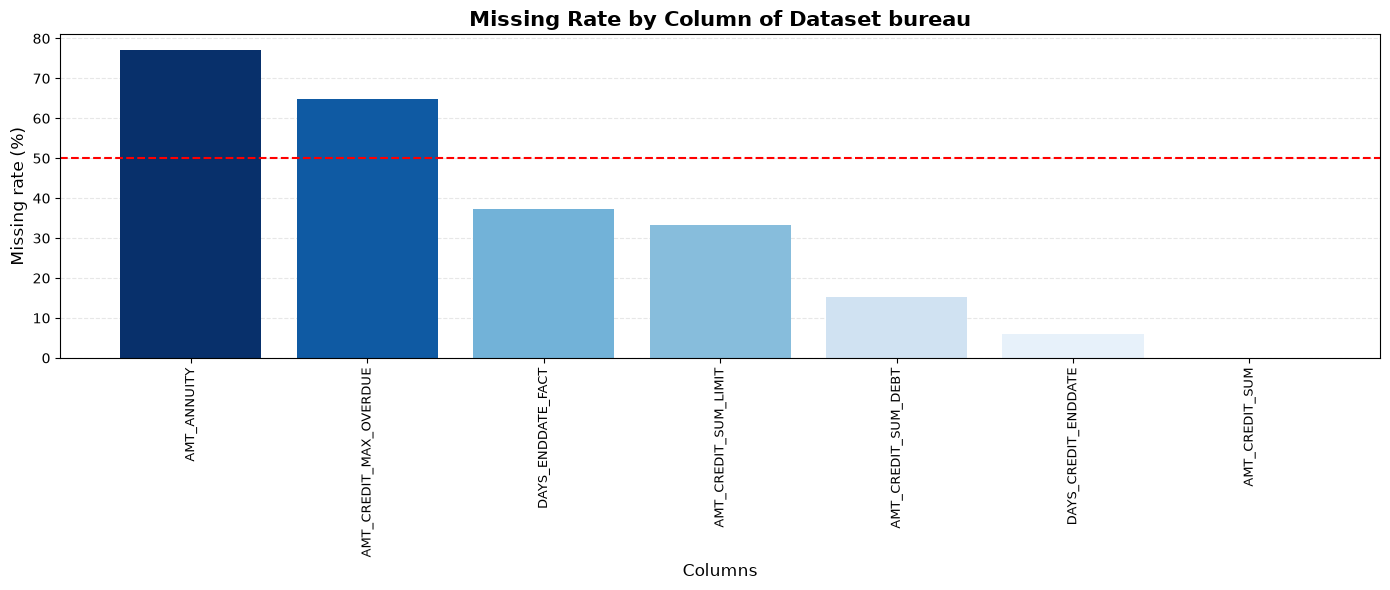

In [29]:
nan_plot_values_count(df=bureau_train, dataset='bureau')

The highest NaN values are observed with the column AMT_ANNUITY which has more 70% missing values.

We focus on the predictive power of model. In the nextstep, I will merge dataset with application_train.csv via `SK_ID_CURR`

In [30]:
bureau_merged = application_train.iloc[:,:2].merge(bureau_train, on='SK_ID_CURR', how='left')

##### Phi_K matrix

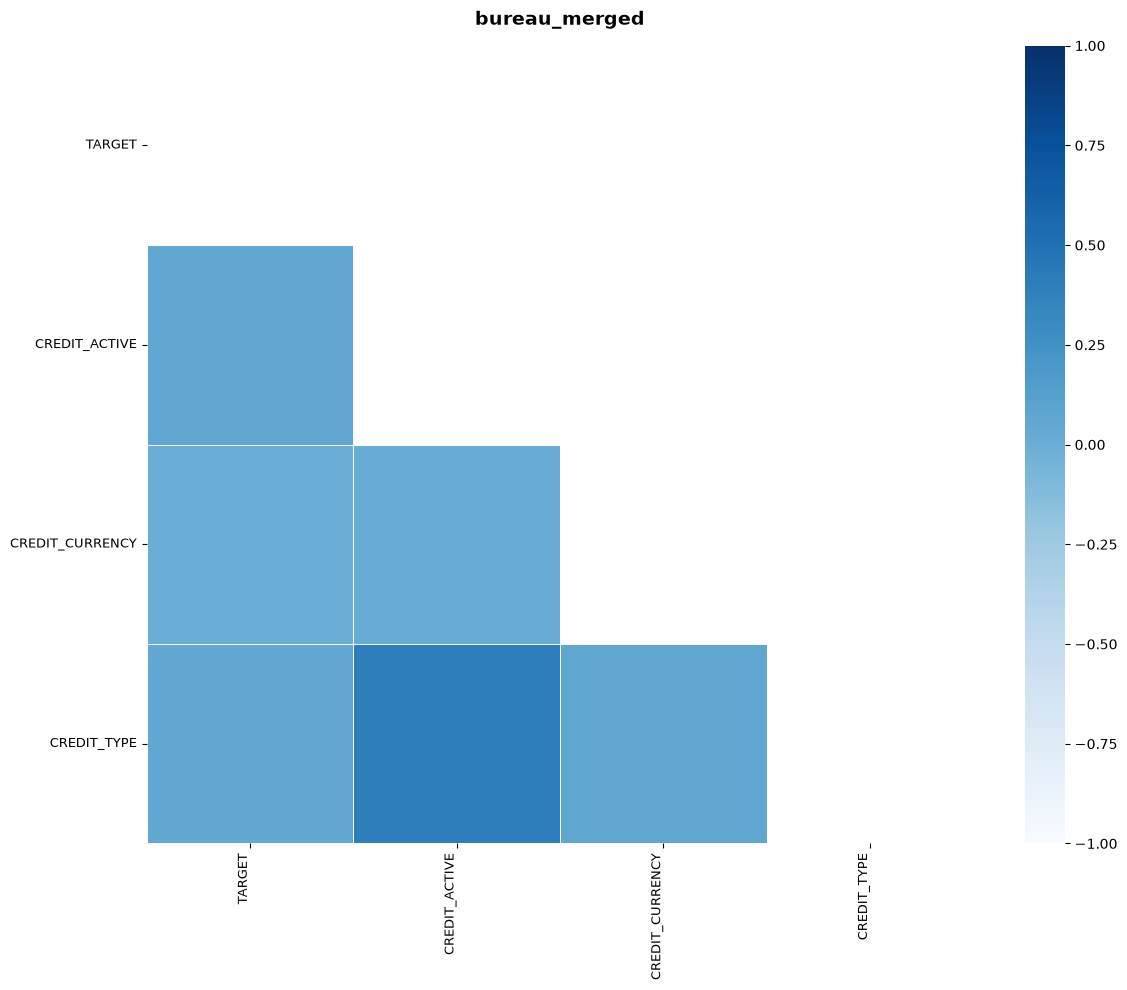

In [33]:
corr_bureau_merged = CorrelationAnalyzer(df=bureau_merged)
matrix = corr_bureau_merged.phi_k_corr(['TARGET', 'CREDIT_ACTIVE', 'CREDIT_CURRENCY', 'CREDIT_TYPE'])
corr_bureau_merged.plot_heatmap(
    corr_matrix=matrix,
    title='bureau_merged'
)

In [34]:
corr_bureau_merged.top_target_phi_k(5, ['TARGET', 'CREDIT_ACTIVE', 'CREDIT_CURRENCY', 'CREDIT_TYPE'])

CREDIT_ACTIVE      0.063108
CREDIT_TYPE        0.048695
CREDIT_CURRENCY    0.005067
Name: TARGET, dtype: float64

- `CREDIT_ACTIVE` shows some association with the variable `CREDIT_TYPE`

- The Categorical Variables don't really have a high association with `TARGET`, especially `CREDIT_CURRENCY`

##### Correlation Matrix

In [37]:
num_cols = bureau_train.select_dtypes(include=['number']).columns[~bureau_train.select_dtypes(include=['number']).columns.isin(['TARGET', 'CREDIT_ACTIVE', 'CREDIT_CURRENCY', 'CREDIT_TYPE'])].to_list()

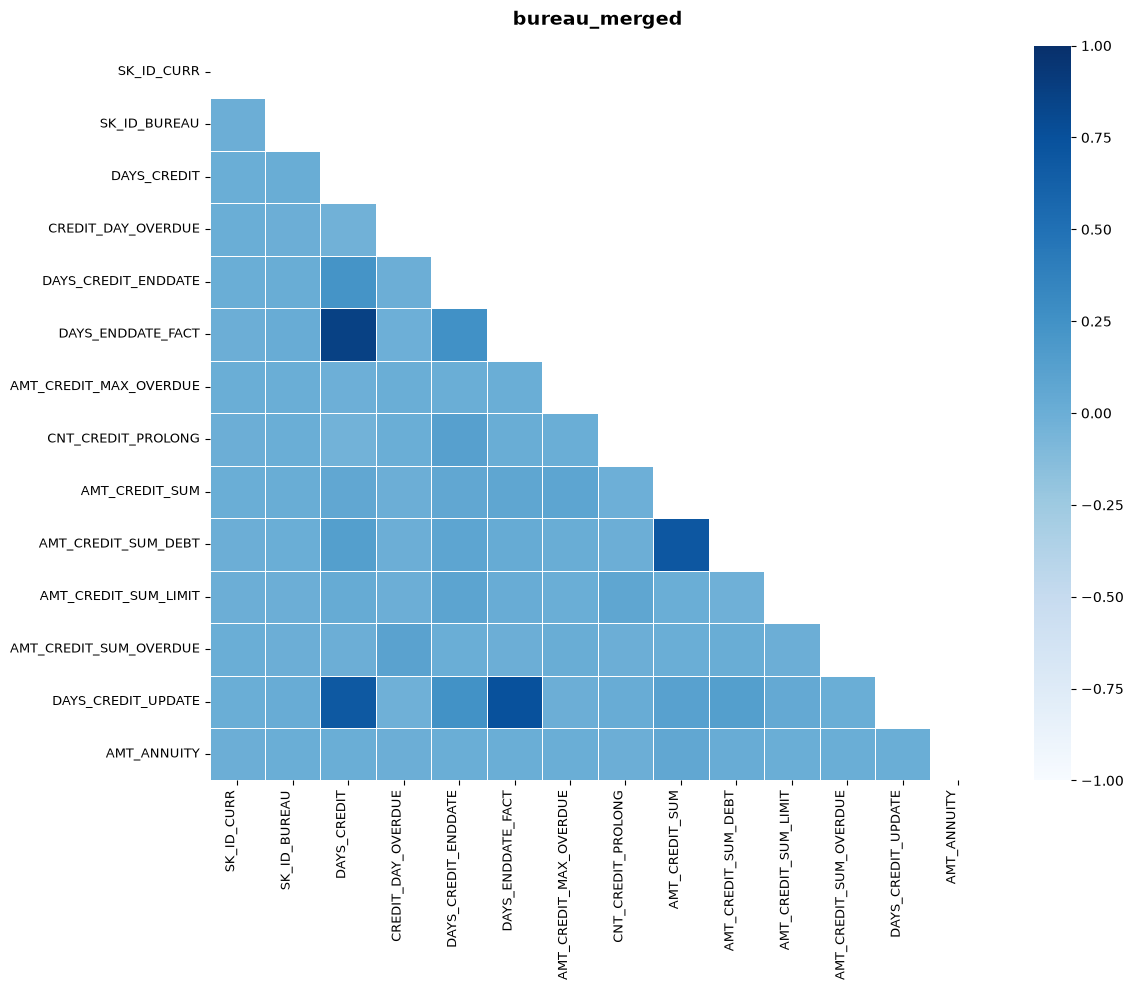

In [39]:
corr_mat = corr_bureau_merged.pearson_corr(num_cols)
corr_bureau_merged.plot_heatmap(corr_matrix=corr_mat, title='bureau_merged')

In [40]:
corr_bureau_merged.top_target_phi_k(10, num_cols)

DAYS_CREDIT               0.086450
SK_ID_BUREAU              0.020578
DAYS_CREDIT_ENDDATE       0.018313
SK_ID_CURR                0.007038
AMT_CREDIT_SUM_LIMIT      0.006875
AMT_CREDIT_MAX_OVERDUE    0.006129
AMT_CREDIT_SUM_OVERDUE    0.006048
CNT_CREDIT_PROLONG        0.004216
CREDIT_DAY_OVERDUE        0.002872
AMT_CREDIT_SUM            0.002355
Name: TARGET, dtype: float64

- The heatmap shows that the correlation between each feature is almost weak, but some high correlation is still easily observed:

    + `DAYS_CREDIT` and `DAYS_UPDATE`

    + `DAYS_ENDDATE_FACT` and `DAYS_CREDIT_UPDATE`

    + `AMT_CREDIT_SUM` and `AMT_CREDIT_DEBT`

    + `DAYS_ENDDATE_FACT` and `DAYS_CREDIT`

##### CREDIT_ACTIVE

----------------------------------------------------------------------------------------------------
  CREDIT_ACTIVE  Total_count  Default_count   Rate
0        Active       433530          40224   9.28
1      Bad debt           16              4  25.00
2        Closed       733220          51105   6.97
3            NA        35244           3567  10.12
4          Sold         4533            456  10.06
----------------------------------------------------------------------------------------------------


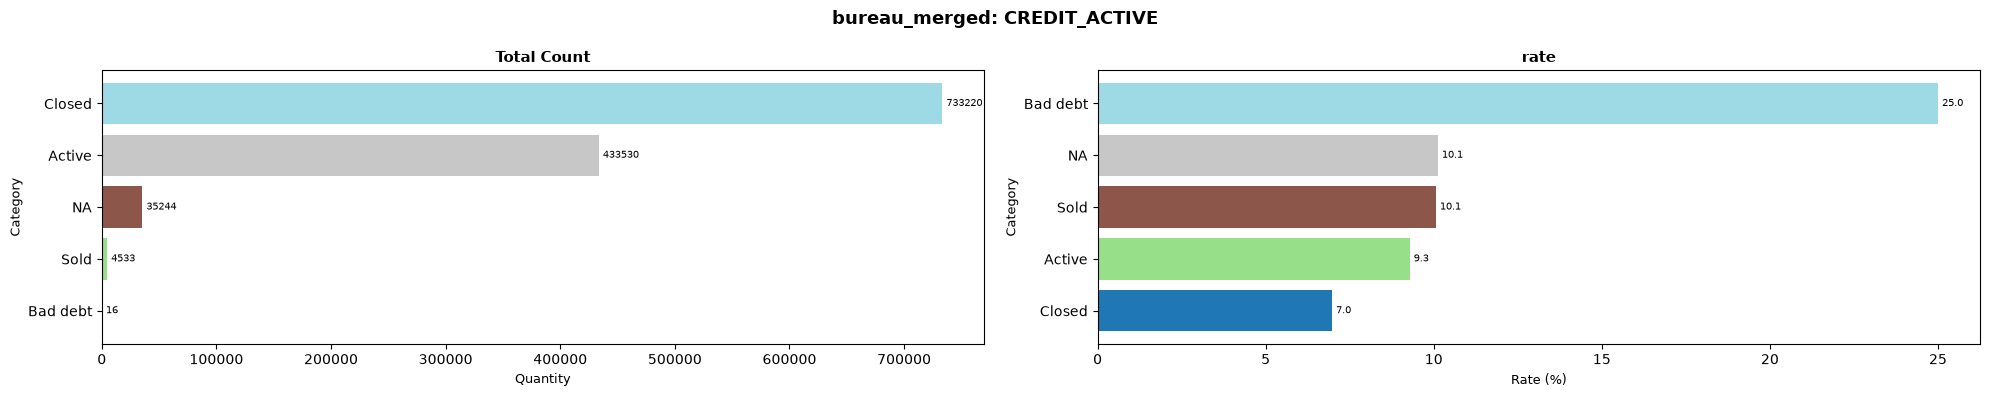

In [41]:
categorical_data_analyzer(df=bureau_merged, dataset='bureau_merged', column='CREDIT_ACTIVE')

- A majority of the previous loans from other financial institutions are closed Loan (62.63%), followed by 36.98% active loán. The Bad debt and Sold group are very less in number.

- The Bad Debt leads the percentage of Defaulter (clearly understanding), folloed by Sold loans and Active loans. The lowest default rate is for Closed Loans, which show a good history about a client.

##### CREDIT_TYPE

----------------------------------------------------------------------------------------------------
                                     CREDIT_TYPE  Total_count  Default_count  \
0                           Another type of loan          693             50   
1                                       Car loan        18953           1067   
2                      Cash loan (non-earmarked)           19              1   
3                                Consumer credit       854877          64216   
4                                    Credit card       275037          24219   
5                               Interbank credit            1              0   
6                  Loan for business development         1363             90   
7   Loan for purchase of shares (margin lending)            3              0   
8             Loan for the purchase of equipment           12              2   
9         Loan for working capital replenishment          278             33   
10                 

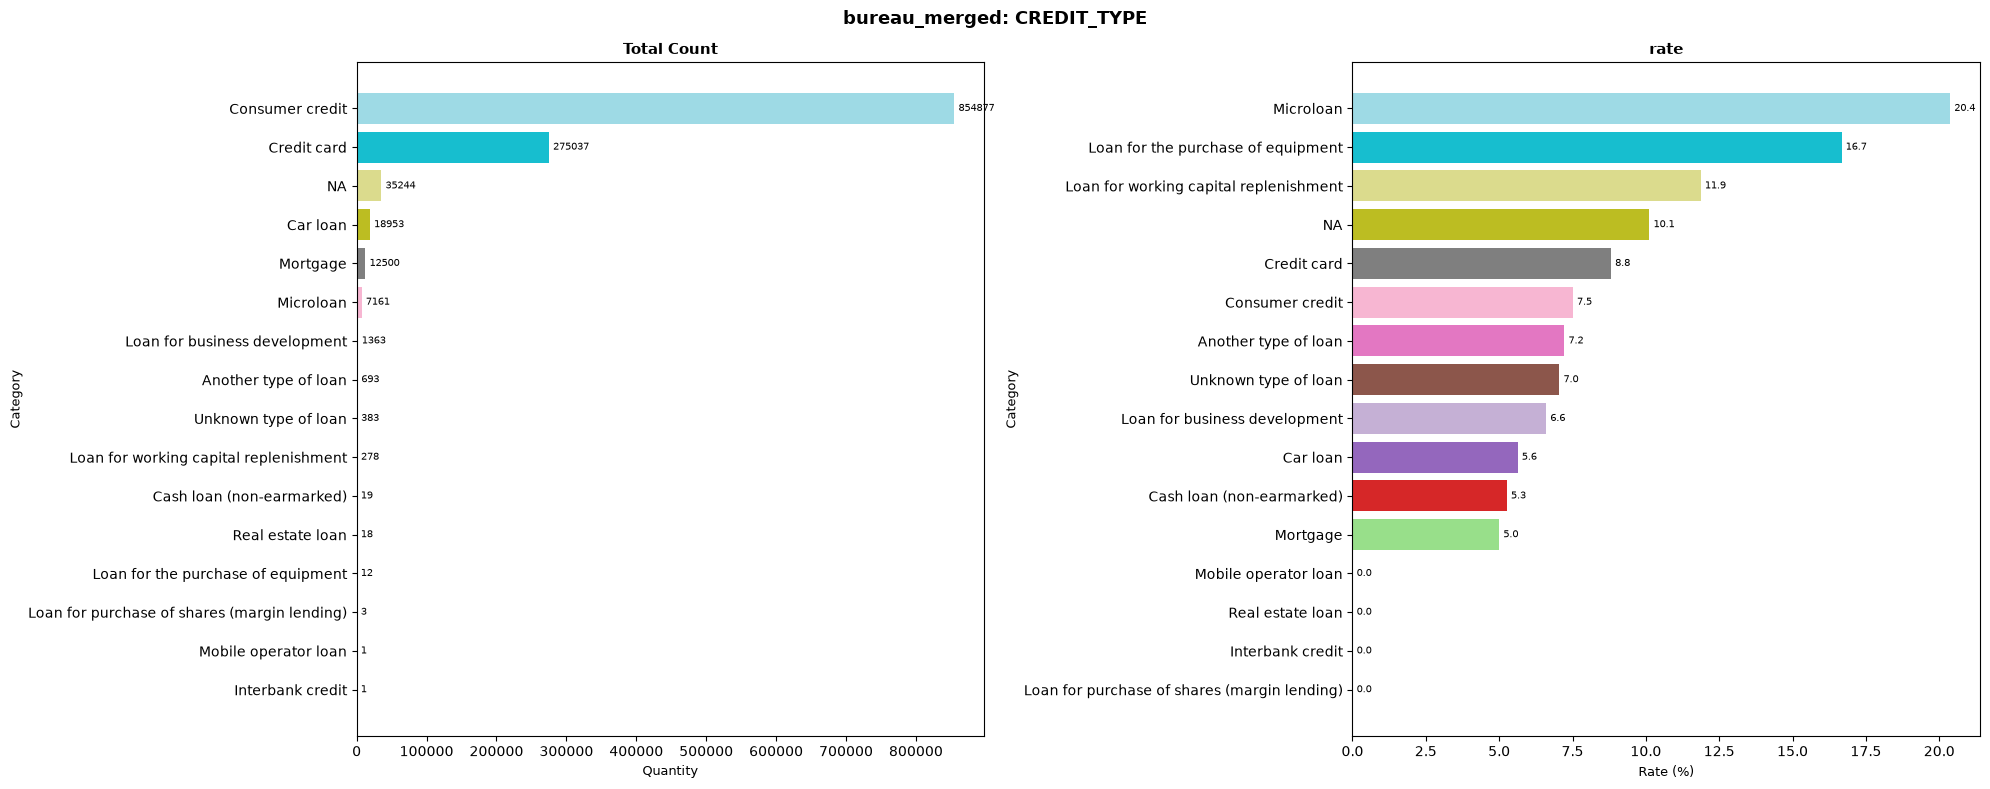

In [42]:
categorical_data_analyzer(df=bureau_merged, dataset='bureau_merged', column='CREDIT_TYPE')

- Highest Default Risk: Microloan records exhibit the highest default rate by a substantial margin (20.37% across 7,161 loans), followed by niche business products like Loan for the purchase of equipment (16.67%) and Loan for working capital replenishment (11.87%). Unspecified/Missing records (NA) also carry elevated risk (10.12%).

- Dominant Volume Categories: The dataset is heavily dominated by Consumer credit (854,877 loans, 7.51% default rate) and Credit card (275,037 loans, 8.81% default rate), which together constitute over 90% of all bureau records.

- Lowest Risk: Mortgage (5.00%), Cash loan (non-earmarked) (5.26%), and Car loan (5.63%) display significantly lower default rates, likely due to collateral requirements and stricter underwriting standards.

- Historical credit type in the bureau table strongly partitions risk profiles. Borrowers with past microloans or unsecured high-frequency credit present a markedly higher risk of default compared to collateralized borrowers (mortgages/car loans). Grouping rare categories and encoding risk weights by credit type will yield strong predictive signals.

##### DAYS_CREDIT

----------------------------------------------------------------------------------------------------
count    1.171299e+06
mean     3.131403e+00
std      2.191342e+00
min     -0.000000e+00
1%       1.040383e-01
5%       3.340178e-01
10%      5.776865e-01
20%      1.043121e+00
30%      1.538672e+00
40%      2.084052e+00
50%      2.696783e+00
60%      3.345654e+00
70%      4.117728e+00
80%      5.193703e+00
90%      6.704997e+00
95%      7.301848e+00
99%      7.852156e+00
max      8.000000e+00
Name: YEARS_CREDIT, dtype: float64
----------------------------------------------------------------------------------------------------


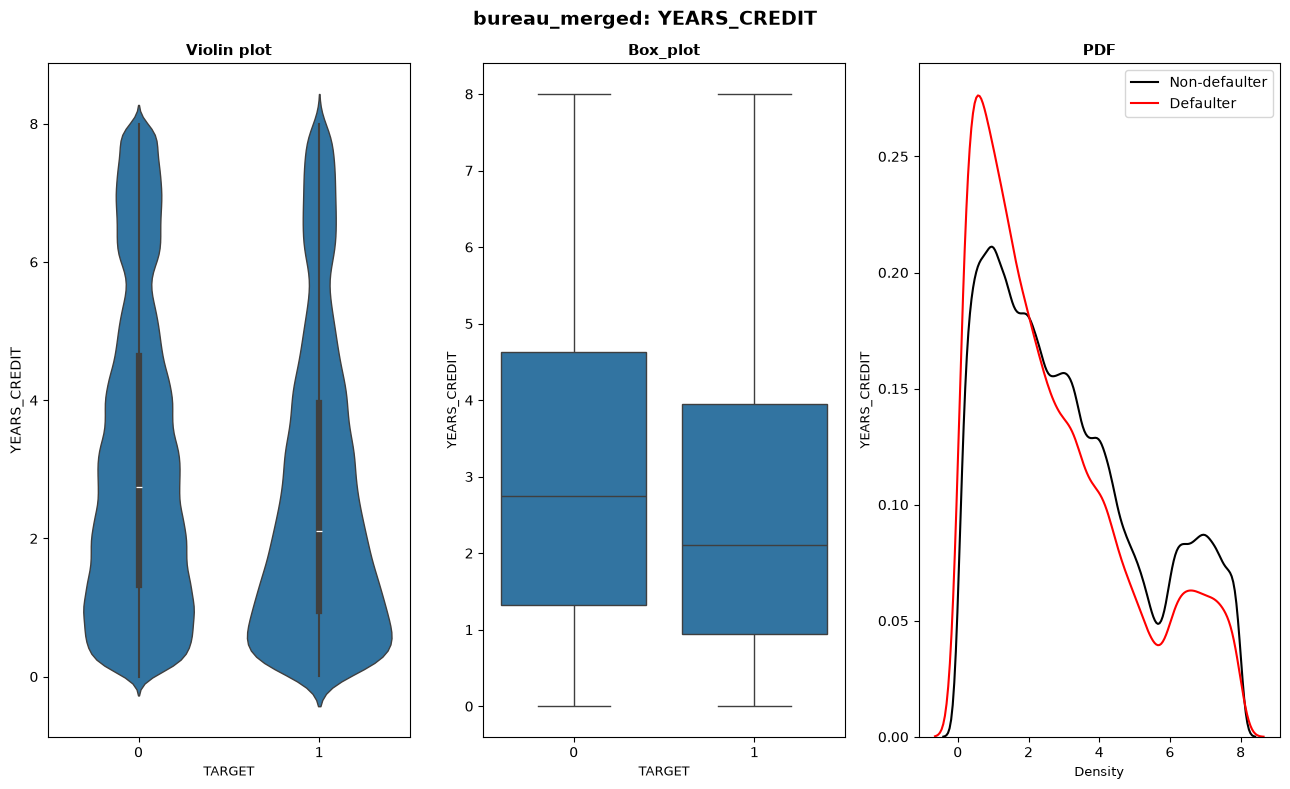

In [44]:
bureau_merged['YEARS_CREDIT'] = -bureau_merged['DAYS_CREDIT'] / 365.25
numerical_data_analyzer(df=bureau_merged, dataset='bureau_merged', column='YEARS_CREDIT')

The Defaulter tend to have higher peaks compared to Non-Defaulter when the number of years are less. This implies that the applicants who had applied for loans from Credit Bureau recently showed more defaulting tendecy than those who had applied long ago. We see that Defaultergs usually had less `YEARS_CREDIT` as compared to Non-Defaulter

##### DAYS_CREDIT_ENDDATE

----------------------------------------------------------------------------------------------------
count    1.100210e+06
mean     4.966363e+02
std      4.969955e+03
min     -4.206000e+04
1%      -2.573000e+03
5%      -2.268000e+03
10%     -1.939000e+03
20%     -1.364000e+03
30%     -9.540000e+02
40%     -6.300000e+02
50%     -3.330000e+02
60%     -6.100000e+01
70%      2.470000e+02
80%      7.260000e+02
90%      1.333000e+03
95%      2.431550e+03
99%      3.106200e+04
max      3.119900e+04
Name: DAYS_CREDIT_ENDDATE, dtype: float64
----------------------------------------------------------------------------------------------------


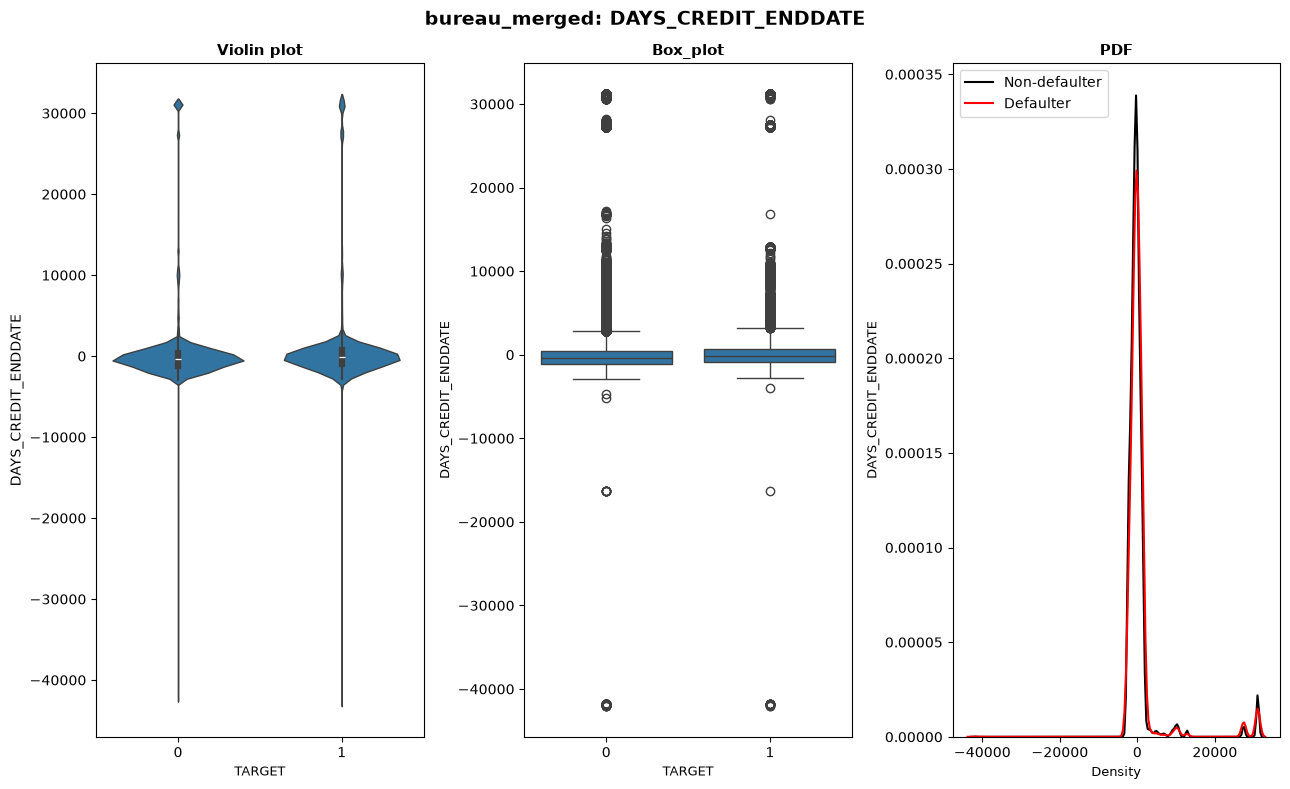

In [45]:
numerical_data_analyzer(df=bureau_merged, dataset='bureau_merged', column='DAYS_CREDIT_ENDDATE')

Errorneous for DAYS_CREDIT_ENDDATE, where the 0th percentile value dates back to as long as 42060 days or 115 years. We would try to remove these values in the data preprocessing stage

##### DAYS_ENDDATE_FACT

This column show the number of days ago that the information from Credit Bureau credit had ended at the time of application for loan in Home Credit. These values are only for Closed Credits

----------------------------------------------------------------------------------------------------
count    735562.000000
mean      -1022.802521
std         719.047253
min      -42023.000000
1%        -2642.000000
5%        -2399.000000
10%       -2175.000000
20%       -1695.000000
30%       -1335.000000
40%       -1080.000000
50%        -899.000000
60%        -702.000000
70%        -512.000000
80%        -341.000000
90%        -177.000000
95%         -94.000000
99%         -24.000000
max           0.000000
Name: DAYS_ENDDATE_FACT, dtype: float64
----------------------------------------------------------------------------------------------------


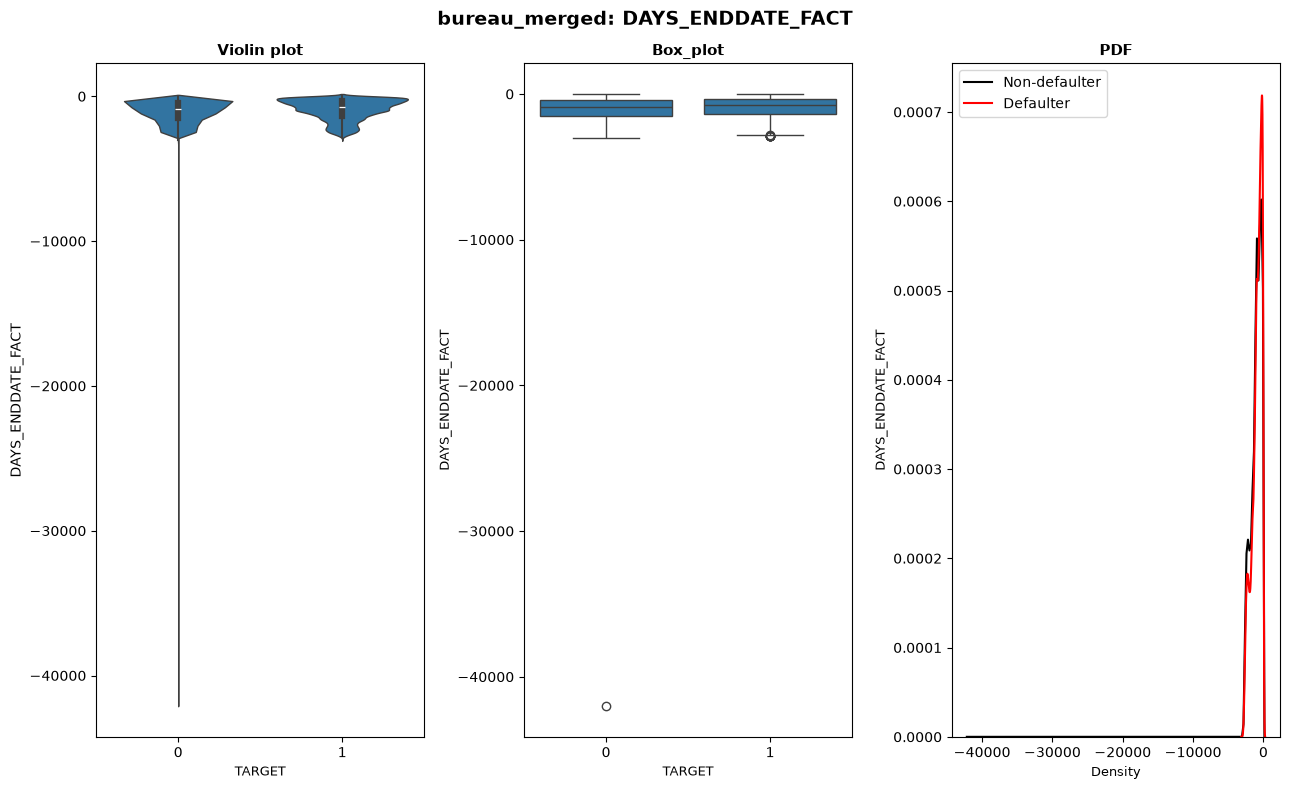

In [46]:
numerical_data_analyzer(df=bureau_merged, dataset='bureau_merged', column='DAYS_ENDDATE_FACT')

- Similar errorneous value like previous column we have analyzed.

- The Defaulter tend to have lesser number of Days since their Credit Bureau credit had ended. The Non-Defaulters usually have their previous credits ended longer before than Defaulter

##### DAYS_CREDIT_UPDATE

This column tells about the the number of days ago that the information from Credit Bureau credit had come at the time of application for loan in Home Credit.

----------------------------------------------------------------------------------------------------
count    1.171299e+06
mean    -5.996086e+02
std      7.374406e+02
min     -4.194700e+04
1%      -2.537000e+03
5%      -2.111000e+03
10%     -1.582000e+03
20%     -1.043000e+03
30%     -7.930000e+02
40%     -6.120000e+02
50%     -4.050000e+02
60%     -1.890000e+02
70%     -5.200000e+01
80%     -2.500000e+01
90%     -1.300000e+01
95%     -8.000000e+00
99%     -3.000000e+00
max      3.720000e+02
Name: DAYS_CREDIT_UPDATE, dtype: float64
----------------------------------------------------------------------------------------------------


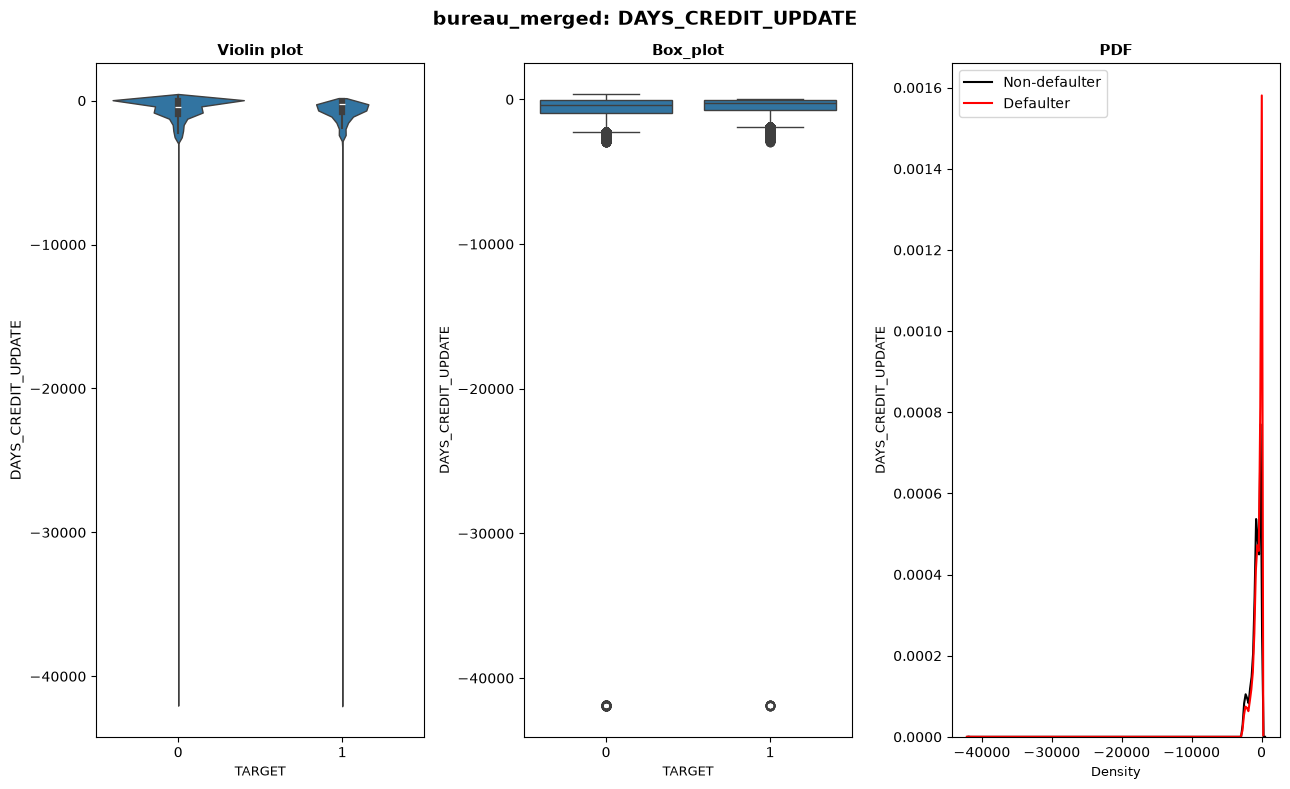

In [47]:
numerical_data_analyzer(df=bureau_merged, dataset='bureau_merged', column='DAYS_CREDIT_UPDATE')

- The trend of erroneious values is again very similar to the other days column where this 0th percentile value seems to be erroneous. Also since only the 0th percentile value is so odd, and the rest seem to be fine, thus this value is definitely erroneous. We will be removing this value too.

- From the box-plot, we can say that the Defaulters tend to have a lesser number of days since their Information about the Credit Bureau Credit were received. Their median, 75th percentile values all are lesser than those for Non-Defaulters.

##### previous_application.csv

##### Missing_values

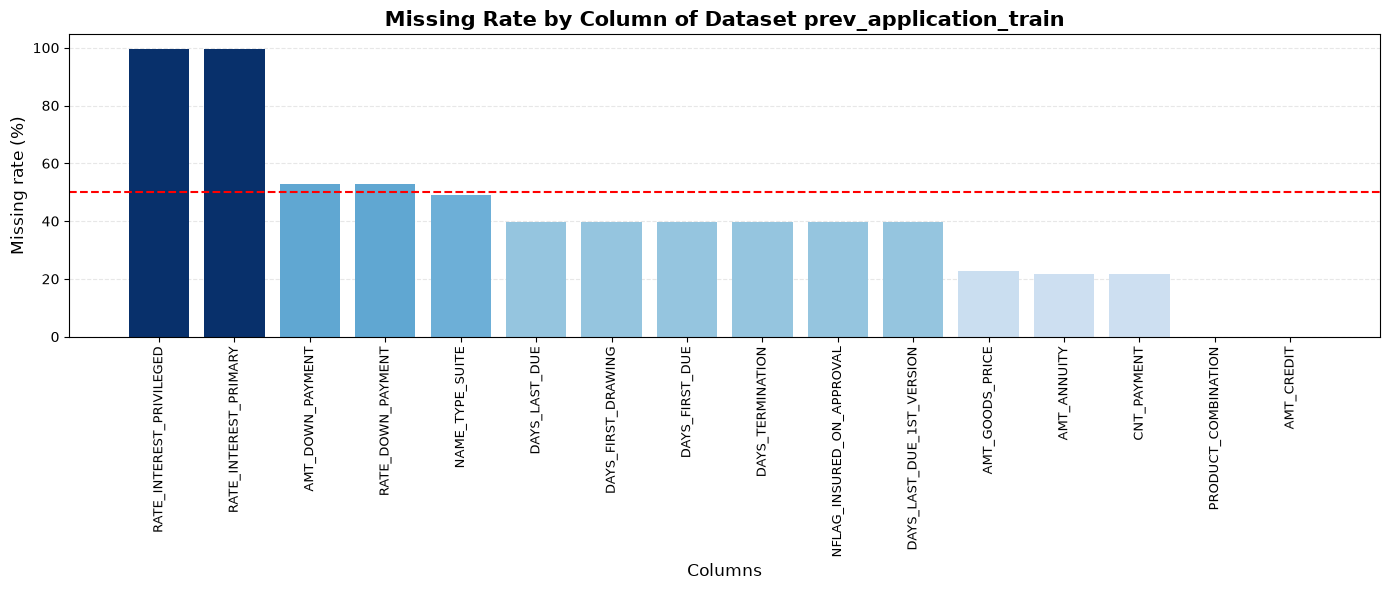

In [48]:
nan_plot_values_count(df=prev_application_train, dataset='prev_application_train')

- `RATE_INTEREST_PREVILEGED` and `RATE_INTEREST_PRIMARY` have 99.64% missing values - a very high number.

-  Other than these 2 columns, most of the rest of the column also contain > 40% NaN values.

In [51]:
prev_application_train.dtypes

SK_ID_PREV                       int64
SK_ID_CURR                       int64
NAME_CONTRACT_TYPE                 str
AMT_ANNUITY                    float64
AMT_APPLICATION                float64
AMT_CREDIT                     float64
AMT_DOWN_PAYMENT               float64
AMT_GOODS_PRICE                float64
WEEKDAY_APPR_PROCESS_START         str
HOUR_APPR_PROCESS_START          int64
FLAG_LAST_APPL_PER_CONTRACT        str
NFLAG_LAST_APPL_IN_DAY           int64
RATE_DOWN_PAYMENT              float64
RATE_INTEREST_PRIMARY          float64
RATE_INTEREST_PRIVILEGED       float64
NAME_CASH_LOAN_PURPOSE             str
NAME_CONTRACT_STATUS               str
DAYS_DECISION                    int64
NAME_PAYMENT_TYPE                  str
CODE_REJECT_REASON                 str
NAME_TYPE_SUITE                    str
NAME_CLIENT_TYPE                   str
NAME_GOODS_CATEGORY                str
NAME_PORTFOLIO                     str
NAME_PRODUCT_TYPE                  str
CHANNEL_TYPE             

In [49]:
prev_merged = application_train.iloc[:,:2].merge(prev_application_train, how='left', on='SK_ID_CURR')

##### Phi_K matrix

In [53]:
corr_prev_merged = CorrelationAnalyzer(df=prev_merged)
col_for_phik = ['TARGET'] + prev_merged.dtypes[prev_merged.dtypes == 'str'].index.tolist() + ['NFLAG_INSURED_ON_APPROVAL']
phi_k_mat = corr_prev_merged.phi_k_corr(col_for_phik)

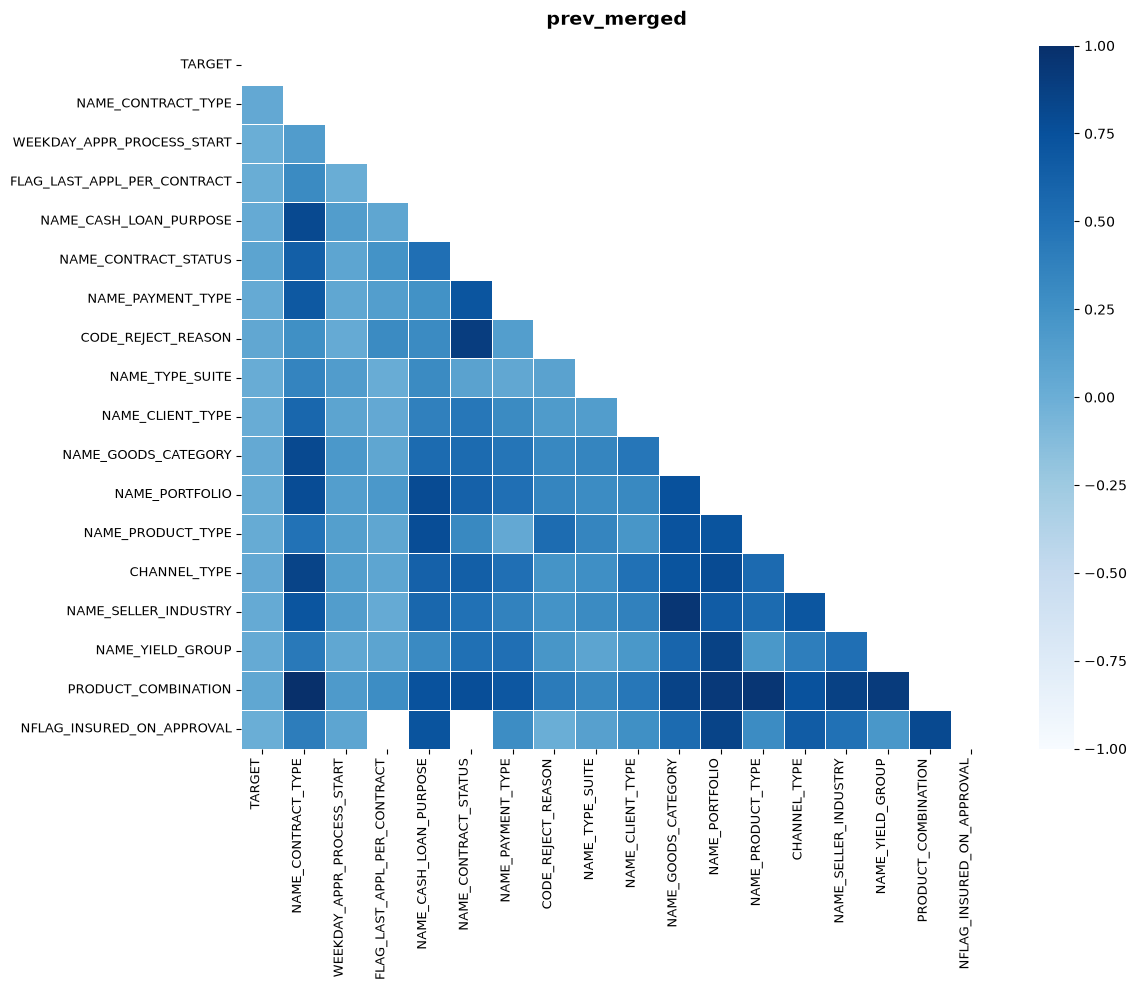

In [54]:
corr_prev_merged.plot_heatmap(
    corr_matrix=phi_k_mat,
    title='prev_merged'
)

In [55]:
corr_prev_merged.top_target_phi_k(10, col_for_phik)

NAME_CONTRACT_STATUS      0.087034
PRODUCT_COMBINATION       0.063802
CODE_REJECT_REASON        0.062479
CHANNEL_TYPE              0.049532
NAME_CONTRACT_TYPE        0.048591
NAME_GOODS_CATEGORY       0.042734
NAME_CASH_LOAN_PURPOSE    0.038883
NAME_PAYMENT_TYPE         0.037808
NAME_SELLER_INDUSTRY      0.037611
NAME_YIELD_GROUP          0.034876
Name: TARGET, dtype: float64

- Feature `PRODUCT_COMBINATION` shows association with lots of other features such as `NAME_CONTRACT_TYPE`, `NAME_PORTFOLIO`, `NAME_YIELD_GROUP`. `NAME_GOODS_CATEGORY` and `NAME_SELLER_INDUSTRY` have good association with each other.

- `NAME_CONTRACT_STATUS`, `PRODUCT_COMBINATION` and `CODE_REJECT_REASON` are 3 of the highest associated with TARGET.

In [58]:
cols_corr = prev_application_train.select_dtypes(include=['number']).columns[~prev_application_train.select_dtypes(include=['number']).columns.isin(col_for_phik)].tolist()

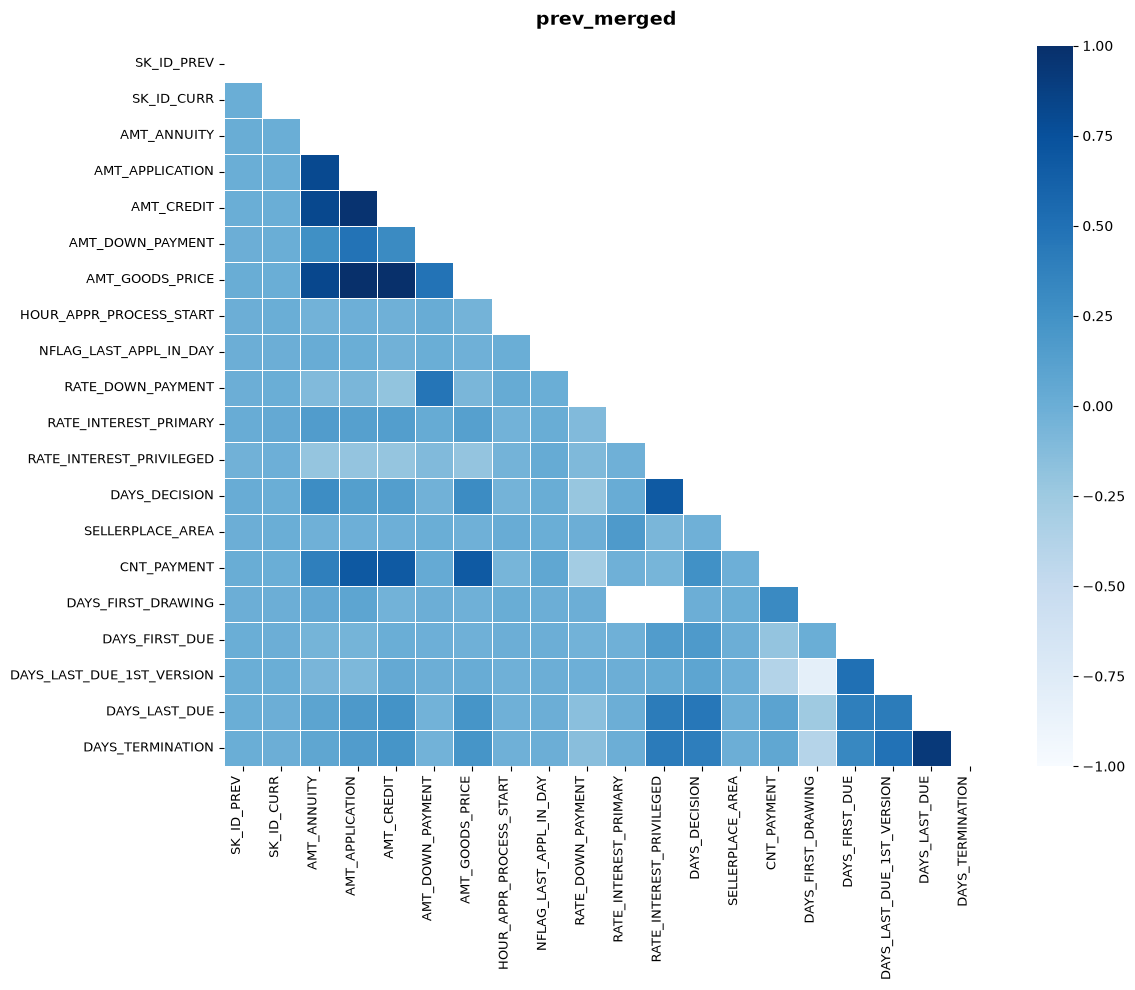

CNT_PAYMENT                  0.054892
DAYS_DECISION                0.051280
DAYS_FIRST_DRAWING           0.048823
RATE_DOWN_PAYMENT            0.038964
HOUR_APPR_PROCESS_START      0.038453
DAYS_LAST_DUE_1ST_VERSION    0.026719
DAYS_LAST_DUE                0.026295
DAYS_TERMINATION             0.025827
AMT_ANNUITY                  0.014766
DAYS_FIRST_DUE               0.012353
Name: TARGET, dtype: float64

In [59]:
corr_prev_merged_mat = corr_prev_merged.pearson_corr(cols_corr)
corr_prev_merged.plot_heatmap(corr_matrix=corr_prev_merged_mat, title='prev_merged')
corr_prev_merged.top_target_phi_k(columns=cols_corr)

Some high correlation is particularly observed for features:
- `DAYS_TERMINATION` and `DAYS_LAST_DUE`
- `AMT_CREDIT` and `AMT_APPLICATION`
- `AMT_APPLICATION` and `AMT_GOODS_PRICE`
- `AMT_ANNUITY` and `AMT_CREDIT`
- `AMT_CREDIT` and `AMT_GOODS_PRICE`

##### NAME_CONTRACT_TYPE

----------------------------------------------------------------------------------------------------
  NAME_CONTRACT_TYPE  Total_count  Default_count   Rate
0         Cash loans       501143          45593   9.10
1     Consumer loans       500805          38996   7.79
2                 NA        13174            791   6.00
3    Revolving loans       129143          13534  10.48
4                XNA          247             46  18.62
----------------------------------------------------------------------------------------------------


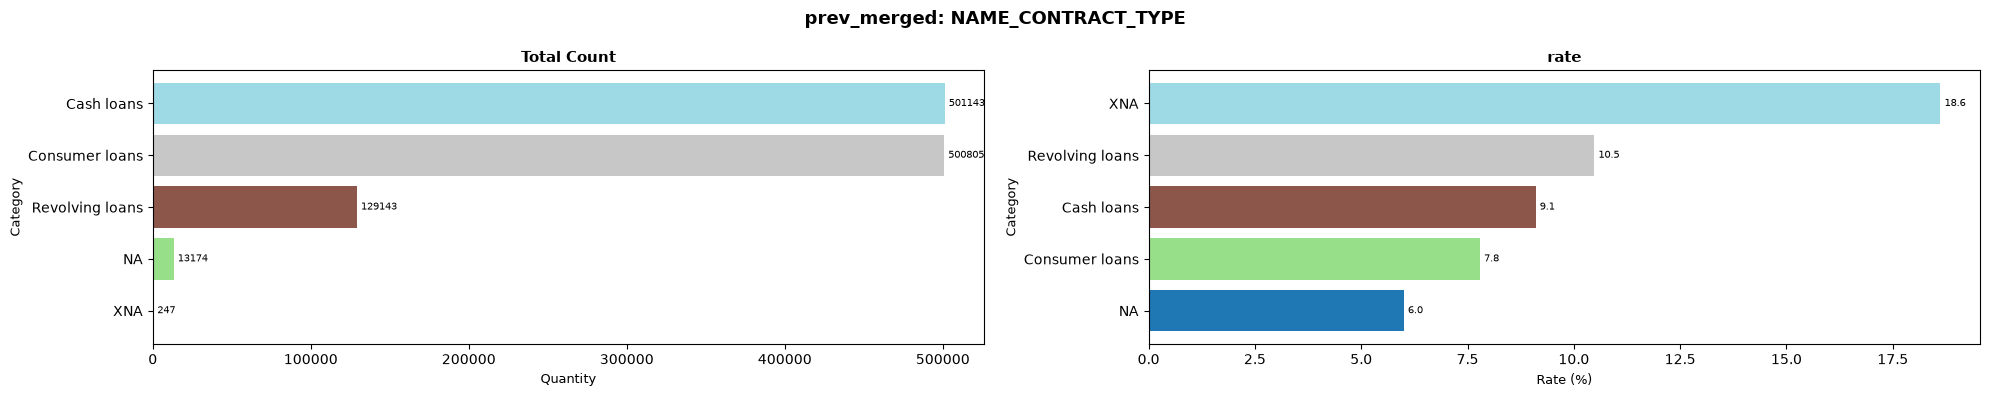

In [60]:
categorical_data_analyzer(df=prev_merged, dataset='prev_merged', column='NAME_CONTRACT_TYPE')

- Most of the previous loans have been either Cash Loans or Consumer Loans, which correspond to roughly 44% of loans each. The remaining 11.41% corresponds to Revolving Loans.

- Percentage of Defaulters for XNA type of loan are the highest, at 19% Default rate. The next highest Default Rate is among Revolving Loans, which is close to 10.5%.

- The Cash Loans have lesser default rates, roughly 9% while the consumer loans tend to have the lowest Percentage of Defaulters, which is close to 7.5%.

##### NAME_CONTRACT_STATUS

----------------------------------------------------------------------------------------------------
  NAME_CONTRACT_STATUS  Total_count  Default_count   Rate
0             Approved       709043          54134   7.63
1             Canceled       207402          18882   9.10
2                   NA        13174            791   6.00
3              Refused       196733          23607  12.00
4         Unused offer        18160           1546   8.51
----------------------------------------------------------------------------------------------------


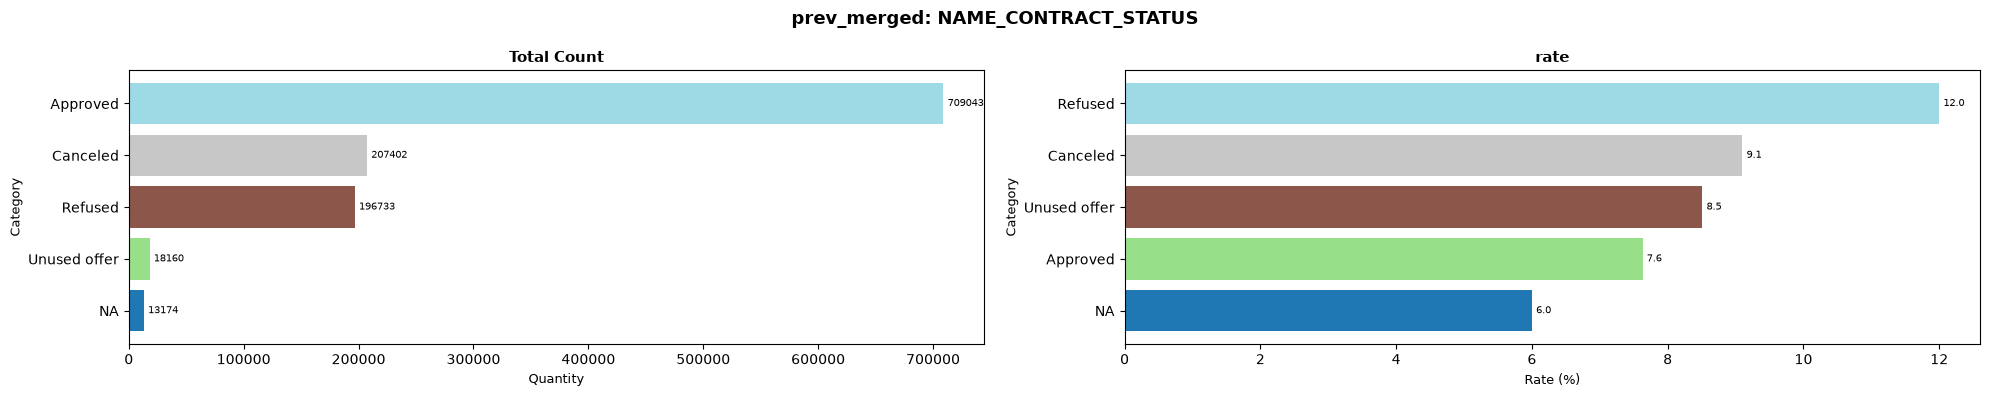

In [61]:
categorical_data_analyzer(df=prev_merged, dataset='prev_merged', column='NAME_CONTRACT_STATUS')

- ~63% of the previous credits have an Approved Status, followed by Canceled and Refused. The least occurring type of contract status idd Unused Offer which correspond to just 1.61% of all the loans

- Refused previous credits has 12% of Defaulter, followed by Canceled Status which correspond to close 9.1% of Default Rate. This behavious is quite expected logically, as these people must have been refused due to not having adequate profile

##### CODE_REJECT_REASON

----------------------------------------------------------------------------------------------------
  CODE_REJECT_REASON  Total_count  Default_count   Rate
0             CLIENT        18160           1546   8.51
1                 HC       117083          13712  11.71
2              LIMIT        38379           4854  12.65
3                 NA        13174            791   6.00
4                SCO        26176           2617  10.00
5              SCOFR         8666           1811  20.90
6             SYSTEM          526             32   6.08
7              VERIF         2439            224   9.18
8                XAP       916439          73016   7.97
9                XNA         3470            357  10.29
----------------------------------------------------------------------------------------------------


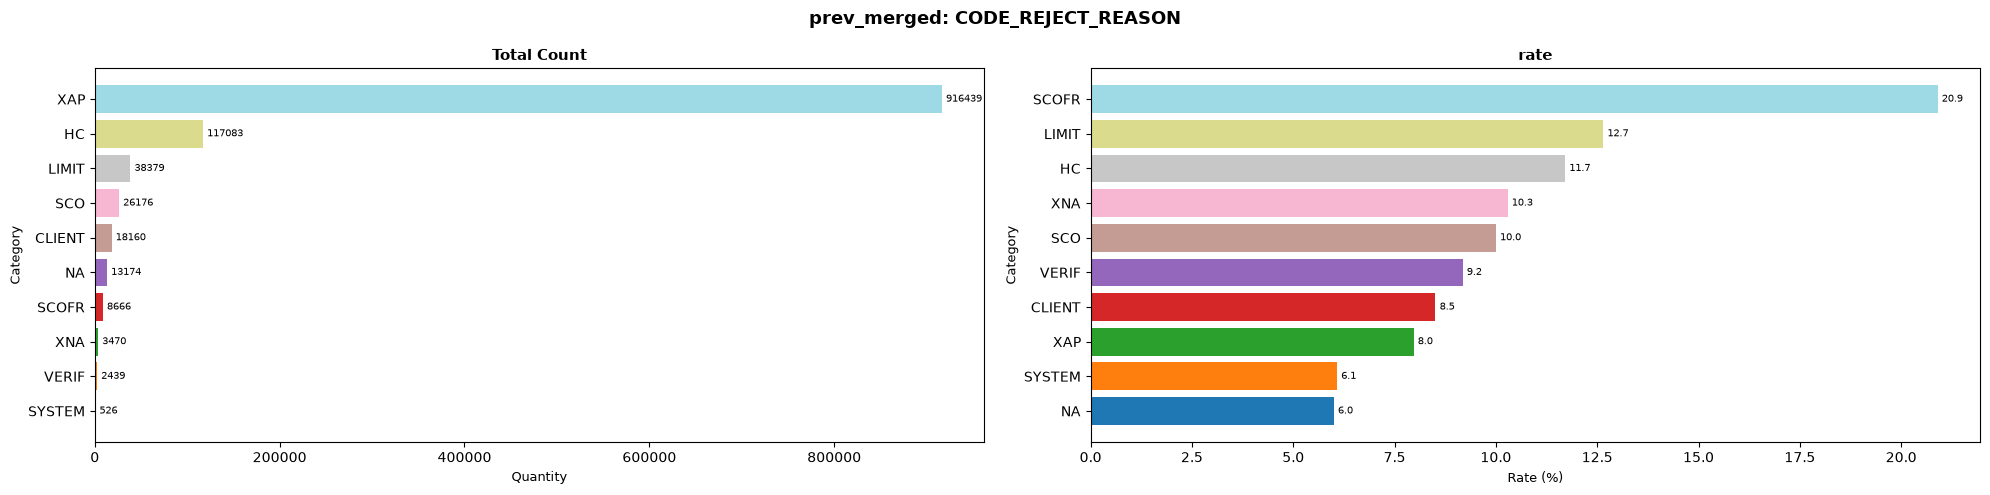

In [62]:
categorical_data_analyzer(df=prev_merged, dataset='prev_merged', column='CODE_REJECT_REASON')

- XAP (81%) and HC (10%) are 2 CODE_REJECT_REASON types that occur almost, the other reason form contribute a small part of reject reasons.

- The Code SCOFR have the highest percentage of Defaulters among them (21%). This is followed by LIMIT and HC which have around 12.65% and  11.71%.

##### CHANNEL_TYPE

----------------------------------------------------------------------------------------------------
                 CHANNEL_TYPE  Total_count  Default_count   Rate
0             AP+ (Cash loan)        39743           5128  12.90
1                  Car dealer          323             19   5.88
2  Channel of corporate sales         4287            270   6.30
3              Contact center        47228           4831  10.23
4                Country-wide       339157          28397   8.37
5     Credit and cash offices       479768          43019   8.97
6                          NA        13174            791   6.00
7            Regional / Local        74237           5669   7.64
8                       Stone       146595          10836   7.39
----------------------------------------------------------------------------------------------------


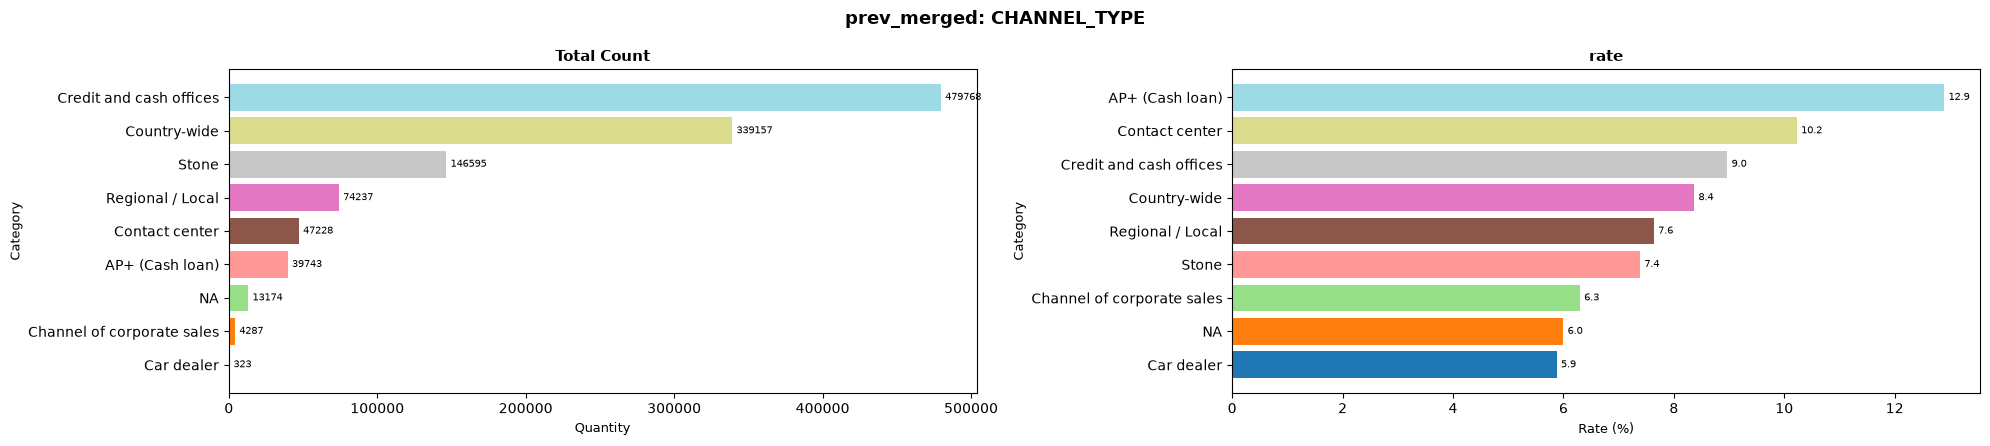

In [63]:
categorical_data_analyzer(df=prev_merged, dataset='prev_merged', column='CHANNEL_TYPE')

- Most of the applications were acquired through the Credit and cash offices, which were followed by Country-wide channel. Rest of the channel types corresponded to only a select number of applications.

- The highest Defaulting Percentage was seen among applications who had a channel type of AP+ (Cash loan) which corresponded to about 13% defaulters in that category. The rest of the channels had lower default percentages than this one. The channel Car Dealer showed a lowest Percentage of Defaulters in that category (only 5%).

##### NAME_GOODS_CATEGORY

----------------------------------------------------------------------------------------------------
         NAME_GOODS_CATEGORY  Total_count  Default_count   Rate
0         Additional Service           87              6   6.90
1                    Animals            1              0   0.00
2                Audio/Video        68626           5357   7.81
3           Auto Accessories         5001            463   9.26
4   Clothing and Accessories        15638            904   5.78
5                  Computers        72123           5865   8.13
6     Construction Materials        17032           1158   6.80
7       Consumer Electronics        84041           5920   7.04
8               Direct Sales          255             21   8.24
9                  Education           77              4   5.19
10                   Fitness          134              5   3.73
11                 Furniture        36221           2097   5.79
12                 Gardening         1845            124   6.72
13 

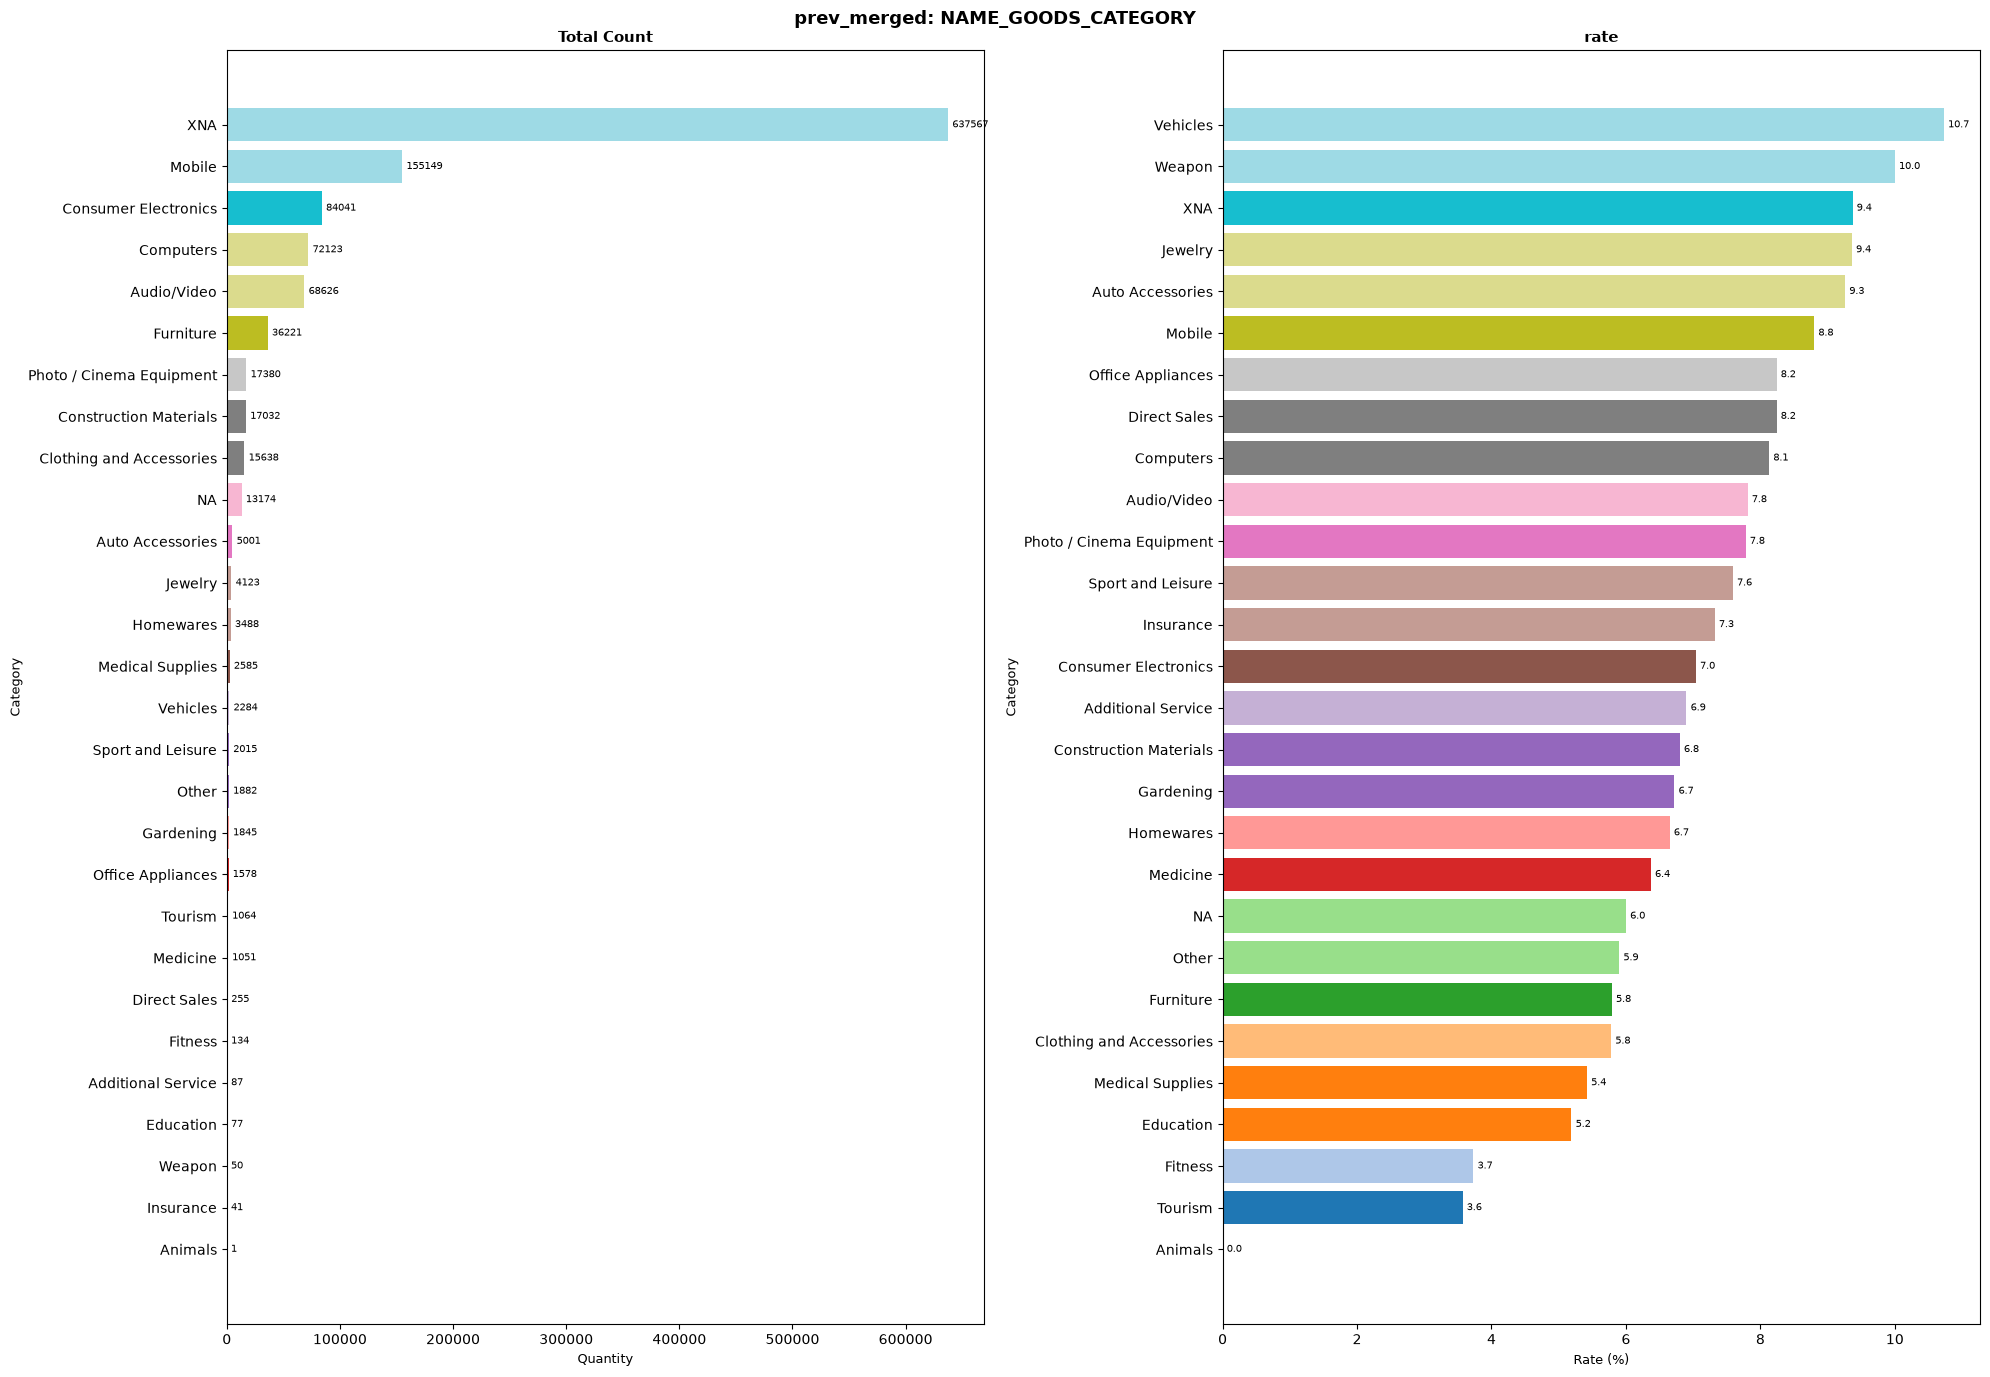

In [65]:
categorical_data_analyzer(df=prev_merged, dataset='prev_merged', column='NAME_GOODS_CATEGORY')

- XNA has the most observation and 9.37% default rate, which is higher than the common average of almost group. Clients whose application for Vehicles, Weapon, Jewelry and Auto Acccessories have high risk, but there are only 50 records for Weapon so its rate is not a good signal.

- Mobile has a medium scale and also have a significant default rate.

##### NAME_PAYMENT_TYPE

----------------------------------------------------------------------------------------------------
                           NAME_PAYMENT_TYPE  Total_count  Default_count  Rate
0                      Cash through the bank       706229          57448  8.13
1  Cashless from the account of the employer          713             59  8.27
2                                         NA        13174            791  6.00
3                 Non-cash from your account         5643            470  8.33
4                                        XNA       418753          40192  9.60
----------------------------------------------------------------------------------------------------


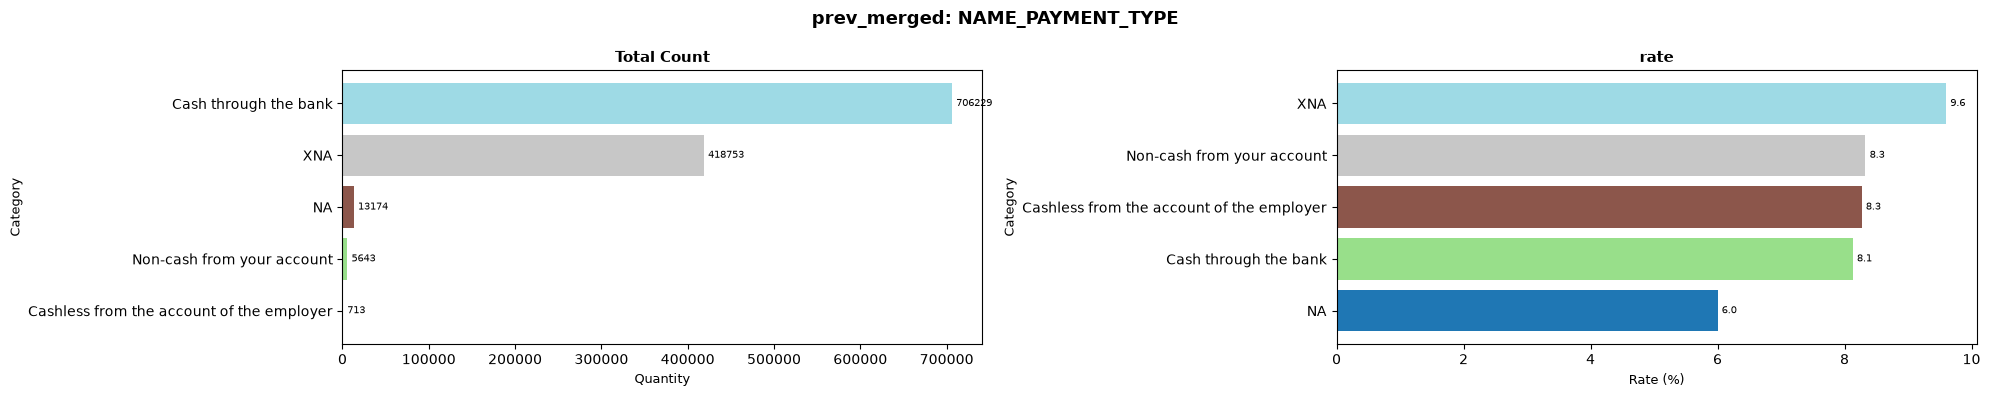

In [67]:
categorical_data_analyzer(df=prev_merged, dataset='prev_merged', column='NAME_PAYMENT_TYPE')

- XNA has the highest default rate (9.6%), noticeably above the overall level of the major categories. This may indicate that missing, unknown or non-applicable payment information is associated with a higher credit risk. The meaning of XNA shoulbe investigated before treating it as a genuine behaviorial signal.

- Non-cash from your account (8.33%), Cashless from the account of the employer (8.27%) and Cash through the bank (8.13%) show very similar default rates. This suggests that the specific payment method among these categories has limited discriminatory power for default risk.

- The differences among the substantive payment methods are small, so this variable is unlikely to be a strong standalone predictor. The treatment and interpretation of XNA/NA should be investigated carefully, as they may encode missingness or data-generation processes rather than actual payment behavior.

##### PRODUCT_COMBINATION

----------------------------------------------------------------------------------------------------
               PRODUCT_COMBINATION  Total_count  Default_count   Rate
0                      Card Street        75747           8560  11.30
1                      Card X-Sell        53396           4974   9.32
2                             Cash       188070          17803   9.47
3                Cash Street: high        41401           4636  11.20
4                 Cash Street: low        22842           2283   9.99
5              Cash Street: middle        23929           2810  11.74
6                Cash X-Sell: high        40681           4728  11.62
7                 Cash X-Sell: low        88166           5702   6.47
8              Cash X-Sell: middle        96054           7631   7.94
9                               NA        13421            837   6.24
10     POS household with interest       181667          14223   7.83
11  POS household without interest        57343           3

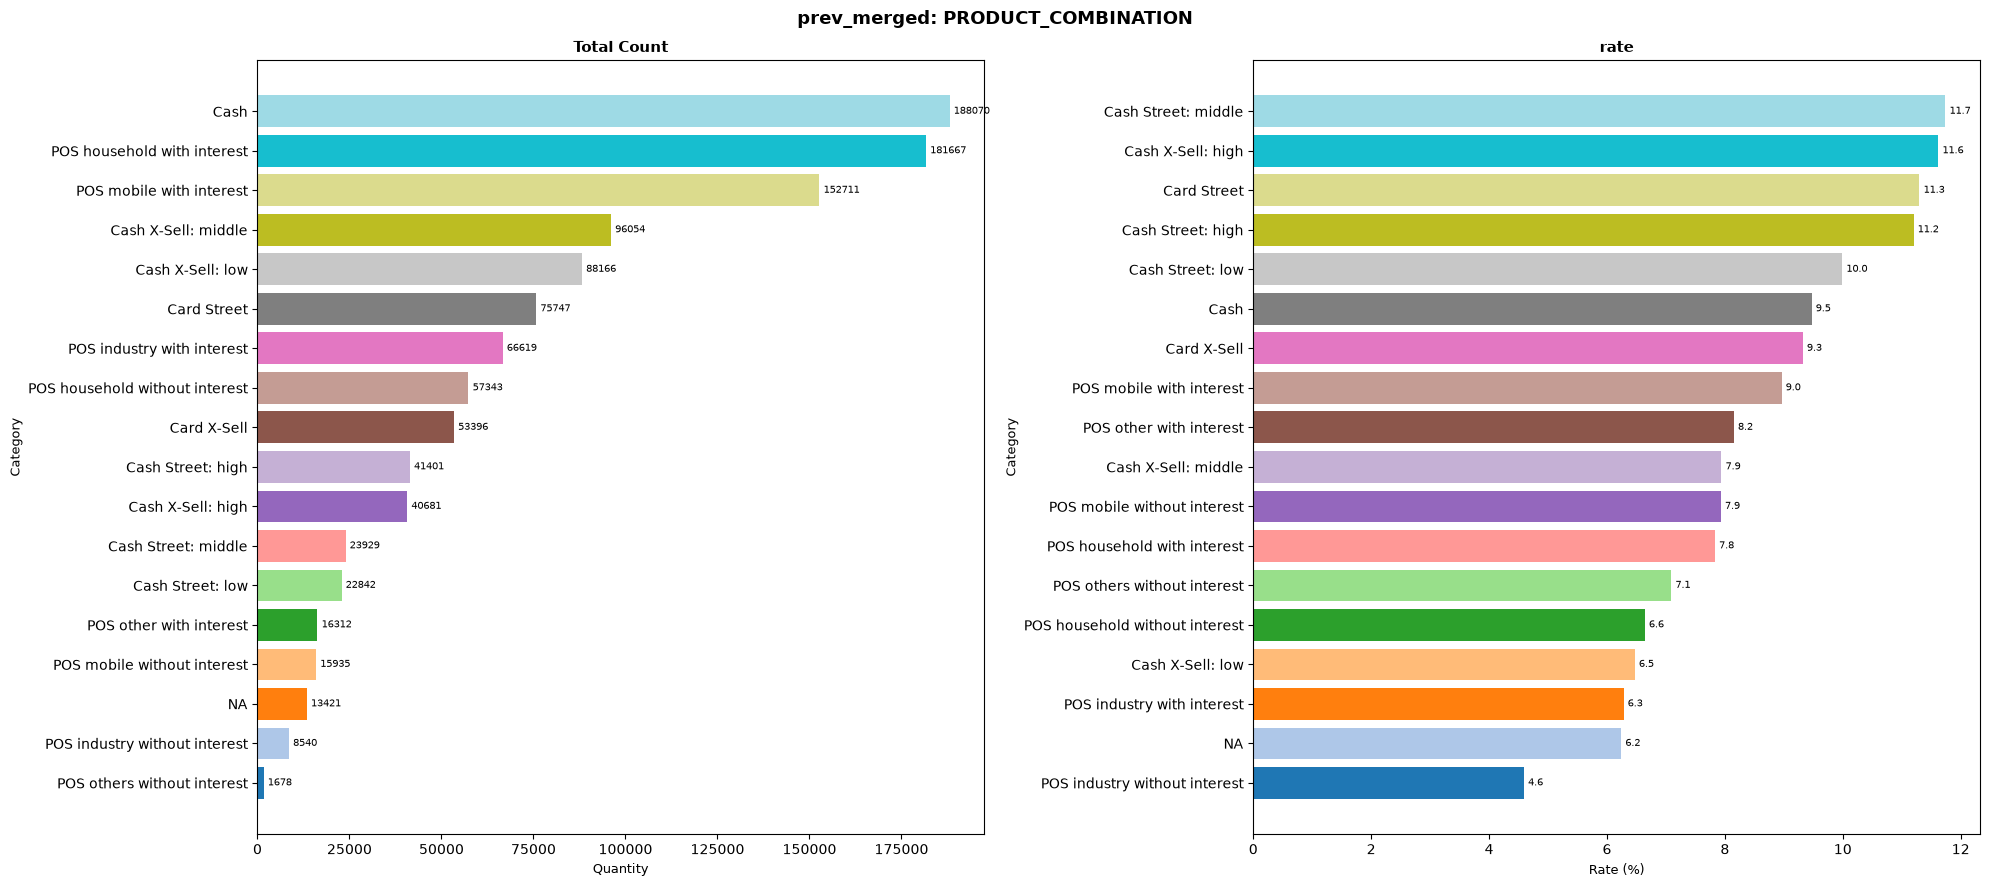

In [68]:
categorical_data_analyzer(df=prev_merged, dataset='prev_merged', column='PRODUCT_COMBINATION')

- Card Street (11.3%) and Cash Street: high (11.2%) have relatively high default rates. Cash street middle has the highest rate at 11.74%, indicating elevated risk among Street products, although the difference between Street Segment is not entirely monotonic.

- Cash X-Sell shows a strong segmentation effect. The default rate decreases from 11.62% for high, to 7.94% for middle, and 6.47% for low. This is one of the clearest patterns in the variable and suggests that the X-Sell product segment may capture meaningful differences in borrower risk.

- POS products generally have lower default rates, particularly POS industry without interest (4.59%), the lowest among the substantive product categories. POS industry with interest is also relatively low at 6.28%. This suggests that POS products, especially industry products, are associated with lower observed credit risk.

- Interest-bearing products tend to have higher default rates than their non-interest counterparts within several POS categories.

- `PRODUCT_COMBINATION` appears to have strong predictive potential, with default rates ranging from 4.59% to 11.74% among substantive categories.

##### DAYS_DECISION

----------------------------------------------------------------------------------------------------
count    1.131338e+06
mean    -8.803045e+02
std      7.835238e+02
min     -2.922000e+03
1%      -2.831000e+03
5%      -2.555000e+03
10%     -2.257000e+03
20%     -1.565000e+03
30%     -1.096000e+03
40%     -7.920000e+02
50%     -5.830000e+02
60%     -4.200000e+02
70%     -3.140000e+02
80%     -2.320000e+02
90%     -1.460000e+02
95%     -8.100000e+01
99%     -1.300000e+01
max     -1.000000e+00
Name: DAYS_DECISION, dtype: float64
----------------------------------------------------------------------------------------------------


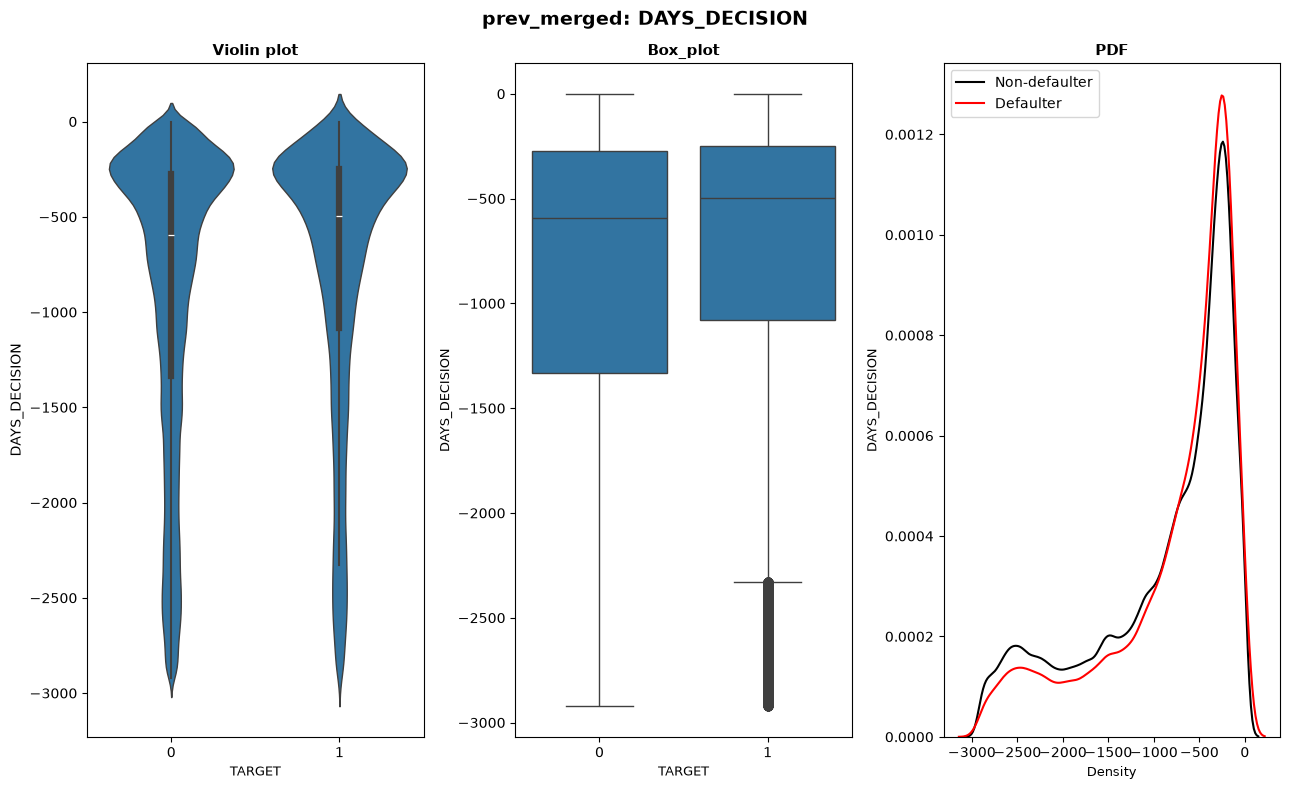

In [69]:
numerical_data_analyzer(df=prev_merged, dataset='prev_merged', column='DAYS_DECISION')

Customers with more recent previous credit decisions appear to have a somewhat higher probability of default, while customers with older decisions tend to be slightly more concentrated among non-defaulters. Nevertheless, the substantial overlap between the two distributions indicates that `DAYS_DECISION` is likely a supporting feature rather than a strong individual predictor.

##### DAYS_FIRST_DRAWING

----------------------------------------------------------------------------------------------------
count    682225.000000
mean     342233.139564
std       88876.262475
min       -2922.000000
1%        -2452.000000
5%         -262.000000
10%      365243.000000
20%      365243.000000
30%      365243.000000
40%      365243.000000
50%      365243.000000
60%      365243.000000
70%      365243.000000
80%      365243.000000
90%      365243.000000
95%      365243.000000
99%      365243.000000
max      365243.000000
Name: DAYS_FIRST_DRAWING, dtype: float64
----------------------------------------------------------------------------------------------------


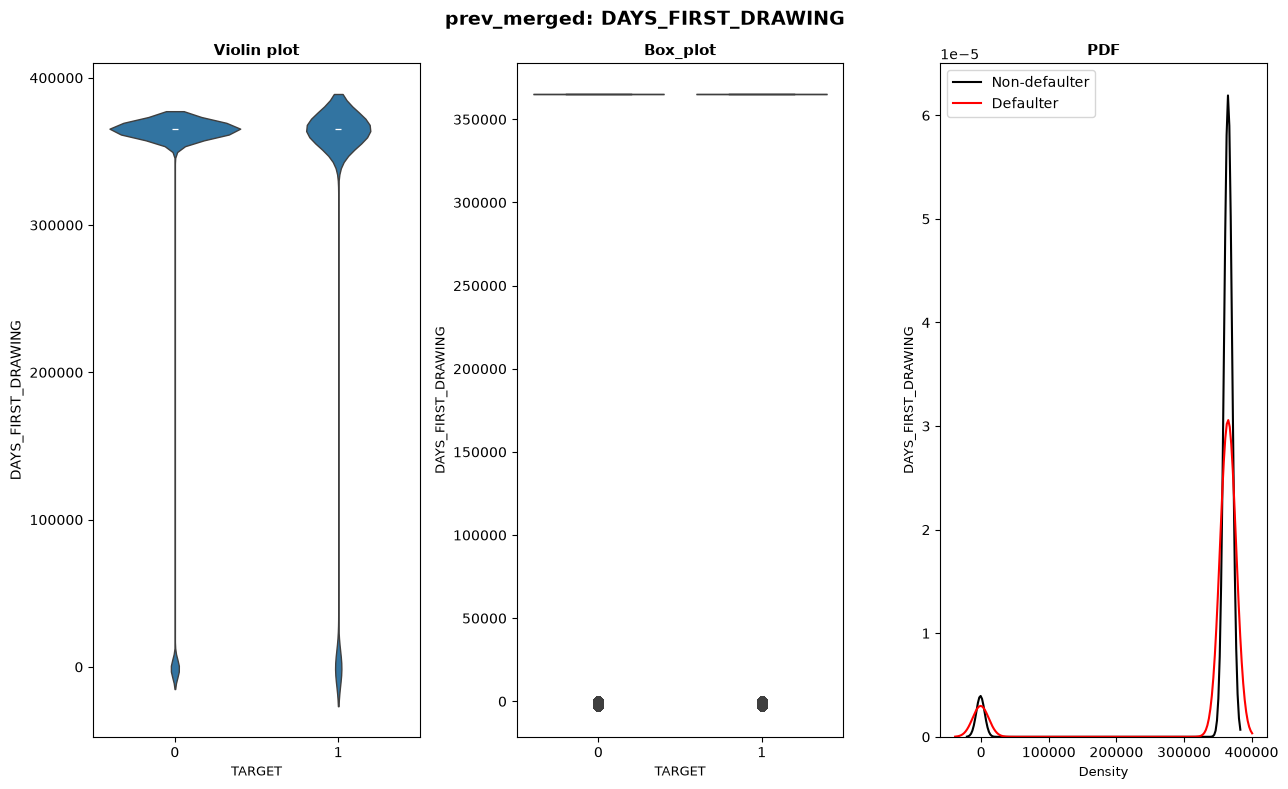

In [ ]:
numerical_data_analyzer(df=prev_merged, dataset='prev_merged', column='DAYS_FIRST_DRAWING')

- Looking at the percentile values of `DAYS_FIRST_DRAWING`, it seems like most of the values are erroneous, starting from 7th percentile values itself.

----------------------------------------------------------------------------------------------------
count    42856.000000
mean     -1051.148684
std        934.787584
min      -2922.000000
1%       -2874.000000
5%       -2773.000000
10%      -2630.000000
20%      -2321.000000
30%      -1246.000000
40%       -868.000000
50%       -629.000000
60%       -457.000000
70%       -338.000000
80%       -260.000000
90%       -202.500000
95%       -165.000000
99%        -33.000000
max         -2.000000
Name: DAYS_FIRST_DRAWING, dtype: float64
----------------------------------------------------------------------------------------------------


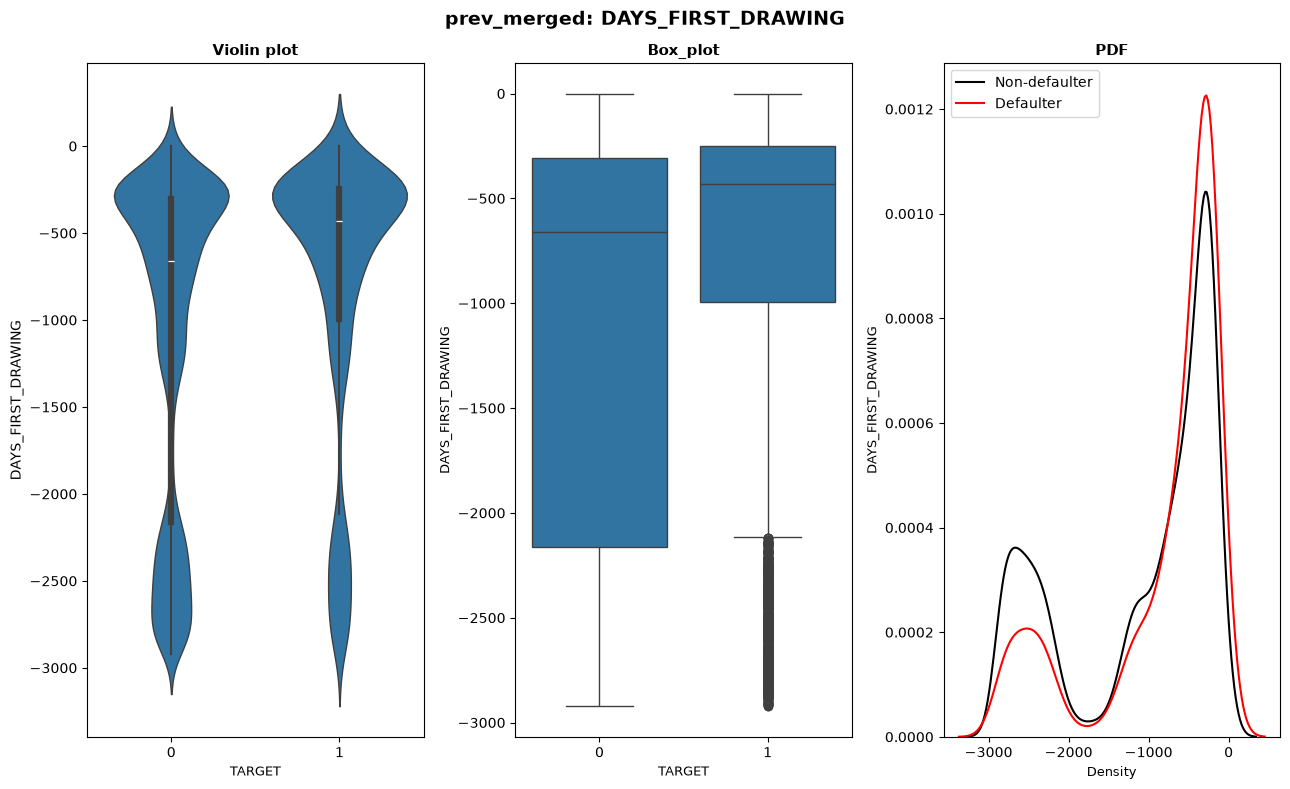

In [72]:
numerical_data_analyzer(df=prev_merged[prev_merged['DAYS_FIRST_DRAWING'] !=  365243], dataset='prev_merged', column='DAYS_FIRST_DRAWING')

- The distributions are strongly left-skewed and bimodal, with major concentrations around approximately -300 days and -2,500 to -2,700 days. This indicates that the variable captures distinct groups of customers based on how long ago their first credit drawdown occurred.

- Defaulters have a higher median value, around -440 days, compared with approximately -660 days for non-defaulters. Since values are negative, this means the first drawdown of defaulters tends to have occurred more recently.

- The PDF reinforces this pattern. Around the recent-drawdown region (roughly -300 to -500 days), the defaulter density is noticeably higher. Conversely, non-defaulters have substantially higher density around -2,500 to -2,700 days, suggesting that customers with a much older first drawdown are more concentrated among non-defaulters.

- The large overlap between the two distributions means the feature is not sufficient for individual classification, but the shift in distributions indicates meaningful predictive information.

- `DAYS_FIRST_DRAWING` suggests a relationship between customer credit-history age and default risk: customers whose first credit drawdown occurred more recently tend to exhibit higher default risk, whereas customers with a longer-established credit history tend to have lower risk. The bimodal structure also suggests that the variable may benefit from binning or nonlinear modeling, since its relationship with default risk is unlikely to be purely linear.

#### installments_payments.csv

In [74]:
installments_payments_train.head()

,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000
3,2452527,199697,1.0,3,-2418.0,-2426.0,24350.130,24350.130
4,2234264,184693,4.0,11,-349.0,-352.0,29432.295,29432.295


In [73]:
installments_payments_merged = application_train.iloc[:,:2].merge(installments_payments_train, on='SK_ID_CURR', how='left')

In [77]:
corr_installments_payments_merged = CorrelationAnalyzer(df=installments_payments_merged)
corr_mat = corr_installments_payments_merged.pearson_corr(installments_payments_train.iloc[:,2:].columns.tolist())

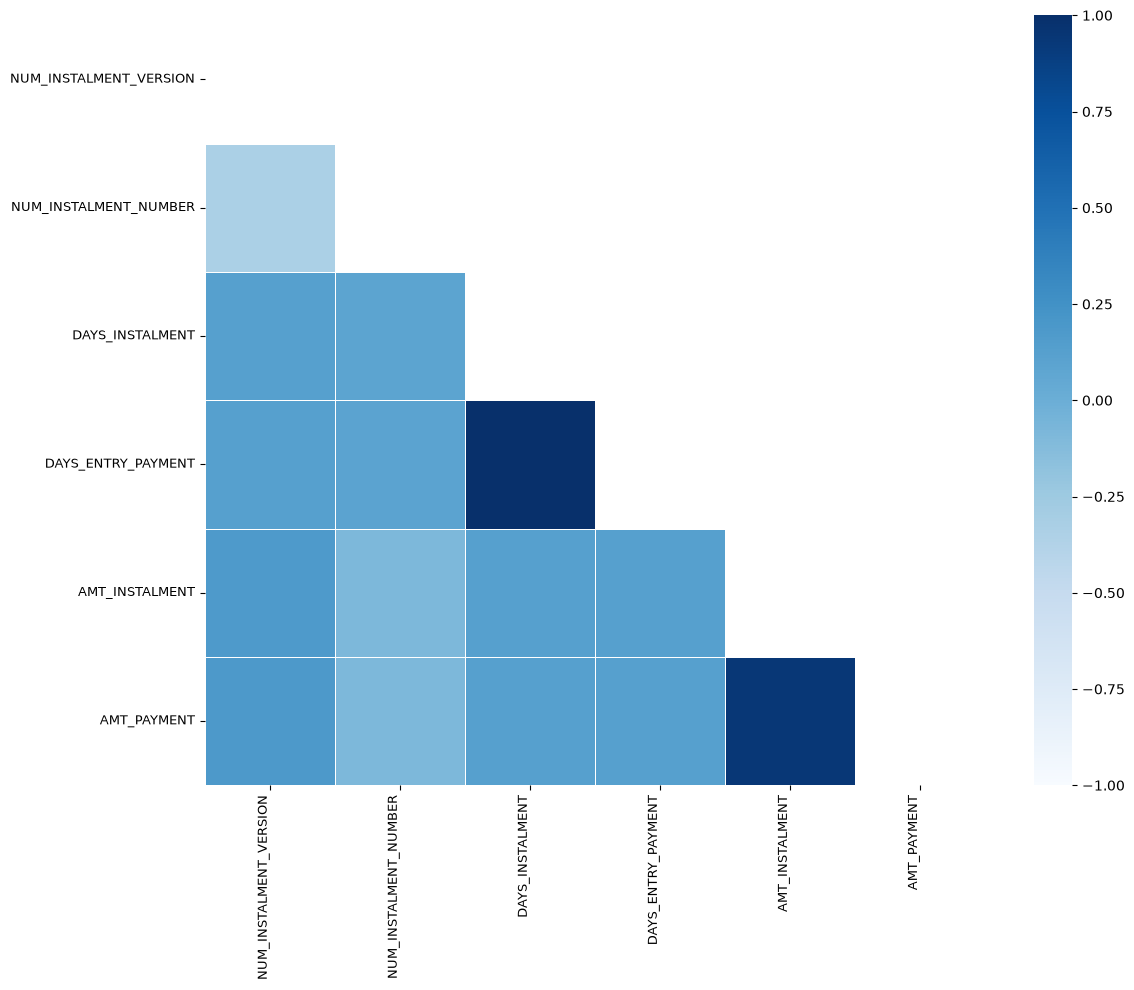

In [78]:
corr_installments_payments_merged.plot_heatmap(corr_matrix=corr_mat, title='')

In [79]:
corr_installments_payments_merged.top_target_phi_k(10,installments_payments_train.iloc[:,2:].columns.tolist())

DAYS_ENTRY_PAYMENT        0.045285
DAYS_INSTALMENT           0.045137
NUM_INSTALMENT_NUMBER     0.020710
AMT_INSTALMENT            0.004131
AMT_PAYMENT               0.003009
NUM_INSTALMENT_VERSION    0.003003
Name: TARGET, dtype: float64

- The heatmap above shows the correlation between each feature in installments_payments table with the rest of the features.
- From the heatmap of correlation matrix, we see a couple of highly correlated features. These are:
    + `AMT_INSTALMENT` and `AMT_PAYMENT`
    + `DAYS_INSTALMENT` and `DAYS_ENTRY_PAYMENT`
- These two sets of correlated features are understandable, as they are actually the features as to when the installment was due to be paid vs when it was paid and also the amount that was due vs the amount that was paid.
- These features will be useful for creating new sets of completely uncorrelated features.
The correlation of features with Target isn't noticeable, this shows the absence of a linear relationship between the feature and the target variable.

#### POS_CASH_balance.csv

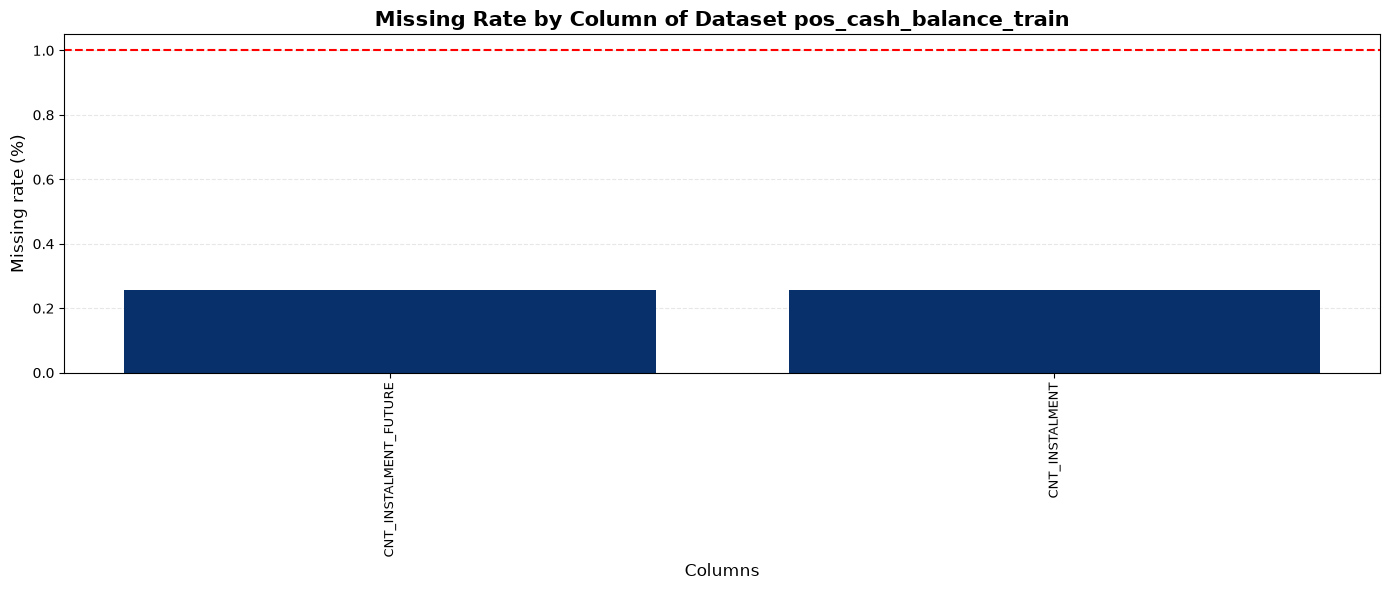

In [82]:
nan_plot_values_count(df=pos_cash_balance_train, dataset='pos_cash_balance_train', threshold=1)

These columns also contain very minimal proportion of NaN values, i.e only 0.26%, so it is also not of much concern.

In [83]:
pos_cash_merged = application_train.iloc[:,:2].merge(pos_cash_balance_train, on='SK_ID_CURR', how='left')

In [85]:
pos_cash_balance_train.columns

Index(['SK_ID_PREV', 'SK_ID_CURR', 'MONTHS_BALANCE', 'CNT_INSTALMENT',
       'CNT_INSTALMENT_FUTURE', 'NAME_CONTRACT_STATUS', 'SK_DPD',
       'SK_DPD_DEF'],
      dtype='str')

In [86]:
corr_pos_cash = CorrelationAnalyzer(df=pos_cash_balance_train)
pos_cash_corr_mat = corr_pos_cash.pearson_corr(pos_cash_balance_train.iloc[:,~pos_cash_balance_train.columns.isin(['SK_ID_CURR', 'SK_ID_PREV', 'NAME_CONTRACT_STATUS'])].columns.tolist())

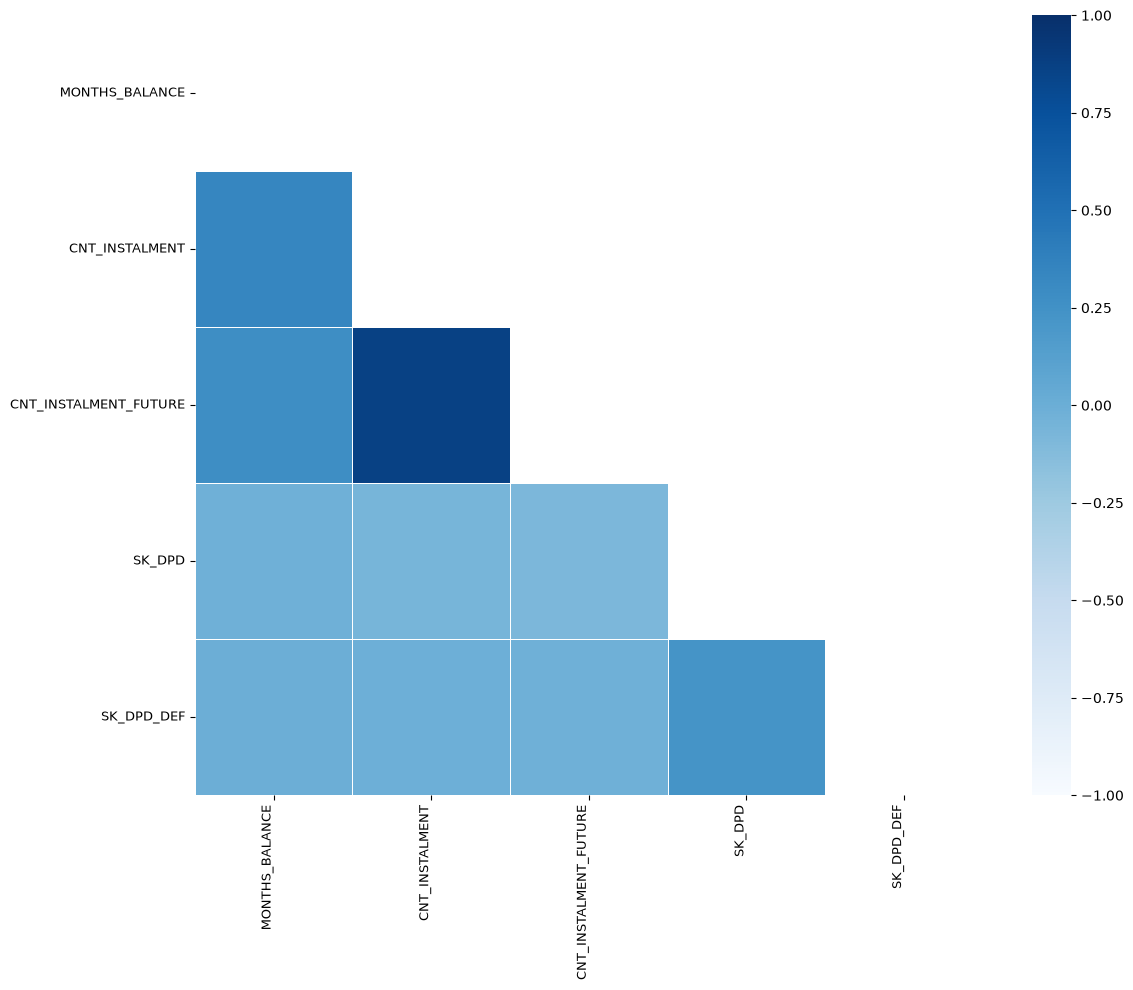

In [89]:
corr_pos_cash.plot_heatmap(corr_matrix=pos_cash_corr_mat, title='')

- The above heatmap shows the correlation between the fetures
- From the heatmap of correlation matrix, we one set of moderately correlated features, which are: CNT_INSTALMENT and CNT_INSTALMENT_FUTURE.
- The correlation of features with Target is very low, this shows the absence of a linear relationship between the feature and the target variable.

#### credit_card_balance.csv

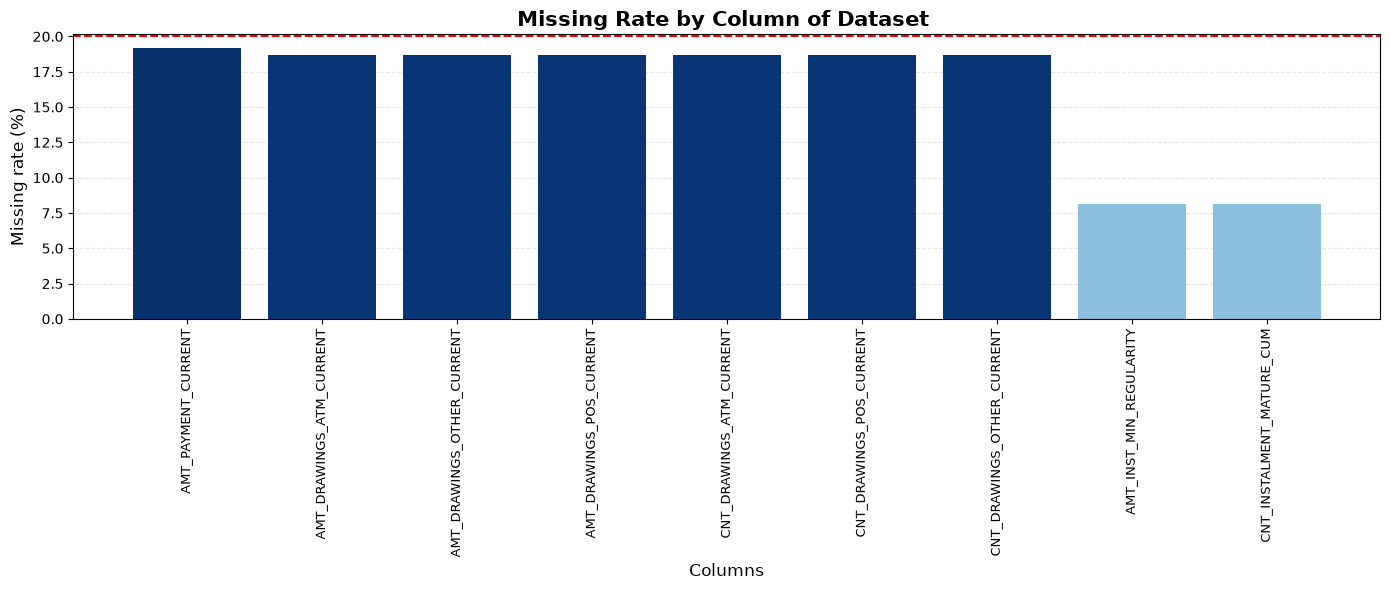

In [93]:
nan_plot_values_count(df=credit_card_balance_train, dataset='', threshold=20)

7 of these features have close to 20% NaN values. These features are mostly related to the Amounts of Drawing and Counts of Drawings. Other two of the features are related to the installments statistics.

In [94]:
credit_card_balance_train.columns

Index(['SK_ID_PREV', 'SK_ID_CURR', 'MONTHS_BALANCE', 'AMT_BALANCE',
       'AMT_CREDIT_LIMIT_ACTUAL', 'AMT_DRAWINGS_ATM_CURRENT',
       'AMT_DRAWINGS_CURRENT', 'AMT_DRAWINGS_OTHER_CURRENT',
       'AMT_DRAWINGS_POS_CURRENT', 'AMT_INST_MIN_REGULARITY',
       'AMT_PAYMENT_CURRENT', 'AMT_PAYMENT_TOTAL_CURRENT',
       'AMT_RECEIVABLE_PRINCIPAL', 'AMT_RECIVABLE', 'AMT_TOTAL_RECEIVABLE',
       'CNT_DRAWINGS_ATM_CURRENT', 'CNT_DRAWINGS_CURRENT',
       'CNT_DRAWINGS_OTHER_CURRENT', 'CNT_DRAWINGS_POS_CURRENT',
       'CNT_INSTALMENT_MATURE_CUM', 'NAME_CONTRACT_STATUS', 'SK_DPD',
       'SK_DPD_DEF'],
      dtype='str')

In [95]:
cc_balance_merged = application_train.iloc[:,:2].merge(credit_card_balance_train, on='SK_ID_CURR', how='left')

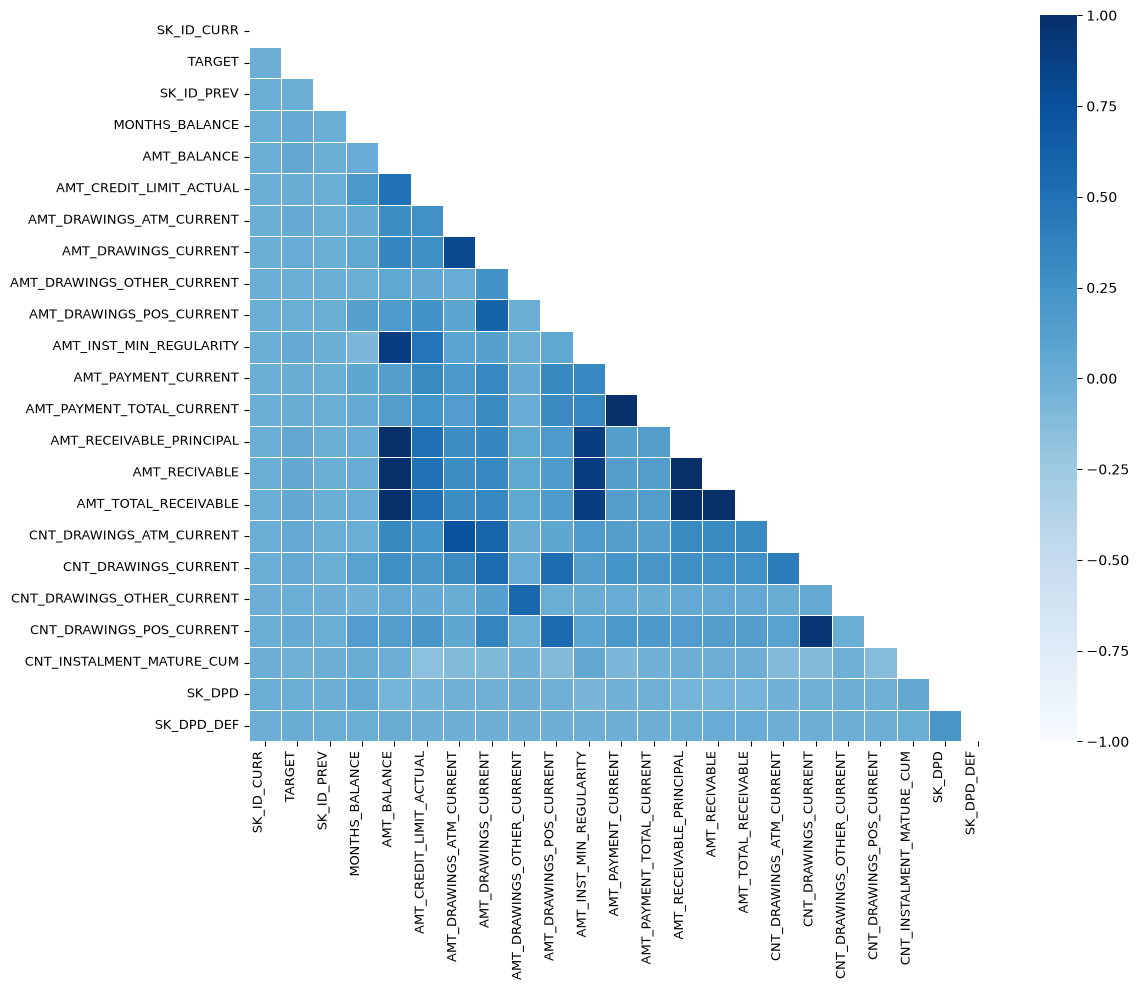

In [100]:
cc_corr = CorrelationAnalyzer(df=cc_balance_merged)
X = cc_balance_merged.drop(columns=['NAME_CONTRACT_STATUS'])
cc_mat = cc_corr.pearson_corr(X.columns.tolist())
cc_corr.plot_heatmap(corr_matrix=cc_mat, title='')

In [101]:
cc_corr.top_target_phi_k(30, columns=cc_balance_merged.columns.tolist())

AMT_BALANCE                   0.058718
AMT_RECIVABLE                 0.058176
AMT_TOTAL_RECEIVABLE          0.058148
AMT_RECEIVABLE_PRINCIPAL      0.057932
MONTHS_BALANCE                0.047047
AMT_INST_MIN_REGULARITY       0.041167
CNT_INSTALMENT_MATURE_CUM     0.034220
CNT_DRAWINGS_ATM_CURRENT      0.029181
CNT_DRAWINGS_CURRENT          0.027589
SK_ID_CURR                    0.023962
CNT_DRAWINGS_POS_CURRENT      0.023638
AMT_CREDIT_LIMIT_ACTUAL       0.023294
SK_ID_PREV                    0.020188
SK_DPD_DEF                    0.017066
AMT_DRAWINGS_CURRENT          0.012505
NAME_CONTRACT_STATUS          0.010735
AMT_DRAWINGS_ATM_CURRENT      0.010392
SK_DPD                        0.010000
AMT_PAYMENT_CURRENT           0.006817
AMT_PAYMENT_TOTAL_CURRENT     0.006503
CNT_DRAWINGS_OTHER_CURRENT    0.003263
AMT_DRAWINGS_OTHER_CURRENT    0.002440
AMT_DRAWINGS_POS_CURRENT      0.000000
Name: TARGET, dtype: float64

- The heatmap above shows visually the correlation among features in credit_card_balance table.
From the heatmap of correlation matrix, we see a few couples of highly correlated features. 
- These are:
    + `AMT_RECEIVABLE_PRINCIPLE`, `AMT_RECIVABLE`, `AMT_TOTAL_RECEIVABLE` and `AMT_BALANCE`
    + We also observe high correlation between these 3 `AMT_RECEIVABLE` columns
    + `AMT_PAYMENT_TOTAL_CURRENT` and `AMT_PAYMENT_CURRENT`
- The sets of 2nd and 3rd correlating features are understandable because they more or less the same tale.
- The correlation of features with Target isn't noticeable, this shows the absence of a linear relationship between the feature and the target variable.